In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm


plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [3]:
hela_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0091_m6Afinal/pileup.npz"
with np.load(hela_df, allow_pickle=True) as data:
    hela_df = pd.DataFrame({key: data[key] for key in data.keys()})
hela_df = hela_df[hela_df["count_all"] >= 20]
print(hela_df)

hek_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0090_m6Afinal/pileup.npz"
with np.load(hek_df, allow_pickle=True) as data:
    hek_df = pd.DataFrame({key: data[key] for key in data.keys()})
hek_df = hek_df[hek_df["count_all"] >= 20]
print(hek_df)

                label_id  pm6a       dom  count_all  count_pos  kl_div_neg  \
0         NM_000016:1000   0.0  0.000000        310          0  305.899872   
1         NM_000016:1008  -0.0  0.002034        310          0  306.057770   
2         NM_000016:1009  -0.0  0.000533        311          0  304.085480   
3         NM_000016:1010  -0.0  0.000452        313          0  302.496002   
4         NM_000016:1014  -0.0  0.002279        312          0  297.993103   
...                  ...   ...       ...        ...        ...         ...   
26478388   NR_184306:966   0.0  0.000000         20          0   17.596651   
26478389   NR_184306:967   0.0  0.000000         20          0   17.002420   
26478391   NR_184306:979  -0.0  0.056186         20          0   14.193596   
26478392    NR_184306:98  -0.0  0.069770         28          0   16.262259   
26478393   NR_184306:984  -0.0  0.004761         20          0   18.641640   

          kl_div_pos  logsum_1_p_pos  
0           0.000000    

In [4]:
from Bio import SeqIO
ref_path = "/extdata4/baeklab/Hyeonseo/m6A/res/ref/isoform/hg38_rna_nrnm.fasta"
fasta_dict = SeqIO.to_dict(SeqIO.parse(ref_path, "fasta"))
fasta_dict = {x.split(".")[0]: y for x, y in fasta_dict.items()}
a_count_dict = {x: y.seq.count("A") for x, y in fasta_dict.items()}

In [5]:
## Draw Discrepancy
geneid_table = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/res/ref/GRCh38_latest_genomic.convert_table.pkl")
convert_dict = dict(zip(geneid_table["transcript_id"], geneid_table["gene_id"]))

In [6]:
hek_label = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/BaeklabFinal.GP3.depth5_None.twm6astrict.tsv", sep="\t")
hek_label.to_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/BaeklabFinal.GP3.depth5_None.twm6astrict.pkl")
print(hek_label)

                     id  depth       nmid  pos   5mer  m6A_level  label  drach
0         NM_000849:243      6  NM_000849  243  TTATG        0.0     -3  False
1         NM_000849:252      6  NM_000849  252  GTATA        0.0     -3  False
2         NM_000849:254      6  NM_000849  254  ATAAA        0.0     -3  False
3         NM_000849:255      6  NM_000849  255  TAAAG        0.0     -3  False
4         NM_000849:256      7  NM_000849  256  AAAGC        0.0     -3  False
...                 ...    ...        ...  ...    ...        ...    ...    ...
30960573  NR_184163:989     10  NR_184163  989  TTAAG        0.0     -3  False
30960574  NR_184163:990     10  NR_184163  990  TAAGA        0.0     -3  False
30960575  NR_184163:992      8  NR_184163  992  AGAGA        0.0     -3  False
30960576  NR_184163:994      8  NR_184163  994  AGAAC        0.0     -3  False
30960577  NR_184163:995      8  NR_184163  995  GAACT        0.0     -3   True

[30960578 rows x 8 columns]


In [8]:
hela_label = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/label/BaeklabFinal.GP3.depth5_None.twm6astrict.tsv", sep="\t")
hela_label.to_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/label/BaeklabFinal.GP3.depth5_None.twm6astrict.pkl")
print(hela_label)

                      id  depth       nmid   pos   5mer  m6A_level  label  \
0            NM_000046:5     40  NM_000046     5  CTATC        0.0     -3   
1            NM_000046:8     41  NM_000046     8  TCAGC        0.0     -3   
2           NM_000046:14     41  NM_000046    14  GTACA        0.0     -3   
3           NM_000046:16     41  NM_000046    16  ACAAG        0.0     -3   
4           NM_000046:17     41  NM_000046    17  CAAGG        0.0     -3   
...                  ...    ...        ...   ...    ...        ...    ...   
26538276  NR_183730:1334      6  NR_183730  1334  TTATT        0.0     -3   
26538277  NR_183730:1339      6  NR_183730  1339  TTACC        0.0     -3   
26538278  NR_183730:1342      6  NR_183730  1342  CCACA        0.0     -3   
26538279  NR_183730:1344      6  NR_183730  1344  ACAAT        0.0     -3   
26538280  NR_183730:1345      6  NR_183730  1345  CAATT        0.0     -3   

          drach  
0         False  
1         False  
2         False  
3  

In [10]:
hela_df = hela_df.merge(hela_label[["id","drach"]], left_on="label_id", right_on="id", how="inner")
hek_df = hek_df.merge(hek_label[["id","drach"]], left_on="label_id", right_on="id", how="inner")

In [11]:
hela_df["refseq"] = hela_df["label_id"].str.split(":").str[0]
hek_df["refseq"] = hek_df["label_id"].str.split(":").str[0]
hela_df["pos"] = hela_df["label_id"].str.split(":").str[1].astype(int)
hek_df["pos"] = hek_df["label_id"].str.split(":").str[1].astype(int)
hela_df["gene_symbol"] = hela_df["refseq"].map(convert_dict)
hek_df["gene_symbol"] = hek_df["refseq"].map(convert_dict)

In [13]:
hek_count_df = hek_df["refseq"].value_counts()
hela_count_df = hela_df["refseq"].value_counts()
hek_start_df = hek_df.groupby("refseq").apply(lambda x: x["pos"].min())
hela_start_df = hela_df.groupby("refseq").apply(lambda x: x["pos"].min())
hek_end_df = hek_df.groupby("refseq").apply(lambda x: x["pos"].max())
hela_end_df = hela_df.groupby("refseq").apply(lambda x: x["pos"].max())

In [14]:
## get m6a pos for each refseq
fdr_threshold = 0.55
hela_df_m6a = hela_df[hela_df["pm6a"] >= fdr_threshold].copy()
hek_df_m6a = hek_df[hek_df["pm6a"] >= fdr_threshold].copy()
hela_df_ca = hela_df[hela_df["pm6a"] < fdr_threshold].copy()
hek_df_ca = hek_df[hek_df["pm6a"] < fdr_threshold].copy()
hela_dict = hela_df_m6a.groupby("refseq").apply(lambda x: x["pos"].values)
hek_dict = hek_df_m6a.groupby("refseq").apply(lambda x: x["pos"].values)

In [15]:
print(len(a_count_dict))

87410


In [16]:
gene_list = []
for gene_id in tqdm.tqdm(a_count_dict):
    a_count = a_count_dict[gene_id]
    hek_count = hek_count_df.get(gene_id, 0)
    hela_count = hela_count_df.get(gene_id, 0)
    if hek_count >= a_count * 0.75 and hela_count >= a_count * 0.75:
        if np.abs(hela_count - hek_count) < 10:
            if np.abs(hek_start_df.get(gene_id, 0) - hela_start_df.get(gene_id, 0)) < 100:
                if np.abs(hek_end_df.get(gene_id, 0) - hela_end_df.get(gene_id, 0)) < 100:
                    gene_list.append(gene_id)

gene_list = [x for x in a_count_dict if x in hela_dict or x in hek_dict]
gene_len_dict = {x: len(fasta_dict[x]) for x in gene_list}

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 87410/87410 [00:01<00:00, 69244.30it/s]


In [19]:
hela_df_ca_groupby = hela_df_ca.groupby("refseq")
hek_df_ca_groupby = hek_df_ca.groupby("refseq")
hela_df_m6a_groupby = hela_df_m6a.groupby("refseq")
hek_df_m6a_groupby = hek_df_m6a.groupby("refseq")

In [68]:

def plot(refseq, colour="cell"):    
    
    ## colour: cell, dynamic, drach
    
    cell_colours = ["royalblue", "tomato"]
    dynamic_colours = ["#EF962C", "#7652E3"]
    drach_colours = ["#808080", "#D7432E"]
    
    
    hela_refseq_df = hela_df_m6a[hela_df_m6a["refseq"] == refseq]
    hela_pos = hela_refseq_df["pos"].values
    hela_dom = hela_refseq_df["dom"].values
    hela_drach = hela_refseq_df["drach"].values
    hek_refseq_df = hek_df_m6a[hek_df_m6a["refseq"] == refseq]
    hek_pos = hek_refseq_df["pos"].values
    hek_dom = hek_refseq_df["dom"].values
    hek_drach = hek_refseq_df["drach"].values

    hela_ca_pos = hela_df_ca_groupby.get_group(refseq)["pos"].values
    hek_ca_pos = hek_df_ca_groupby.get_group(refseq)["pos"].values
    hela_all_pos = np.concatenate([hela_pos, hela_ca_pos])
    hek_all_pos = np.concatenate([hek_pos, hek_ca_pos])

    hela_pos_bool = np.isin(hela_pos, hek_all_pos)
    hek_pos_bool = np.isin(hek_pos, hela_all_pos)
    
    hela_pos = hela_pos[hela_pos_bool]
    hek_pos = hek_pos[hek_pos_bool]
    hela_dom = hela_dom[hela_pos_bool]
    hek_dom = hek_dom[hek_pos_bool]
    hela_drach = hela_drach[hela_pos_bool]
    hek_drach = hek_drach[hek_pos_bool]
    
    print(refseq)
    
    max_pos = gene_len_dict[refseq]
    
    x_min = 0
    x_max = max_pos//100 * 100 + 100
    
    if x_max - x_min > 4000:
        x_grid = 400
    
    elif x_max - x_min > 2000:
        x_grid = 200
    
    else:
        x_grid = 100
    
    fig, ax = plt.subplots(figsize=(20,10))
    
    ax.set_xticks(range(x_min, x_max, x_grid))
    ax.set_xticklabels([str(x) for x in range(x_min, x_max, x_grid)])
    ax.set_xlim(x_min - 10, x_max + 10)
    ax.set_ylim(-1, 1)
    ax.set_yticks(list(np.arange(-1,1.1,0.25)))
    ax.set_yticklabels([f"{x:.2f}" for x in np.arange(-1,1.1,0.25)])
    ax.grid()
    
    barwidth = 0.01 * (x_max - x_min + 20)
    
    if colour == "cell":
        ax.bar(hek_pos, hek_dom, label="HEK293T", color=cell_colours[0], width=barwidth)
        ax.bar(hela_pos, -hela_dom, label="HeLa", color=cell_colours[1], width=barwidth)
    
    elif colour == "dynamic":
        _, hek_static_ind, hela_static_ind = np.intersect1d(hek_pos, hela_pos, return_indices=True)
        ax.bar(hek_pos[hek_static_ind], hek_dom[hek_static_ind],color=dynamic_colours[0], width=barwidth, label="static")
        ax.bar(hela_pos[hela_static_ind], -hela_dom[hela_static_ind],  color=dynamic_colours[0], width=barwidth)
        hek_dynamic_pos = np.delete(hek_pos, hek_static_ind)
        hela_dynamic_pos = np.delete(hela_pos, hela_static_ind)
        hek_dynamic_dom = np.delete(hek_dom, hek_static_ind)
        hela_dynamic_dom = np.delete(hela_dom, hela_static_ind)
        ax.bar(hek_dynamic_pos, hek_dynamic_dom, color=dynamic_colours[1], width=barwidth, label="dynamic")
        ax.bar(hela_dynamic_pos, -hela_dynamic_dom, color=dynamic_colours[1], width=barwidth)
    
    elif colour == "drach":
        hek_drach_pos = hek_pos[hek_drach]
        hek_non_drach_pos = hek_pos[~hek_drach]
        hela_drach_pos = hela_pos[hela_drach]
        hela_non_drach_pos = hela_pos[~hela_drach]
        hek_drach_dom = hek_dom[hek_drach]
        hek_non_drach_dom = hek_dom[~hek_drach]
        hela_drach_dom = hela_dom[hela_drach]
        hela_non_drach_dom = hela_dom[~hela_drach]
        
        ax.bar(hek_drach_pos, hek_drach_dom, color=drach_colours[0], width=barwidth, label="DRACH")
        ax.bar(hek_non_drach_pos, hek_non_drach_dom, color=drach_colours[1], width=barwidth, label="non-DRACH")
        ax.bar(hela_drach_pos, -hela_drach_dom, color=drach_colours[0], width=barwidth)
        ax.bar(hela_non_drach_pos, -hela_non_drach_dom, color=drach_colours[1], width=barwidth)
        
    else:
        raise ValueError("Invalid colour")
    
    gene_symbol = convert_dict[refseq]

    ax.set_title(f"{gene_symbol}({refseq}) m6A Profile")
    ax.set_xlabel("Position (nt)")
    ax.set_ylabel("Degree of Modification")
    ax.legend() 
    
    ## hline at y=0
    ax.axhline(0, color="black", lw=3)
    plt.savefig(f"/extdata4/baeklab/Hyeonseo/m6A/poster/{refseq}.pdf", format="pdf")

    plt.show()


NM_001161546


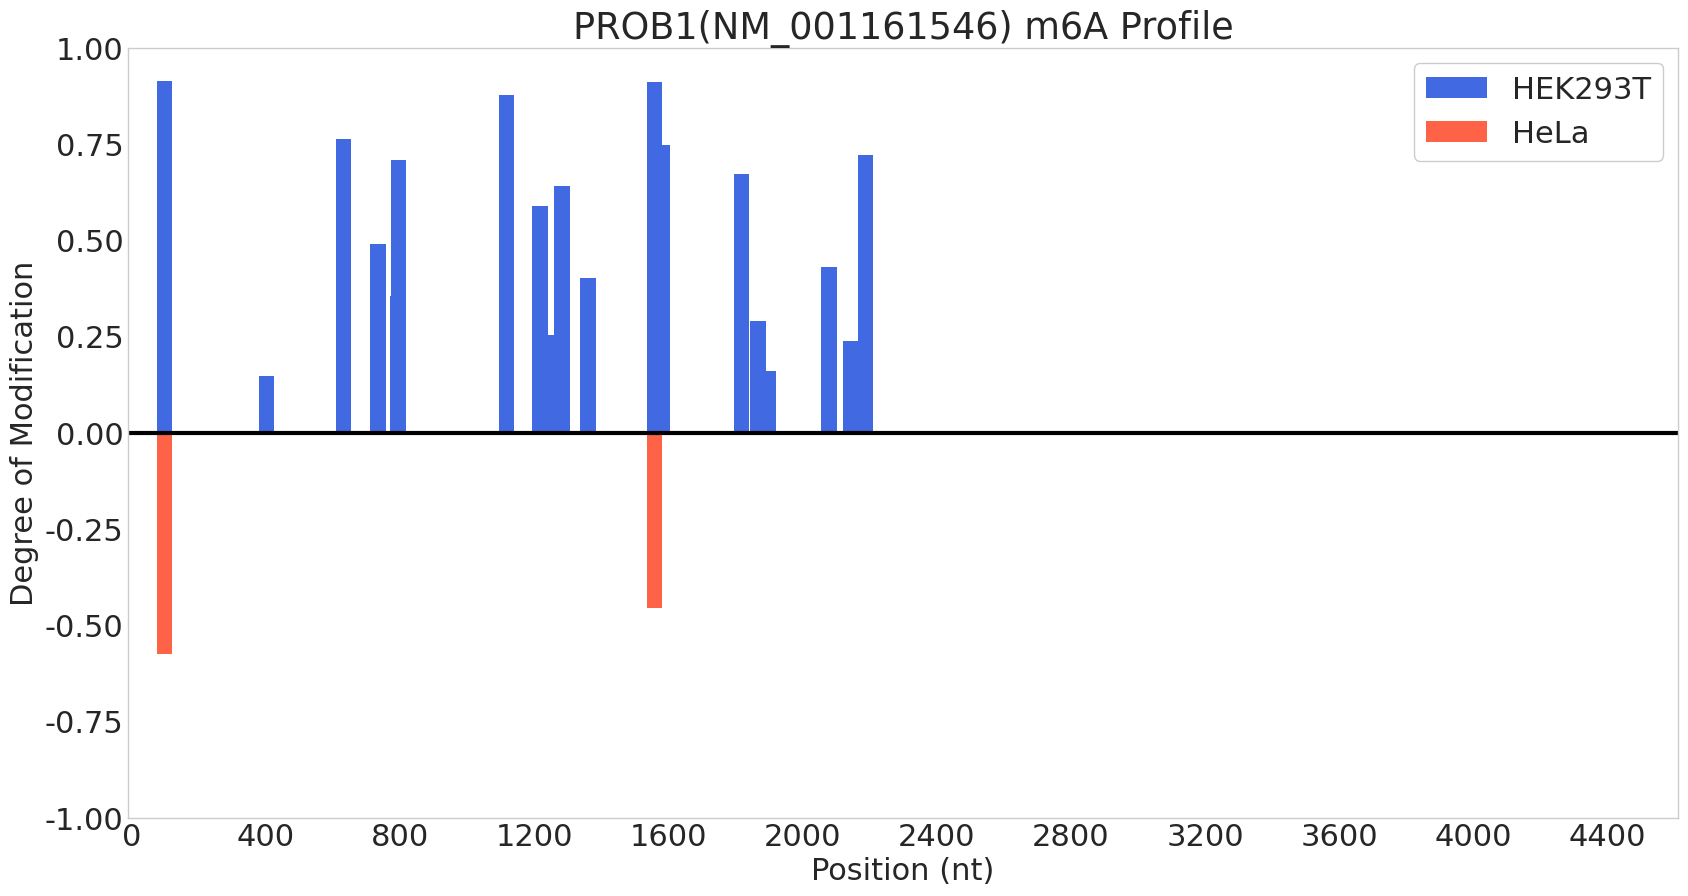

In [25]:

plot("NM_001161546", colour="cell")

NM_004289


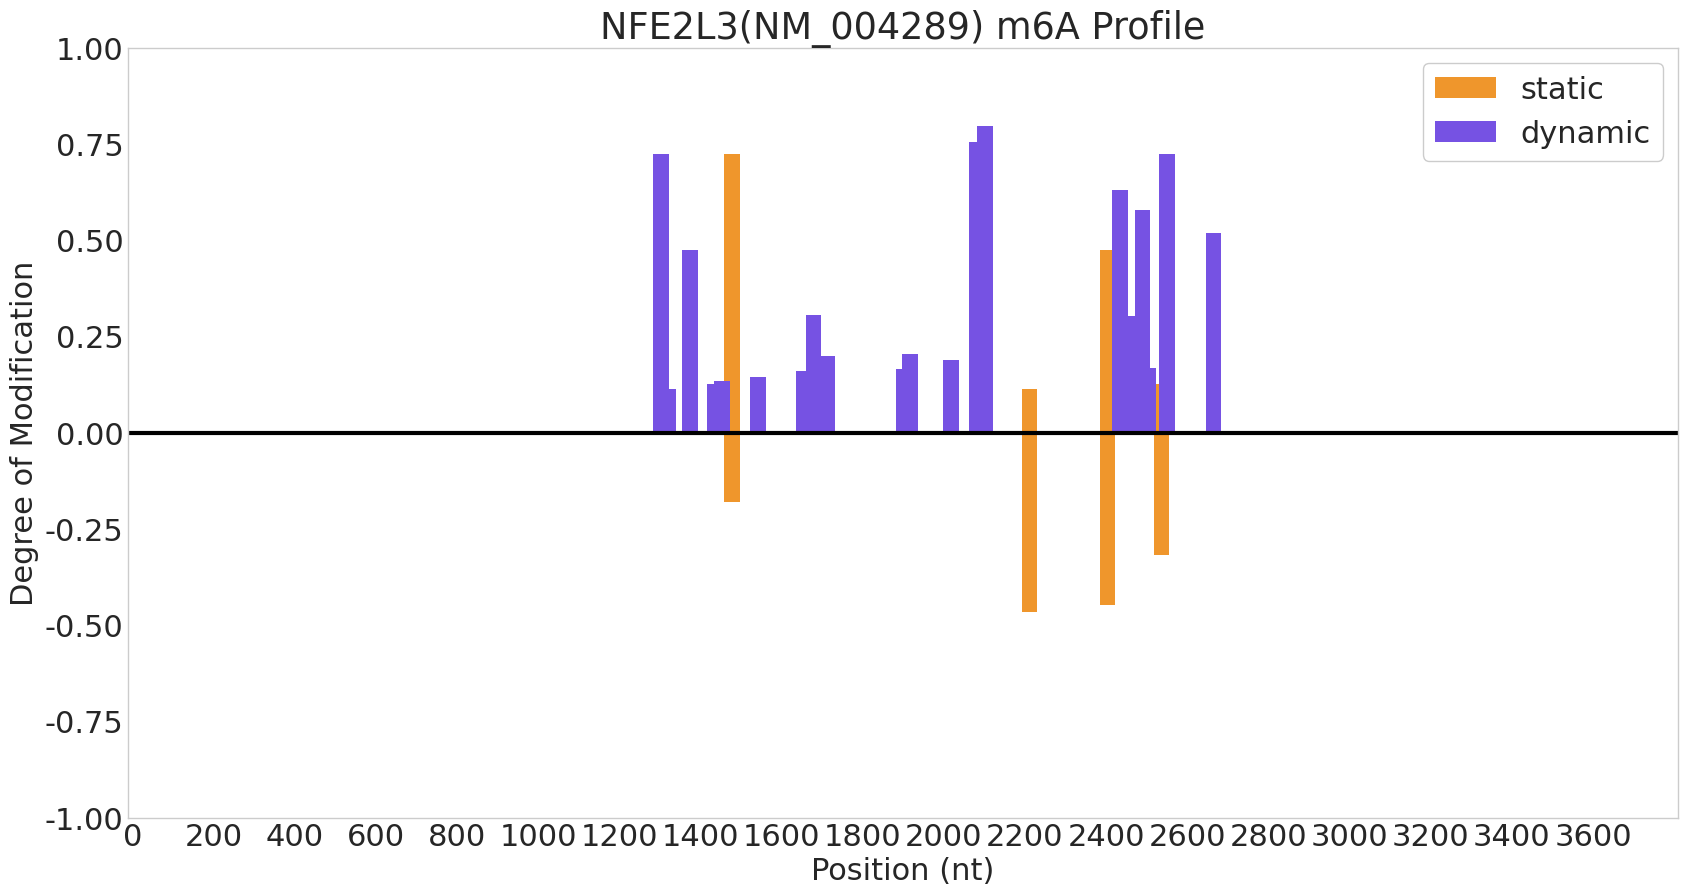

In [27]:

plot("NM_004289", colour="dynamic")

NM_001161546


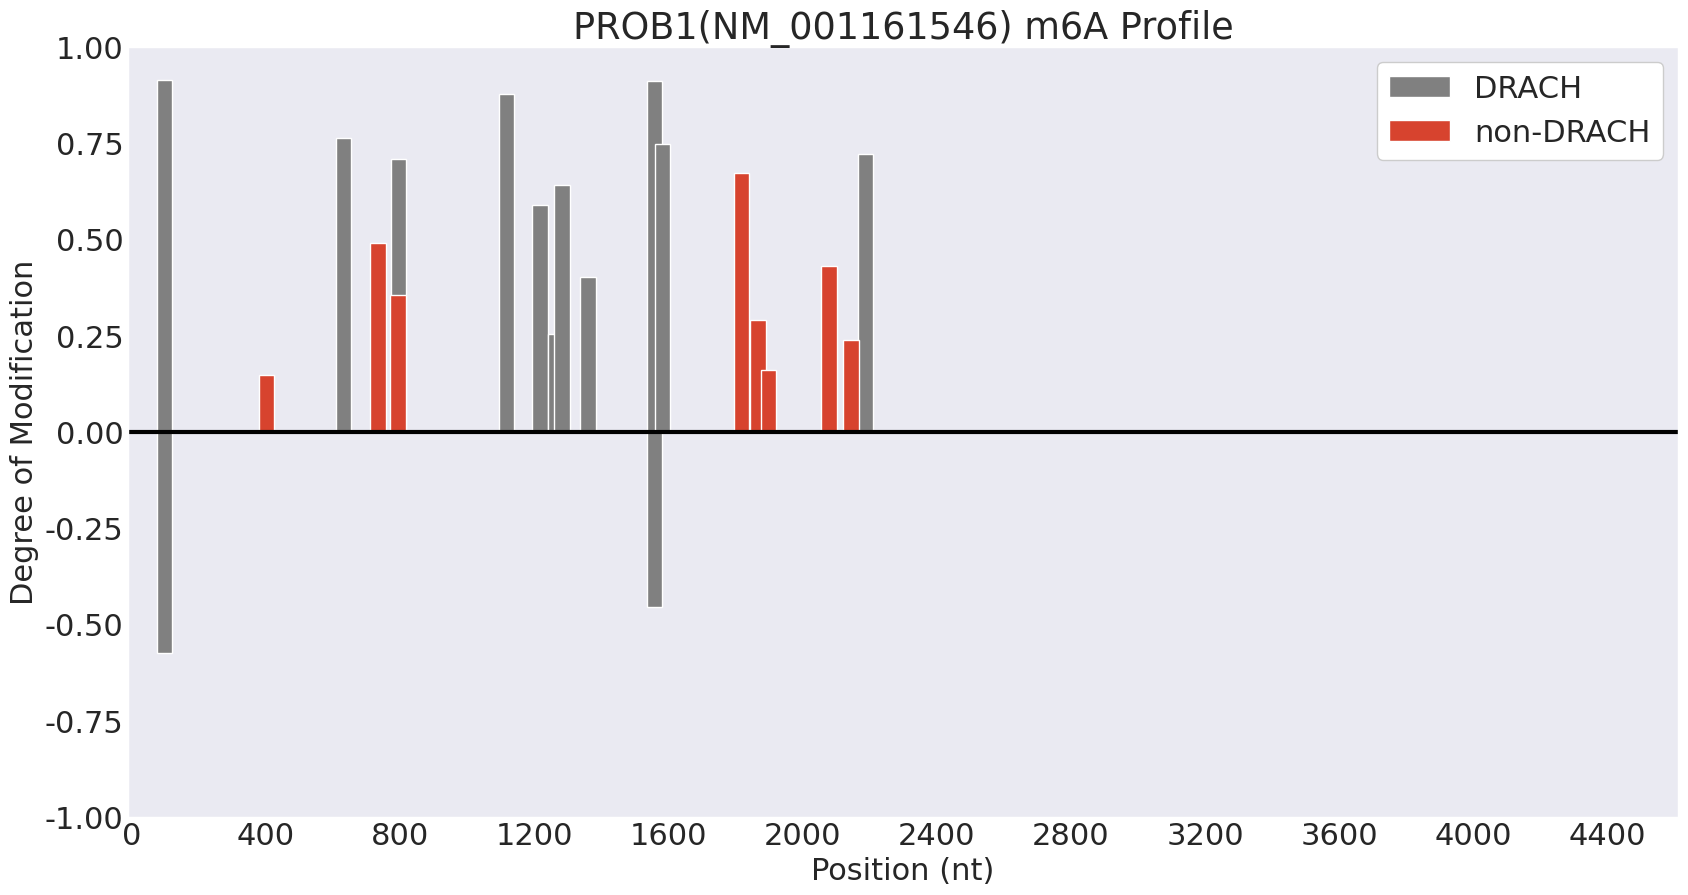

In [33]:

plot("NM_001161546", colour="drach")


NM_004289


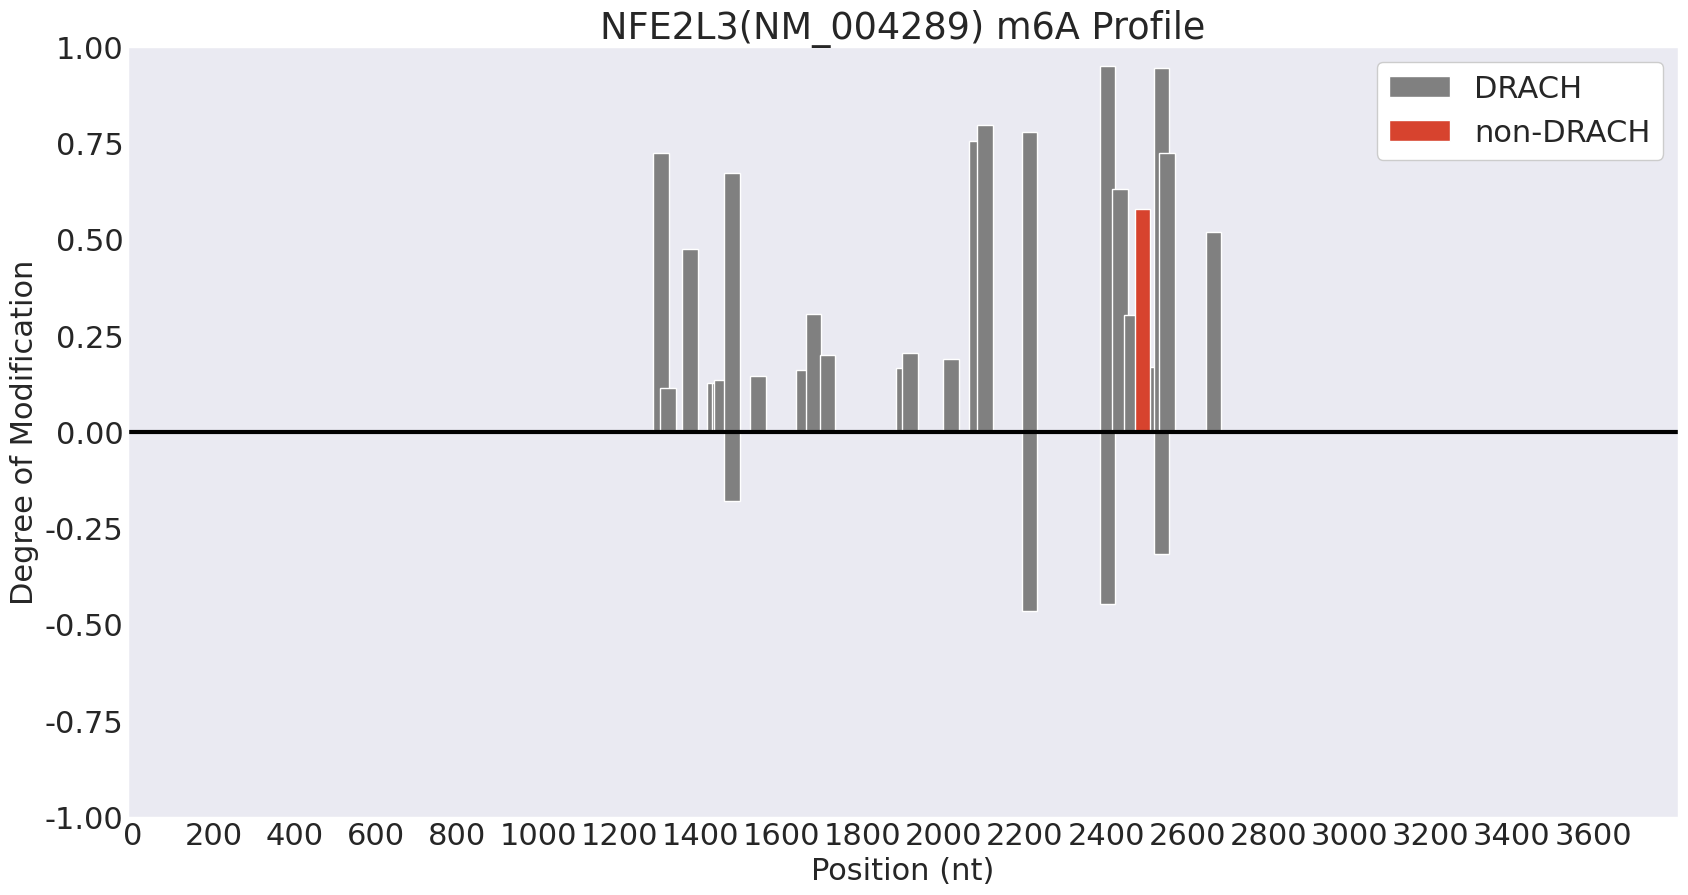

In [34]:
plot("NM_004289", colour="drach")

In [50]:

gene_dict = []
for refseq in tqdm.tqdm(gene_list):
    try:
        hela_pos = hela_dict[refseq]
        hela_dom = hela_df_m6a_groupby.get_group(refseq)["dom"].values
        hela_drach = hela_df_m6a_groupby.get_group(refseq)["drach"].values
    except KeyError:
        hela_pos = []
        hela_dom = []
        hela_drach = []
    try:
        hek_pos = hek_dict[refseq]
        hek_dom = hek_df_m6a_groupby.get_group(refseq)["dom"].values
        hek_drach = hek_df_m6a_groupby.get_group(refseq)["drach"].values
    except KeyError:
        hek_pos = []
        hek_dom = []
        hek_drach = []
        
    try:
        hela_ca_pos = hela_df_ca_groupby.get_group(refseq)["pos"].values
    except KeyError:
        hela_ca_pos = []
    try:
        hek_ca_pos = hek_df_ca_groupby.get_group(refseq)["pos"].values
    except KeyError:
        hek_ca_pos = []
    
    hela_all_pos = np.concatenate([hela_pos, hela_ca_pos])
    hek_all_pos = np.concatenate([hek_pos, hek_ca_pos])
    
    

    hela_dom_dict = dict(zip(hela_pos, hela_dom))
    hek_dom_dict = dict(zip(hek_pos, hek_dom))

    unique = 0
    
    hela_valid_pos = []
    hek_valid_pos = []
    
    hela_arr = []
    hek_arr = []
    
    for pos in np.union1d(hela_pos, hek_pos):
        if pos in hela_all_pos and pos in hek_all_pos:
            if pos in hela_pos:
                hela_valid_pos.append(pos)
            if pos in hek_pos:
                hek_valid_pos.append(pos)
            hela_dom = hela_dom_dict.get(pos, 0)
            hek_dom = hek_dom_dict.get(pos, 0)
            hela_arr.append(hela_dom)
            hek_arr.append(hek_dom)
            if hela_dom*hek_dom == 0:
                unique += 1
                    
    if len(hela_arr) > 0 or len(hek_arr) > 0:
        
        hela_arr = np.array(hela_arr)
        hek_arr = np.array(hek_arr)
        hela_valid_pos = np.array(hela_valid_pos)
        hek_valid_pos = np.array(hek_valid_pos)
    
        i = np.intersect1d(hela_valid_pos, hek_valid_pos)
        u = np.union1d(hela_valid_pos, hek_valid_pos)
        
        cosine_sim = np.dot(hela_arr, hek_arr)/(np.linalg.norm(hela_arr)*np.linalg.norm(hek_arr))
        if np.isnan(cosine_sim):
            cosine_sim = 0
        cross_entropy = -np.sum(hela_arr*np.log(hek_arr+1e-30) + (1-hela_arr)*np.log(1-hek_arr+1e-30))/len(hela_arr)
        iou = len(i)/len(u)
        
        hela_size = len(hela_valid_pos)
        hek_size = len(hek_valid_pos)
        
        l1 = np.mean(np.abs(hela_arr-hek_arr))
        l2 = np.mean((hela_arr-hek_arr)**2) ** 0.5
        
        if len(hela_drach) > 0:
            hela_nondrach_pos = hela_pos[~hela_drach]
            hela_nondrach_pos = np.intersect1d(hela_nondrach_pos, hela_valid_pos)
        else:
            hela_nondrach_pos = []
            
        if len(hek_drach) > 0:
            hek_nondrach_pos = hek_pos[~hek_drach]
            hek_nondrach_pos = np.intersect1d(hek_nondrach_pos, hek_valid_pos)
        else:
            hek_nondrach_pos = []
        
        nondrach_common_count = len(np.intersect1d(hela_nondrach_pos, hek_nondrach_pos))
        nondrach_unique_count = len(np.union1d(hela_nondrach_pos, hek_nondrach_pos)) - nondrach_common_count
        
        gene_dict.append((refseq, cosine_sim, cross_entropy, hela_size, hek_size, iou, unique, l1, l2, nondrach_common_count, nondrach_unique_count))

diff_df = pd.DataFrame(gene_dict, columns=["refseq", "cosine_sim", "cross_entropy", "hela_size", "hek_size", "iou", "unique", "l1", "l2", "nondrach_common", "nondrach_unique"])

print(diff_df)

  0%|                                                                                                                                                                     | 0/24781 [00:00<?, ?it/s]/tmp/ipykernel_64783/495217675.py:68: RuntimeWarning: invalid value encountered in scalar divide
  cosine_sim = np.dot(hela_arr, hek_arr)/(np.linalg.norm(hela_arr)*np.linalg.norm(hek_arr))
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24781/24781 [00:46<00:00, 532.05it/s]


          refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
0      NM_000016    1.000000       0.573238          1         1  1.000000   
1      NM_000017    0.949245       2.767122          5         5  0.428571   
2      NM_000021    0.983533       2.964824         22        17  0.695652   
3      NM_000027    1.000000       0.586155          1         1  1.000000   
4      NM_000028    1.000000       0.606982          1         1  1.000000   
...          ...         ...            ...        ...       ...       ...   
16796  NR_183625    0.992224       2.003993          5         4  0.800000   
16797  NR_183758    0.985988       0.573215          2         2  1.000000   
16798  NR_183824    0.976160       0.395841          7        11  0.636364   
16799  NR_184202    0.829297       0.598689          3         5  0.600000   
16800  NR_184306    0.990638       0.425246          2         3  0.666667   

       unique        l1        l2  nondrach_common  nondrach_un

In [52]:
print(diff_df[(diff_df["nondrach_unique"] > 5) & (diff_df["nondrach_common"] < 2)])

             refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
667    NM_001017969    0.969789       3.275276         46        40  0.653846   
2229   NM_001161546    0.492884       0.859172          2        19  0.105263   
3461   NM_001267783    0.935526       2.327283         36        37  0.697674   
3929   NM_001282858    0.951751       1.239728         43        45  0.833333   
5684   NM_001330682    0.744266       2.298061         12        20  0.230769   
7361   NM_001396518    0.956381       2.901334         70        63  0.773333   
7865      NM_001992    0.946407       2.582451         22        20  0.615385   
8464      NM_003440    0.938785       6.232559         26        17  0.653846   
8485      NM_003489    0.975197       1.818672         60        59  0.803030   
10732     NM_014741    0.938223       2.469548         20        20  0.538462   
11117     NM_015482    0.939919       1.852904         43        52  0.666667   
13003     NM_024639    0.947

NR_165312


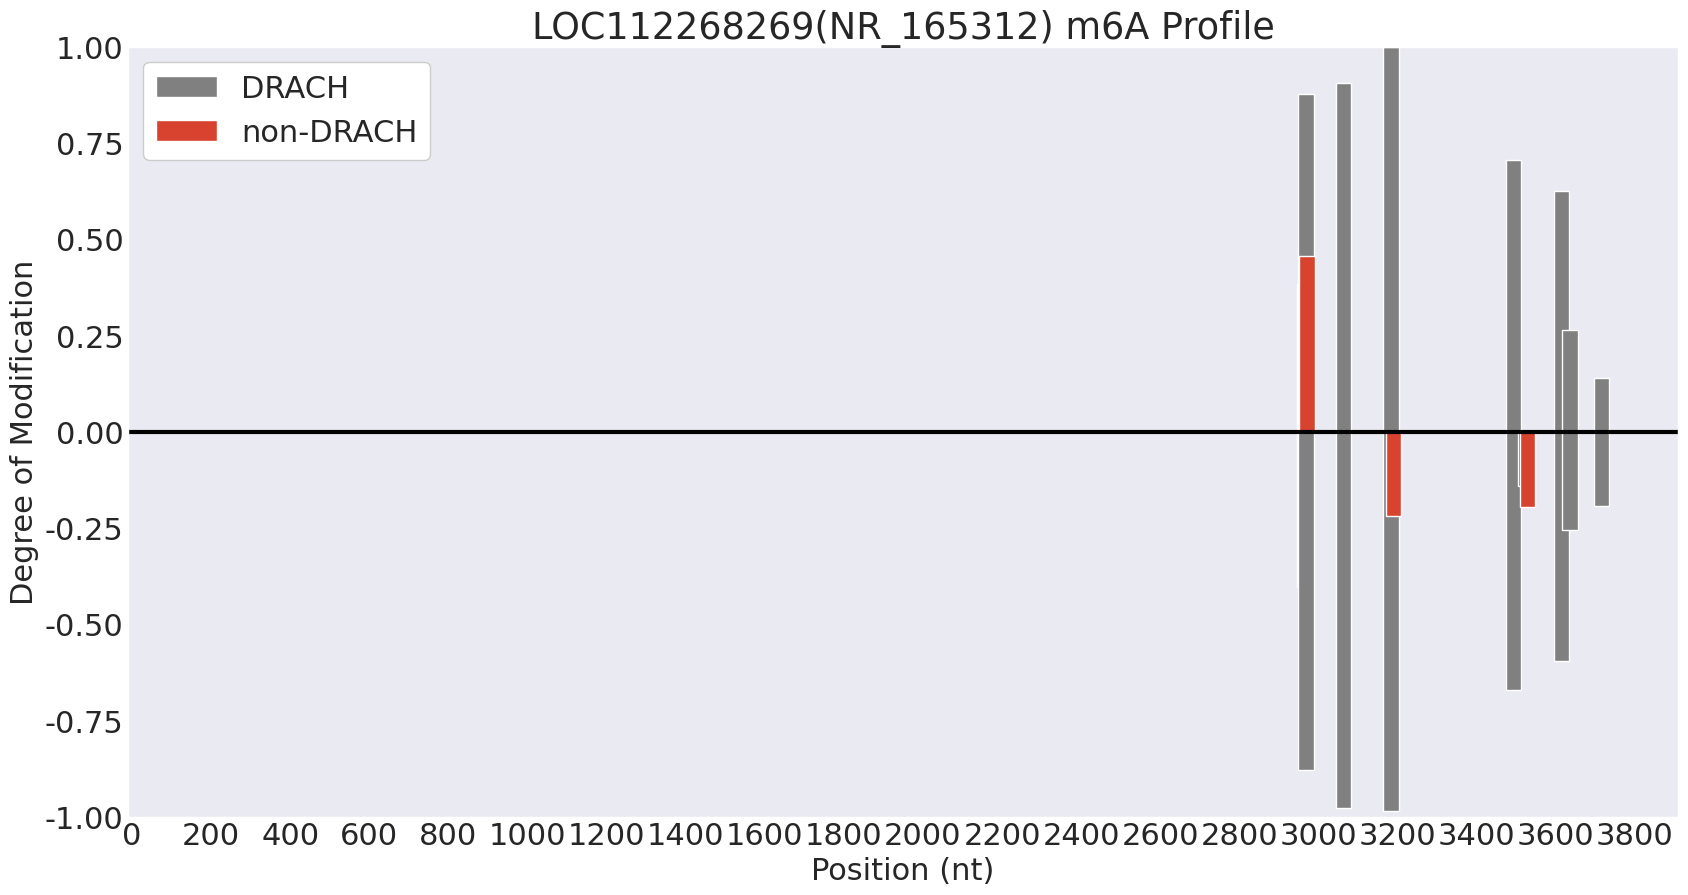

In [49]:
plot("NR_165312", colour="drach")

In [108]:
selected_nmids = diff_df[(diff_df["nondrach_unique"] == diff_df["unique"]) & (diff_df["unique"] > 1) & (diff_df["nondrach_common"] == 0) & (diff_df["cosine_sim"] < 0.95)]
print(selected_nmids)

             refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
1371   NM_001105207    0.936215       5.568483          8         6  0.750000   
1934   NM_001142546    0.816163       4.336732          6         4  0.666667   
2419   NM_001170686    0.000000       4.850292          1         1  0.000000   
2572   NM_001184720    0.449696      16.498344          3         1  0.333333   
3546   NM_001271662    0.691504       2.781395          2         2  0.333333   
3630   NM_001276293    0.934133       0.527219          7         9  0.777778   
3939   NM_001282953    0.696762       2.211539          3         3  0.500000   
3941   NM_001282955    0.796727       4.905795          3         1  0.333333   
3962   NM_001284215    0.945922       2.121750         12        12  0.846154   
4244   NM_001289174    0.521475      19.497503          2         2  0.333333   
5982   NM_001352281    0.864754       0.382953          1         3  0.333333   
6383   NM_001365126    0.907

NM_001105207


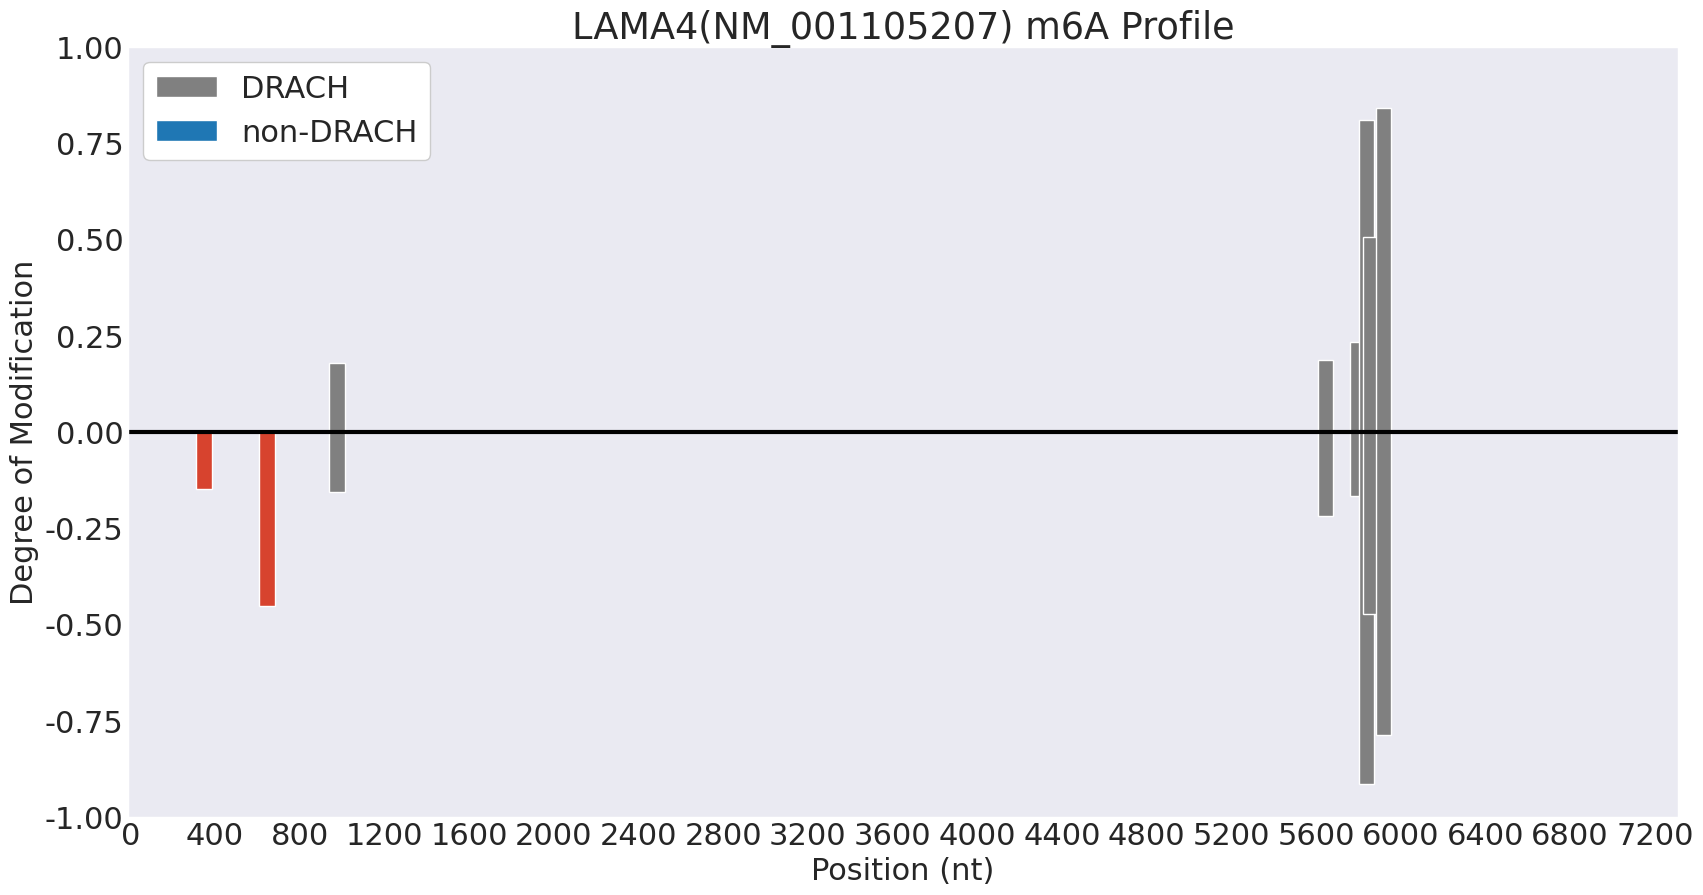

NM_001142546


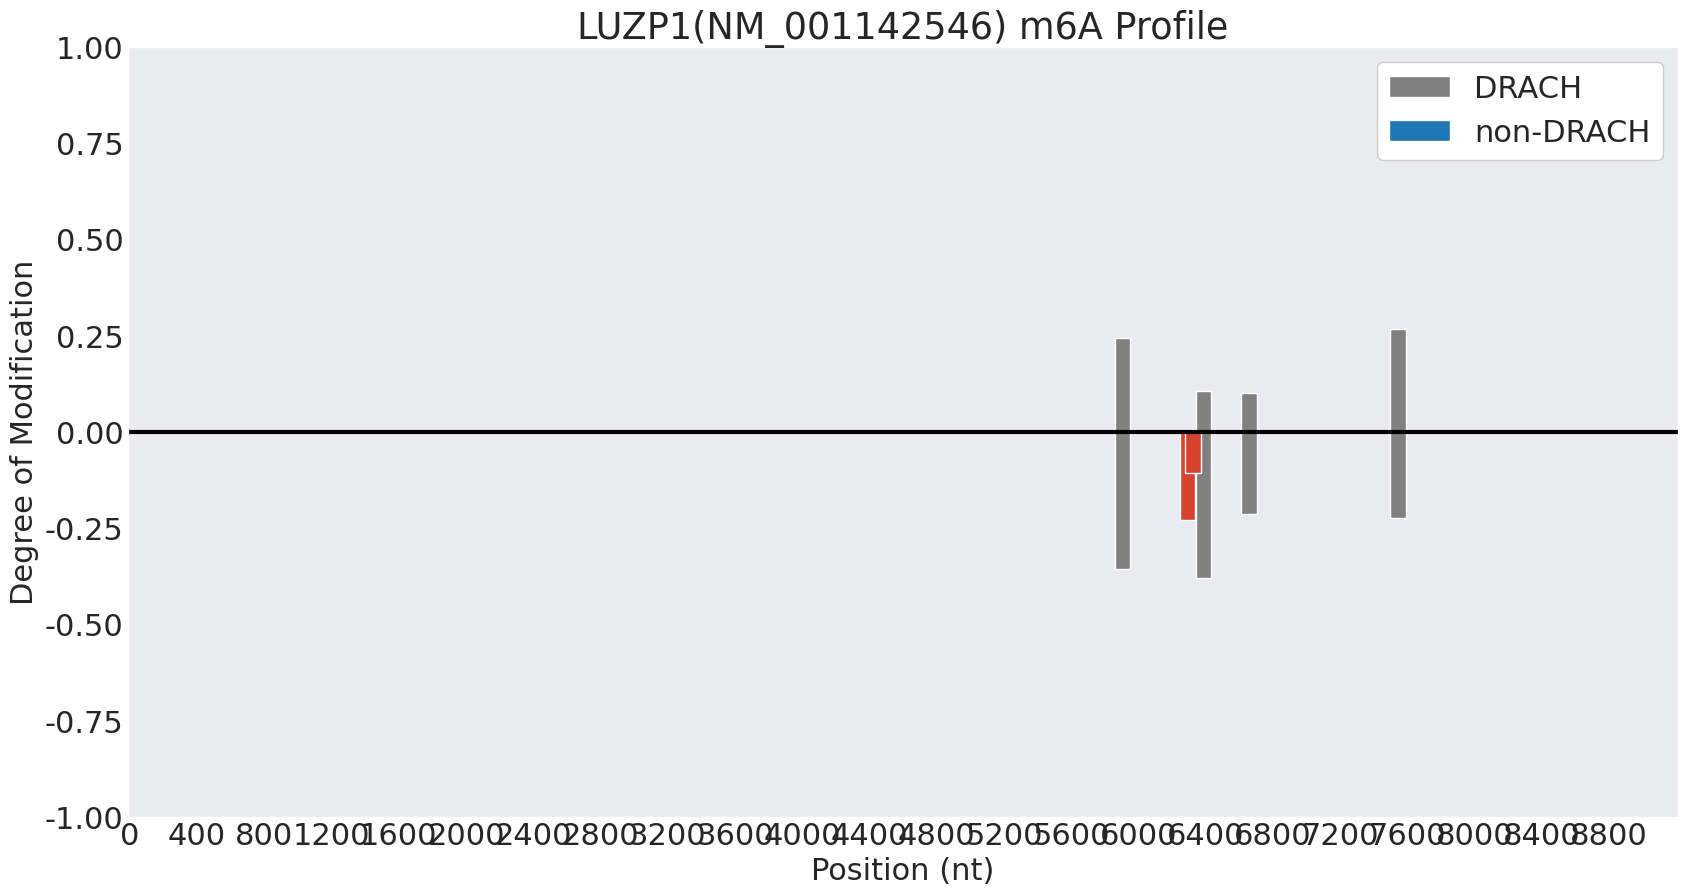

NM_001170686


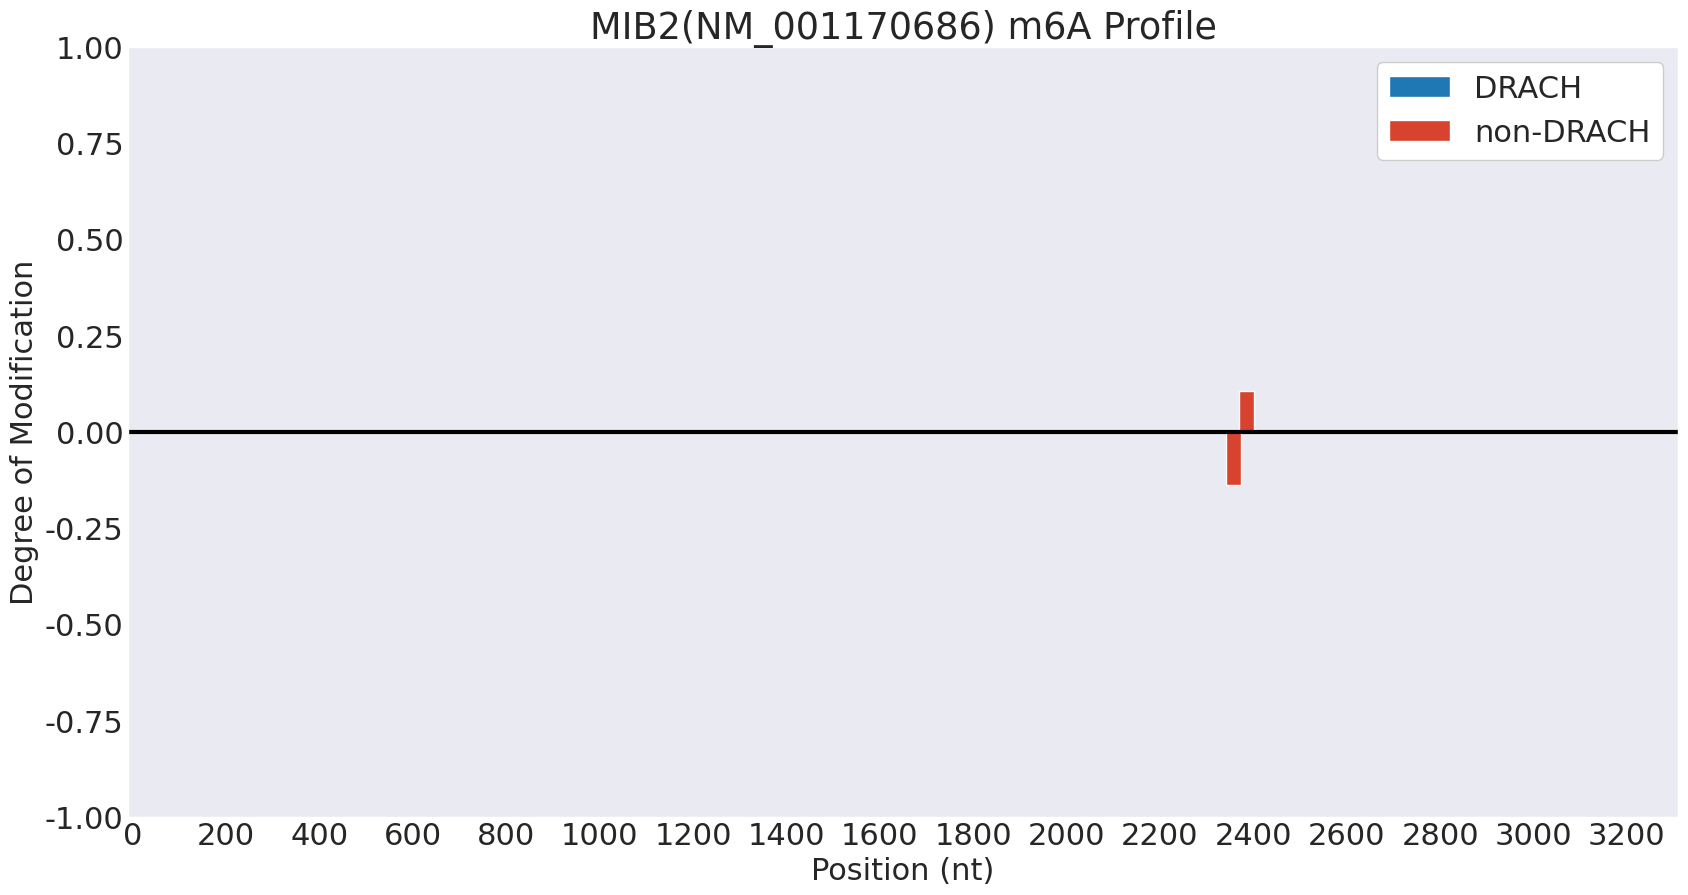

NM_001184720


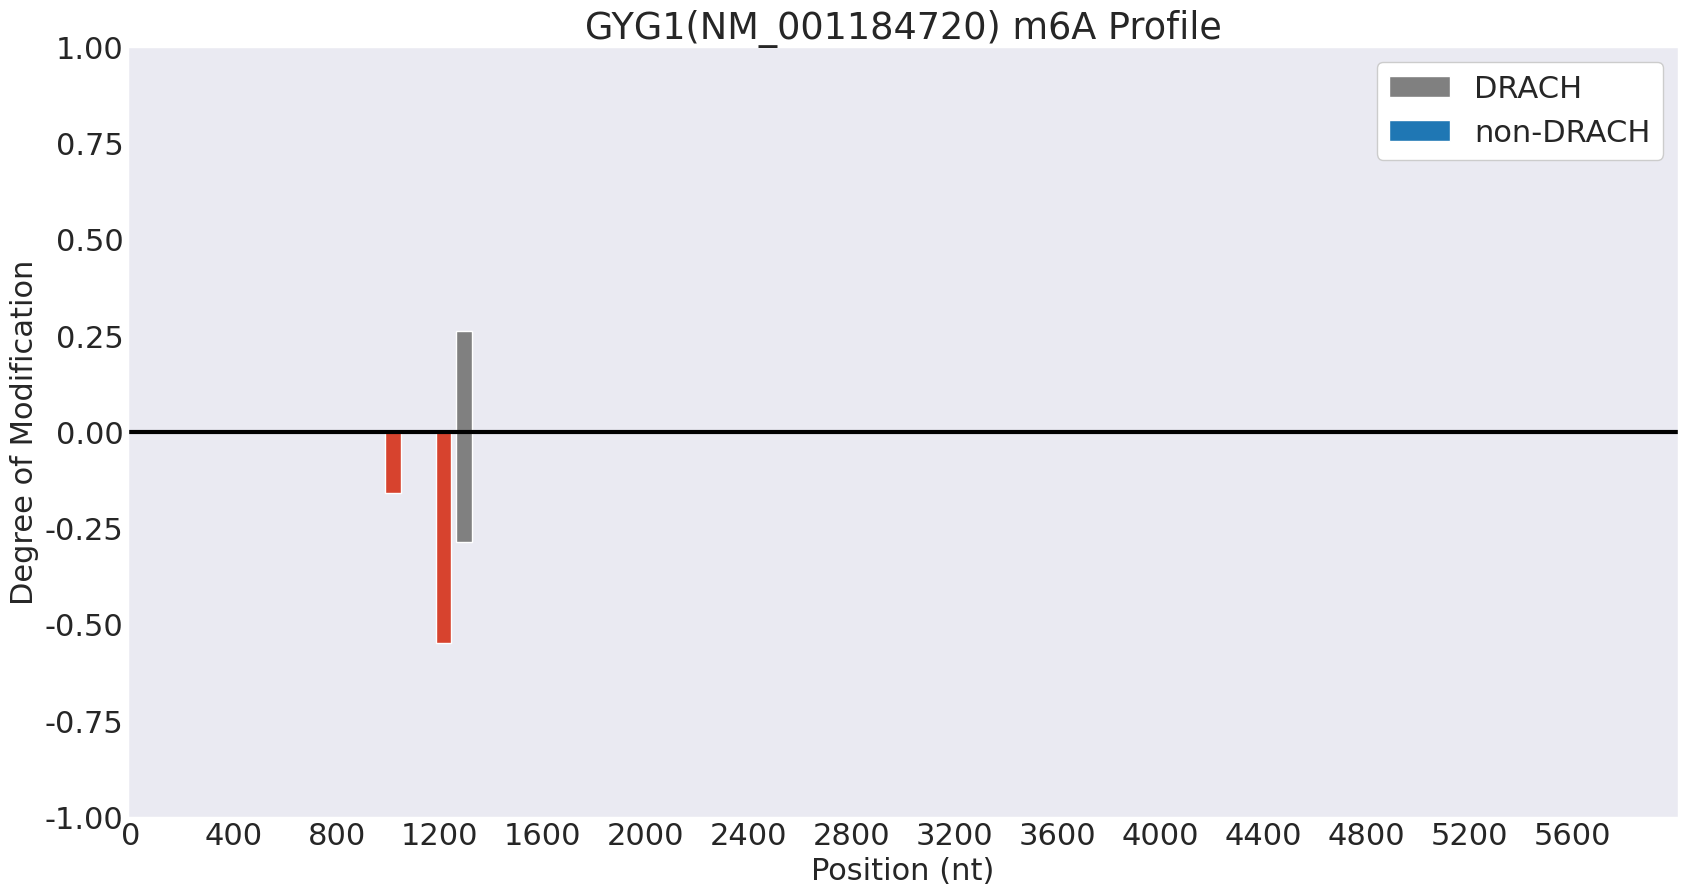

NM_001271662


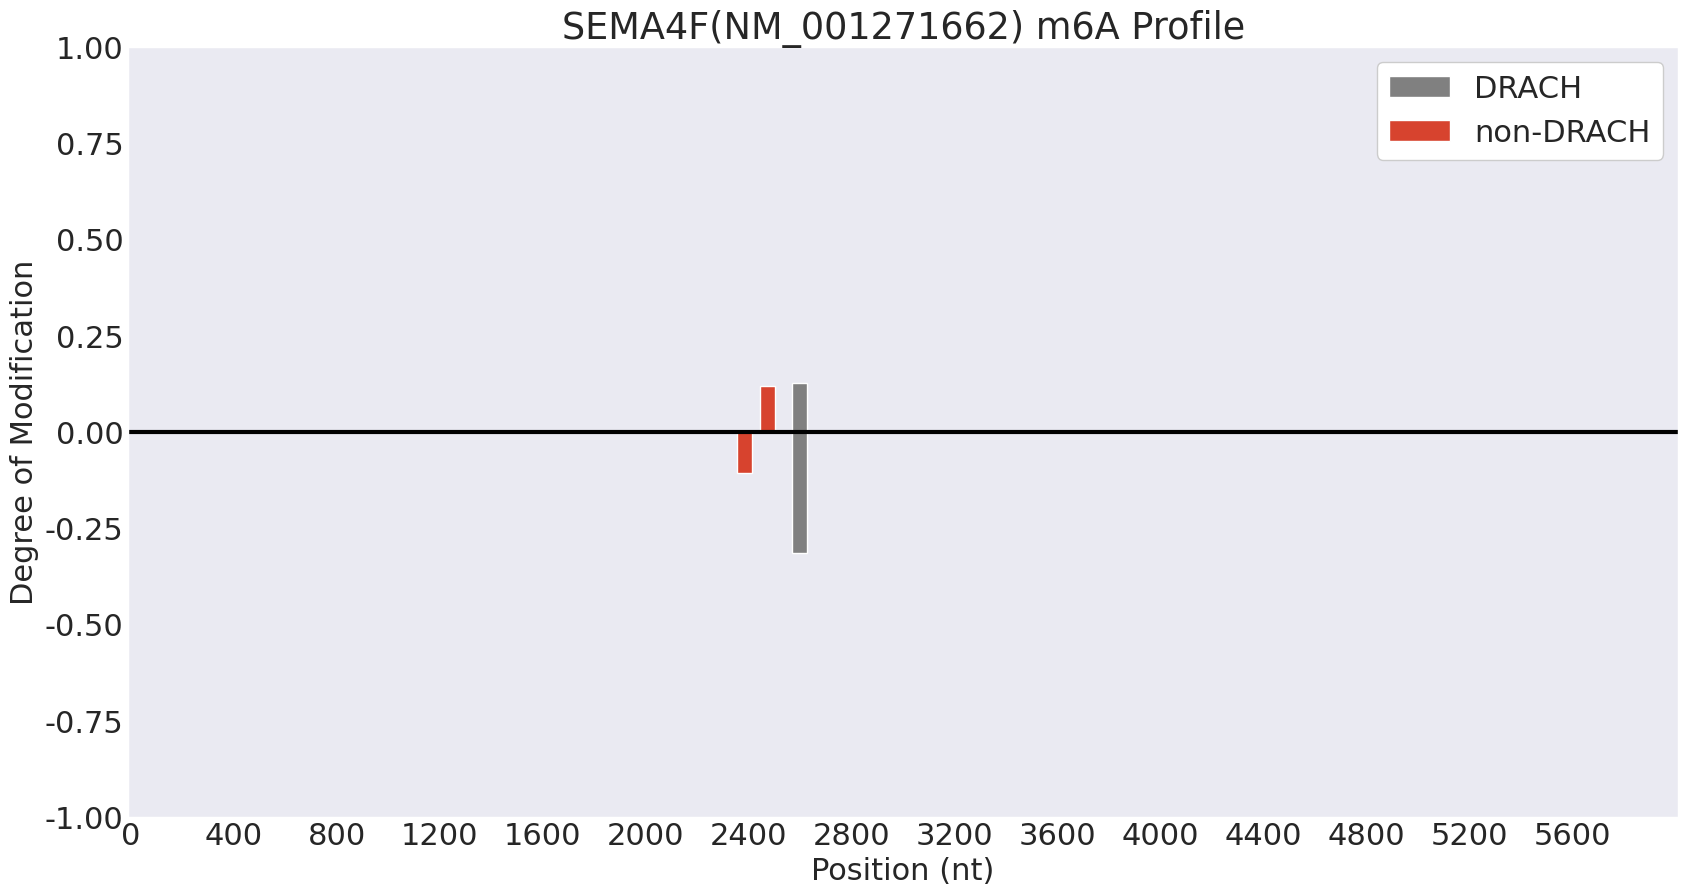

NM_001276293


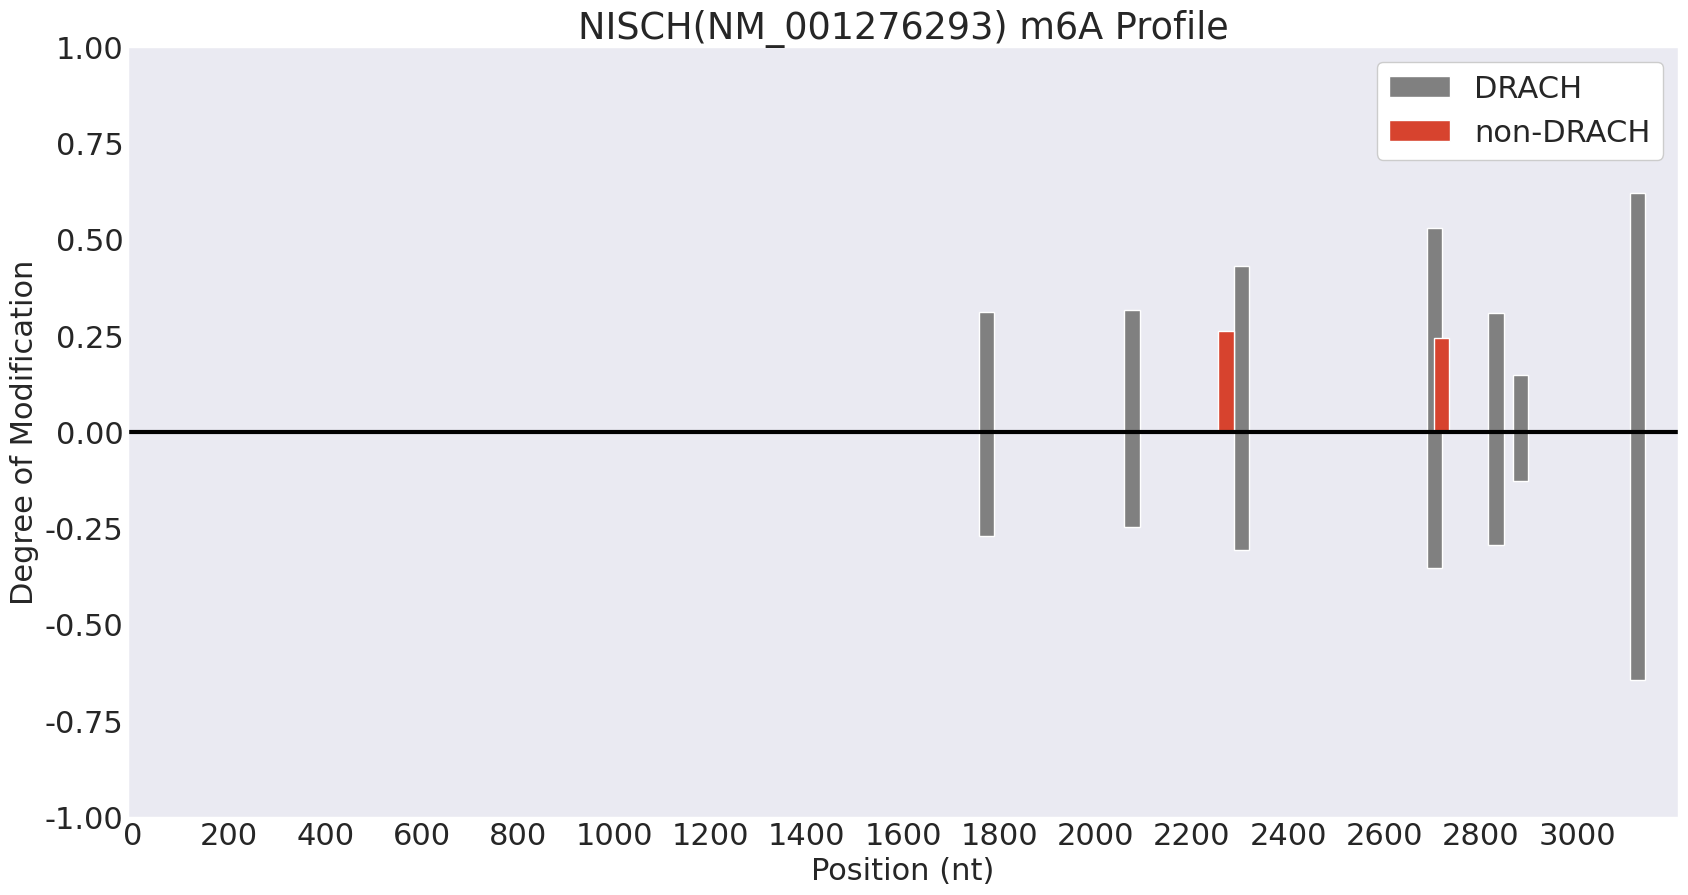

NM_001282953


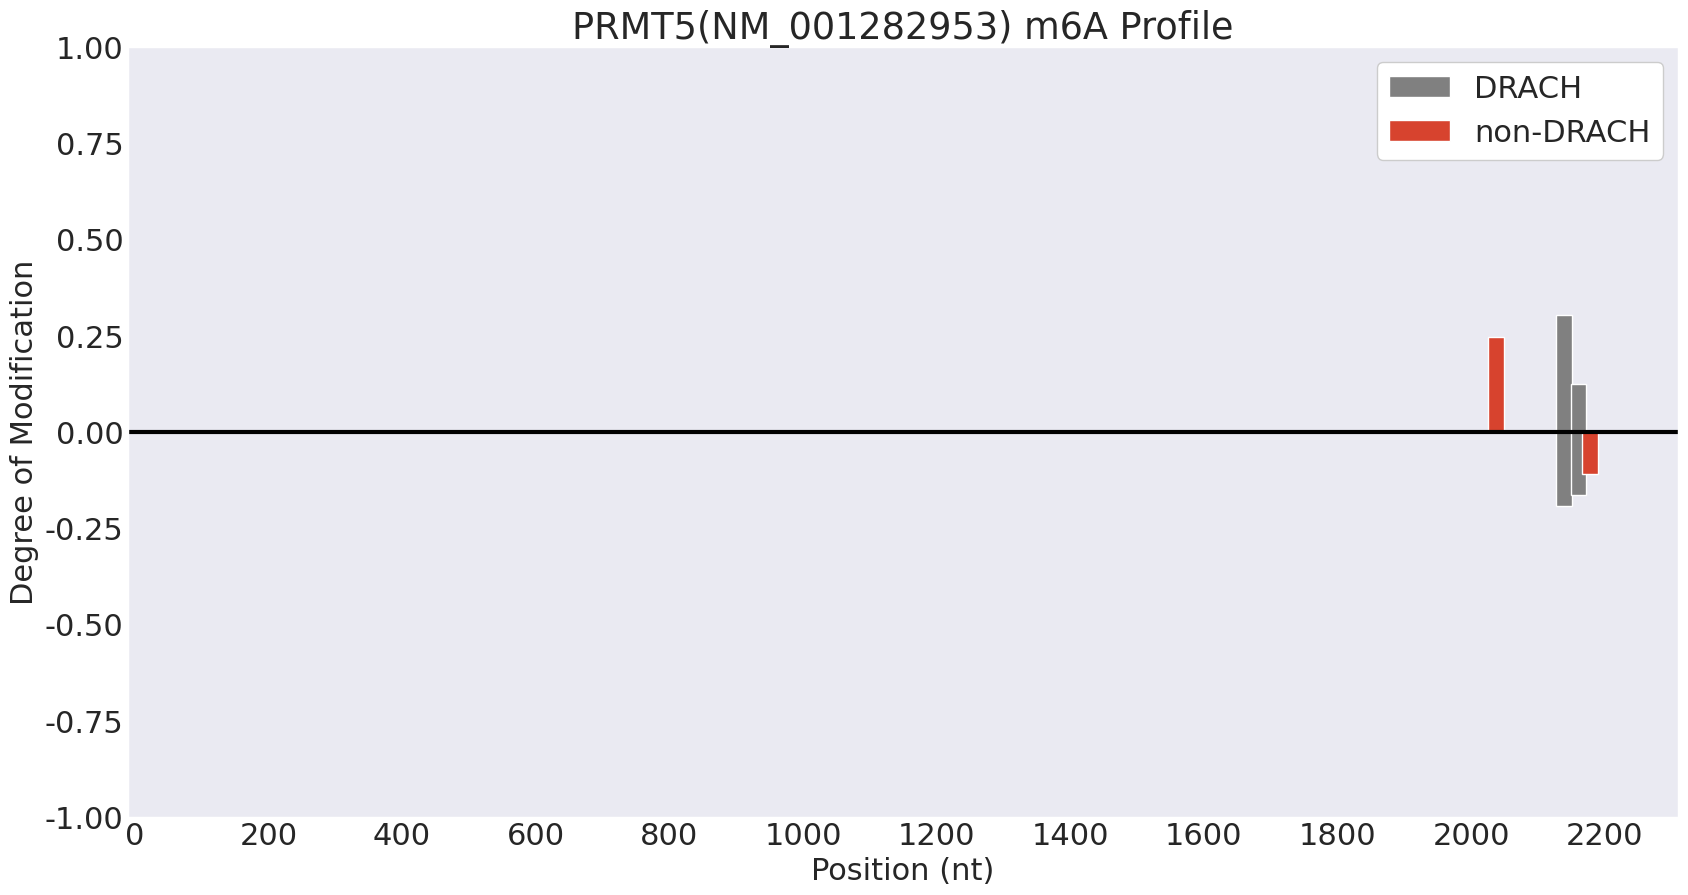

NM_001282955


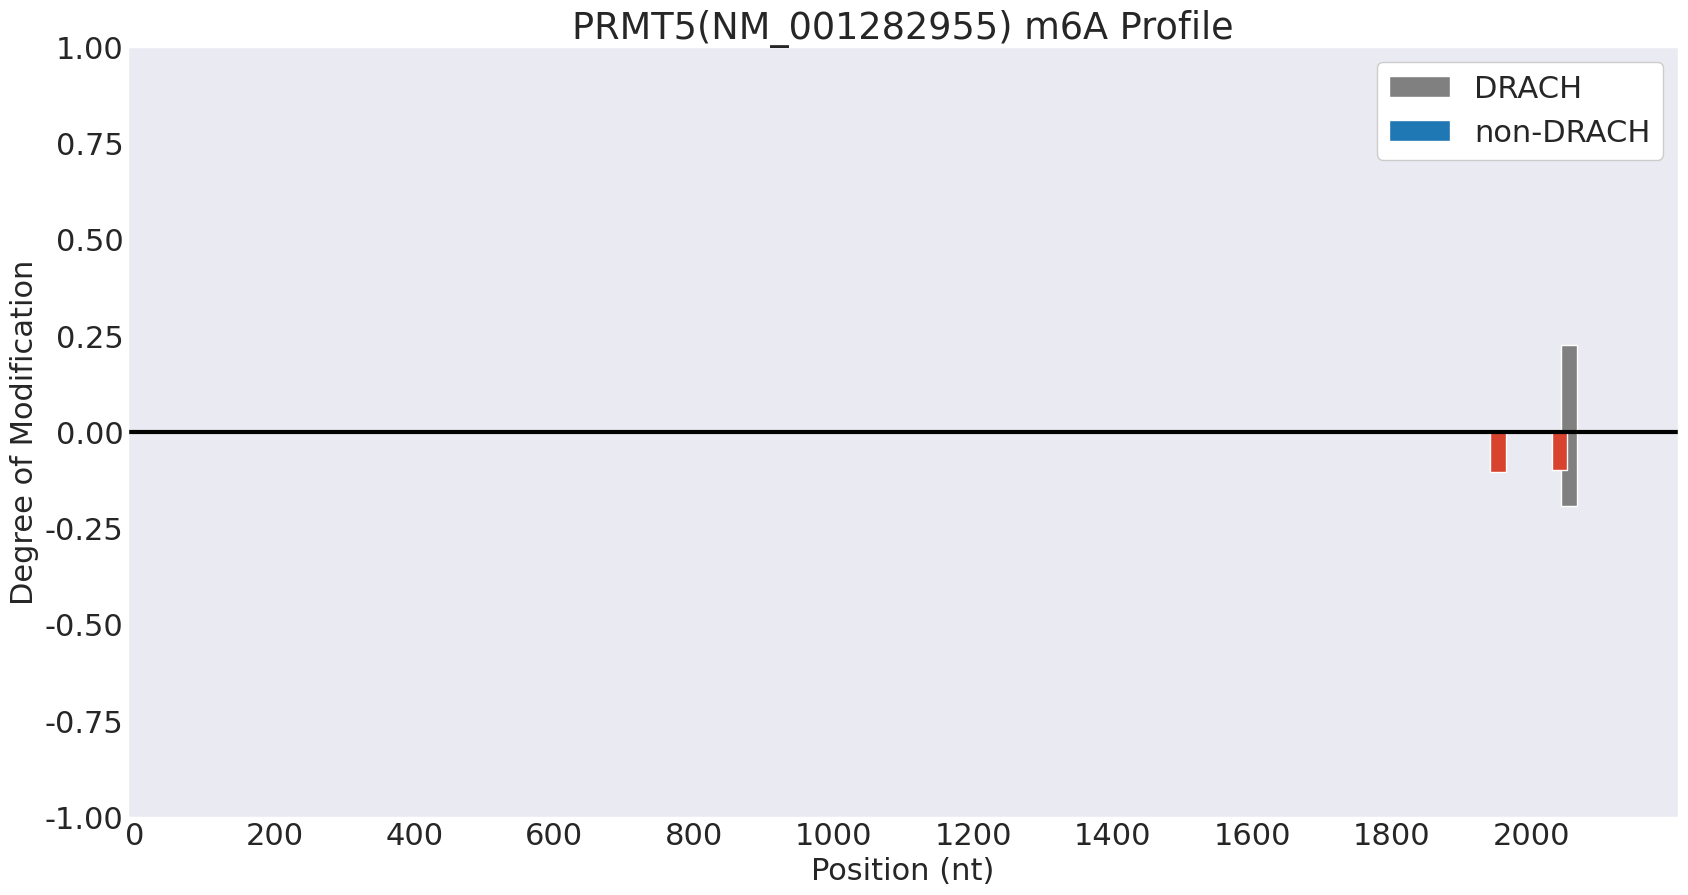

NM_001284215


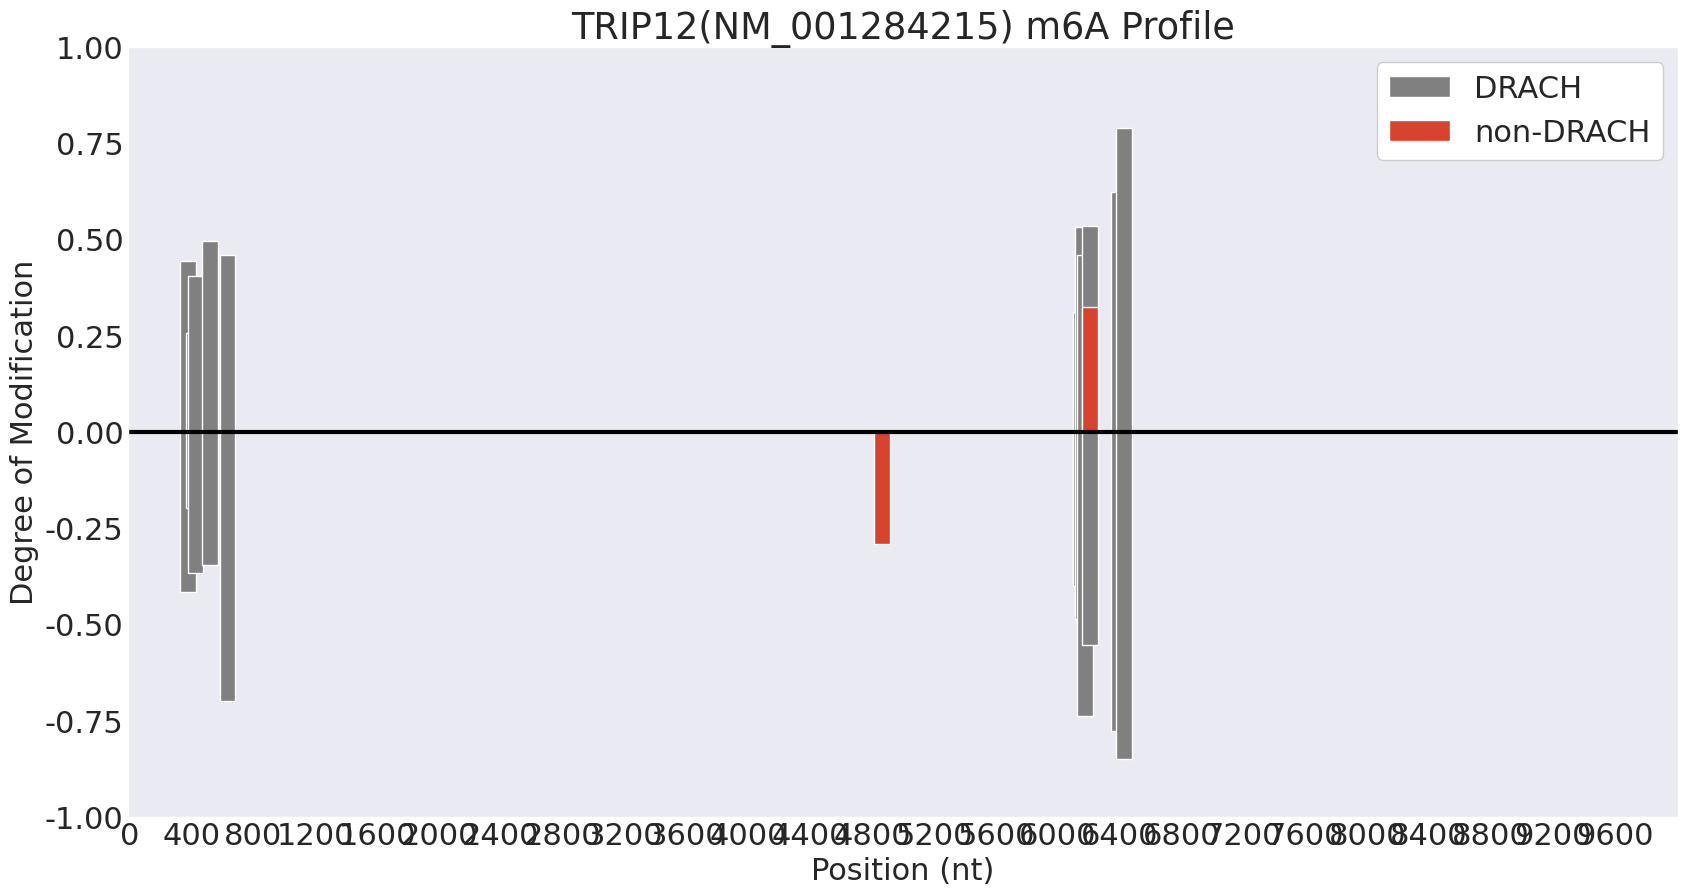

NM_001289174


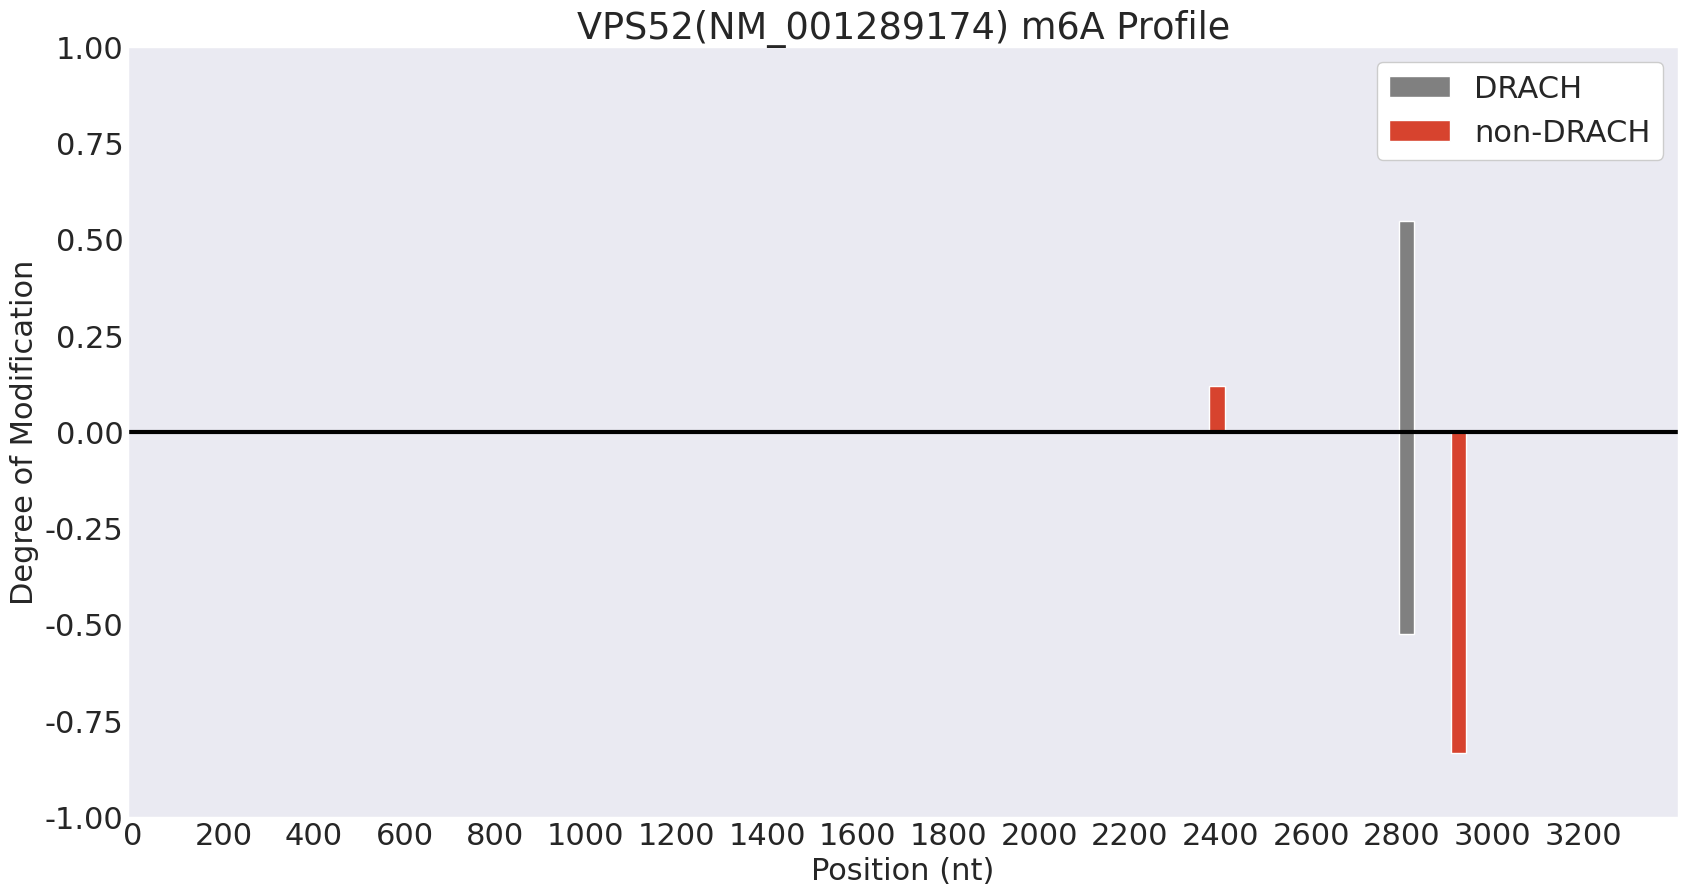

NM_001352281


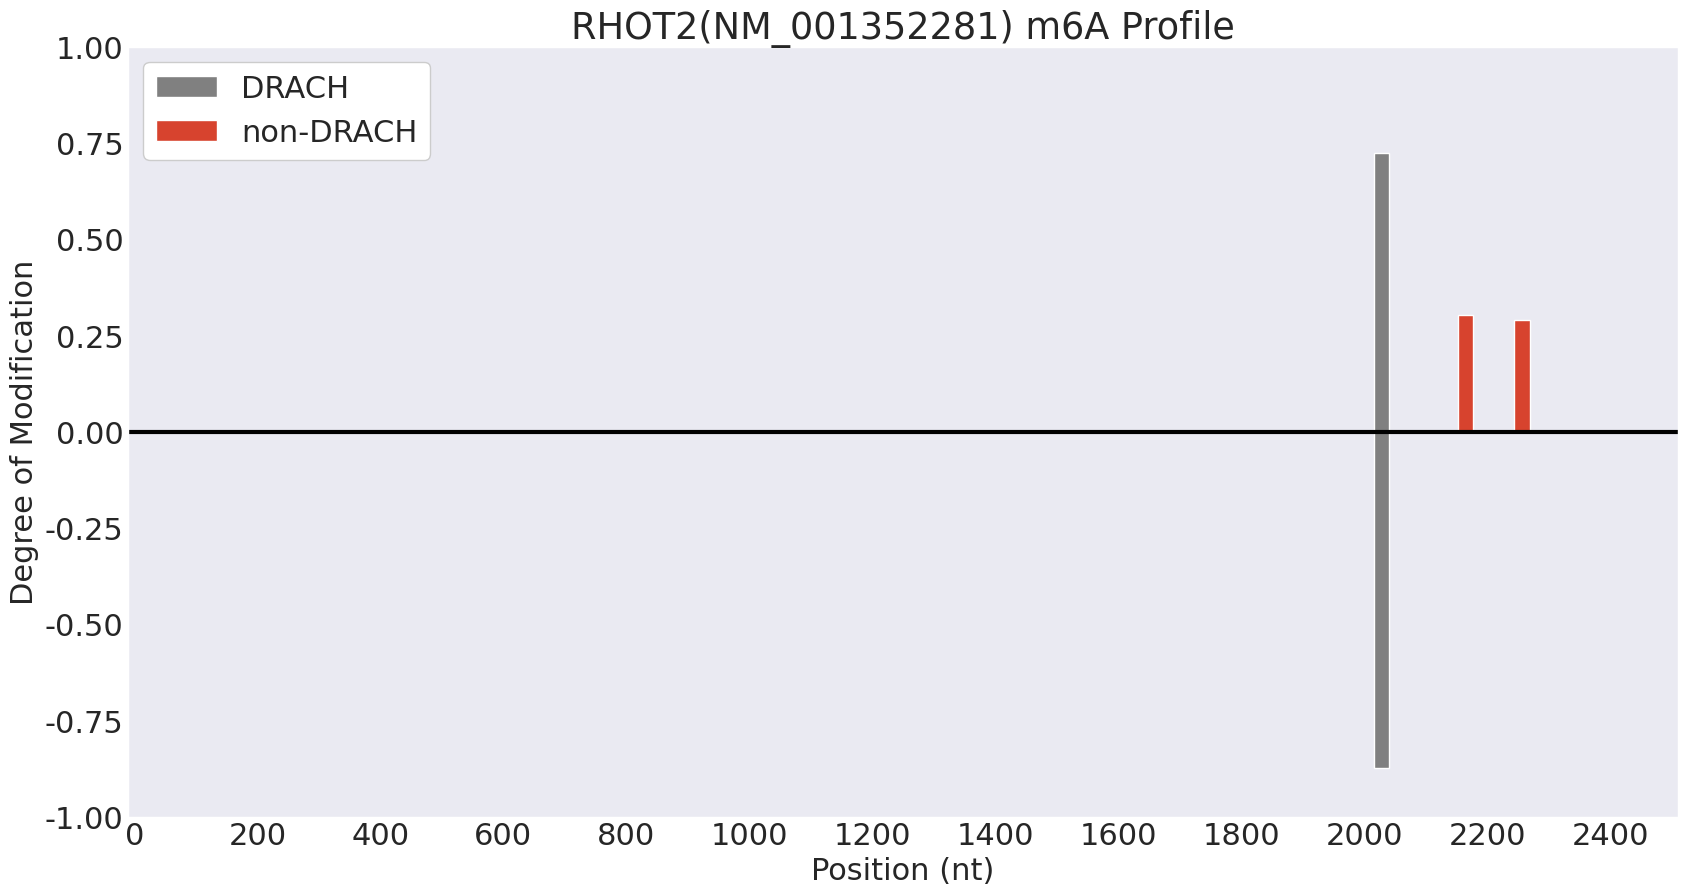

NM_001365126


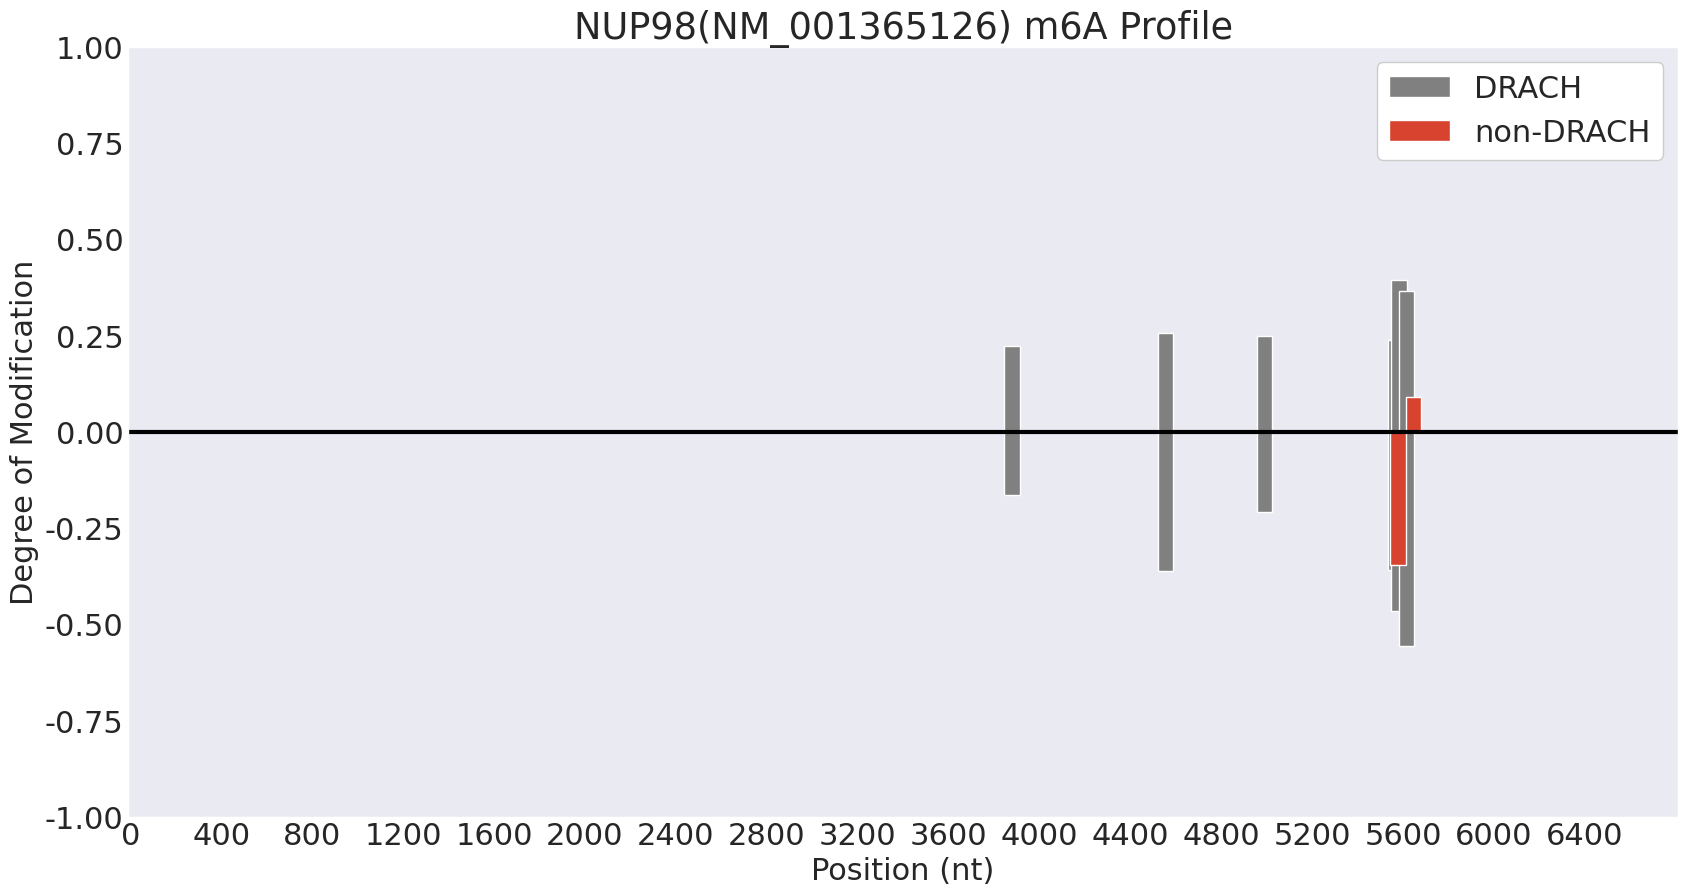

NM_001365819


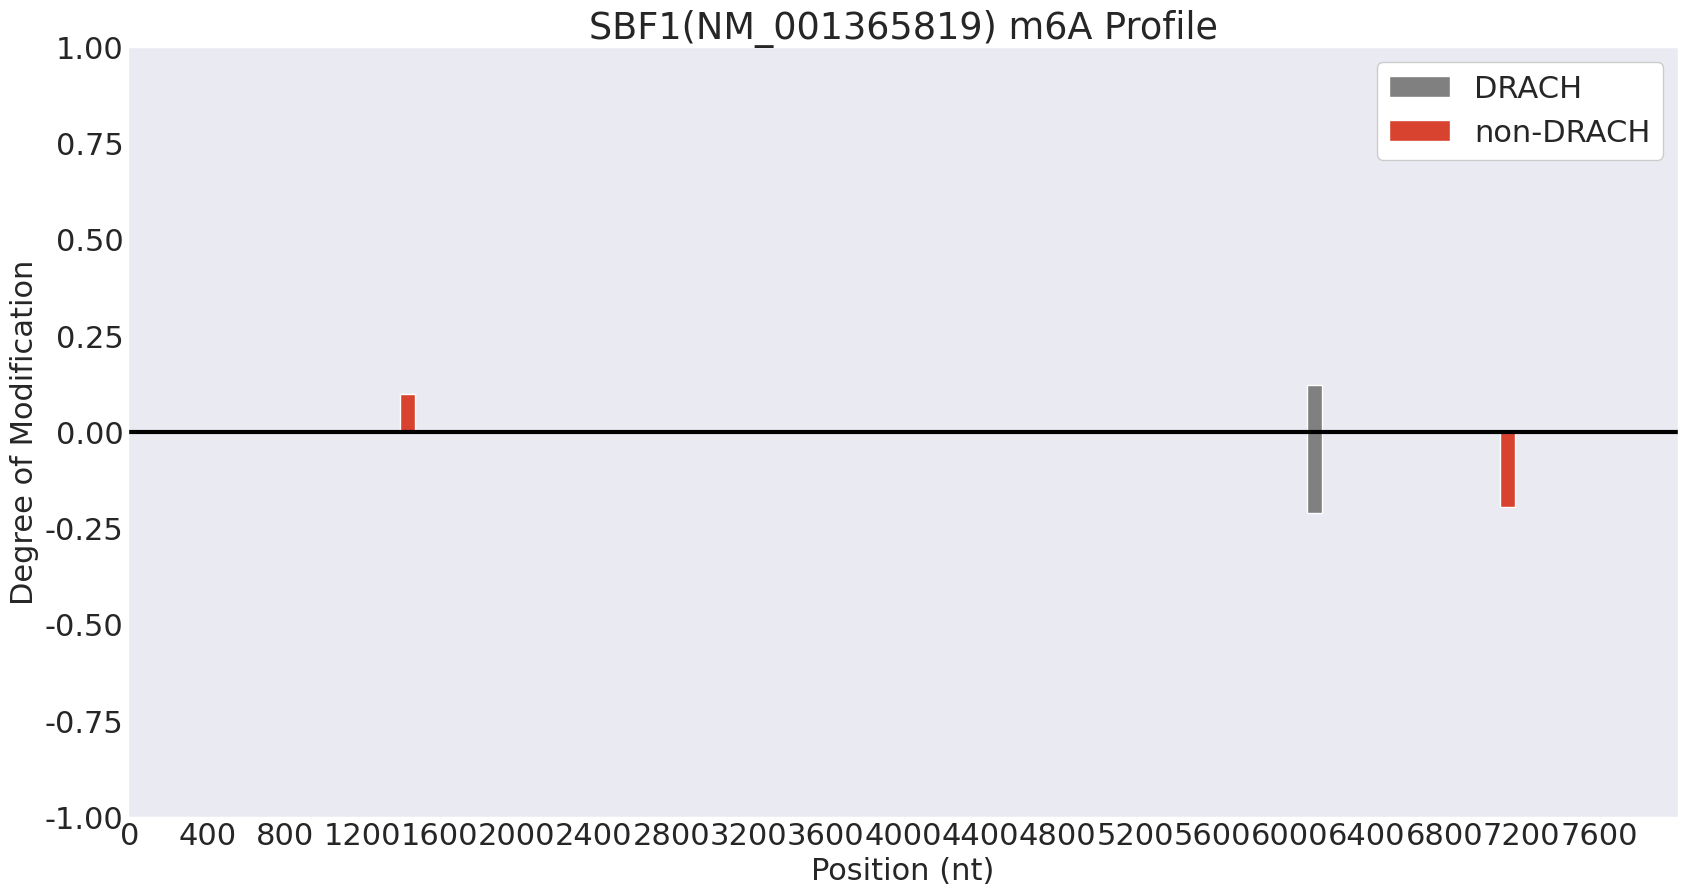

NM_001372057


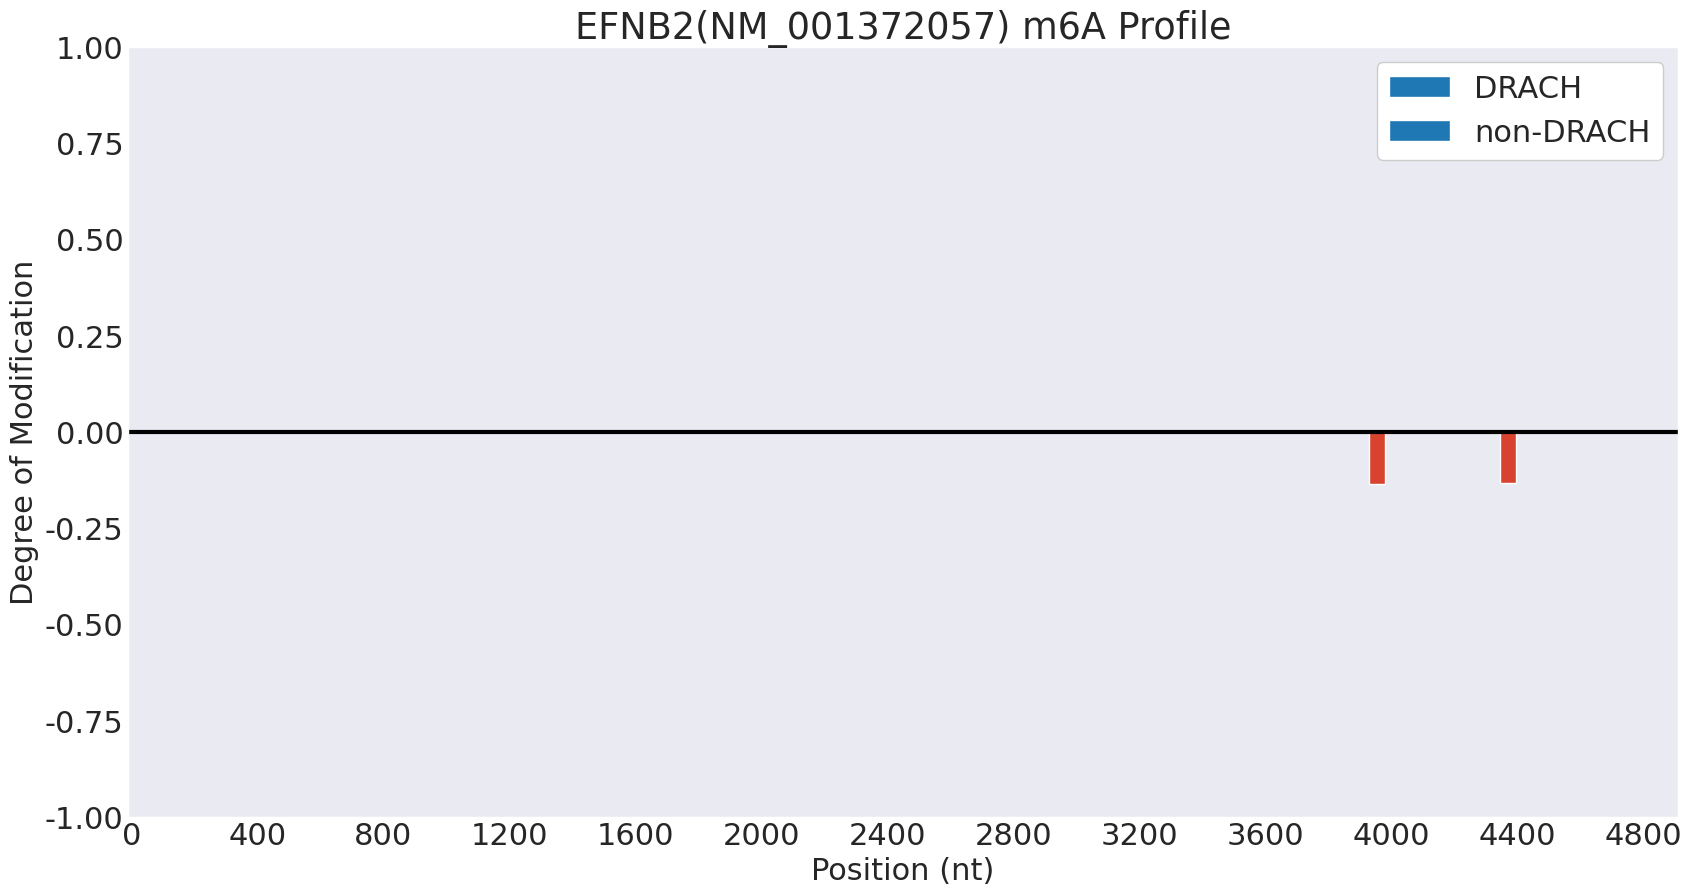

NM_001388006


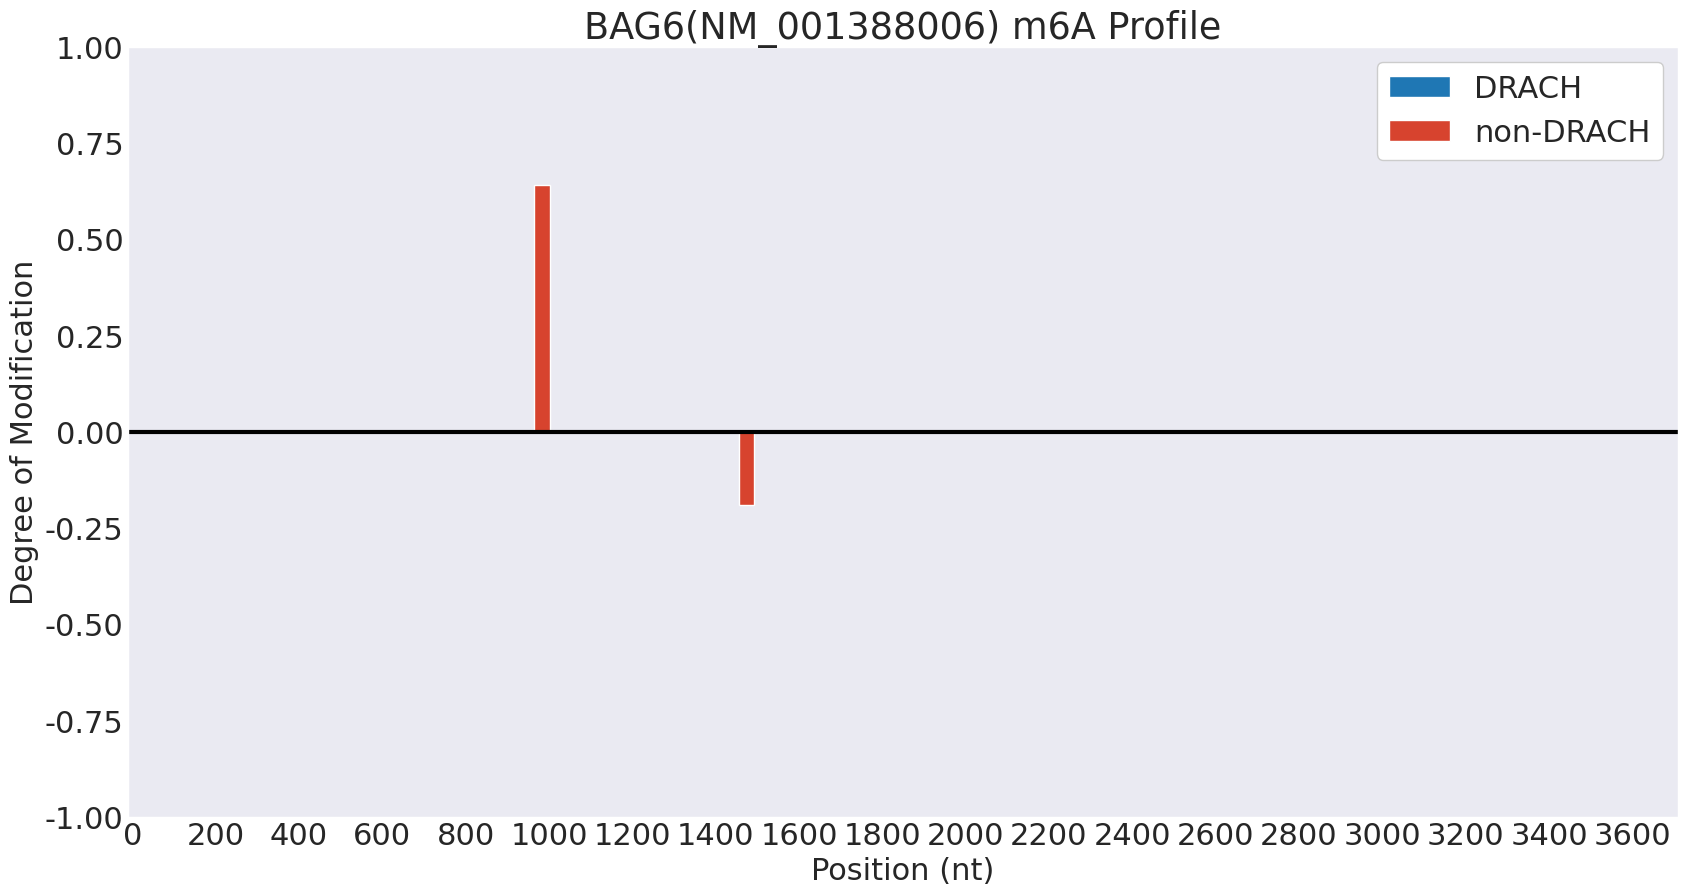

NM_001389631


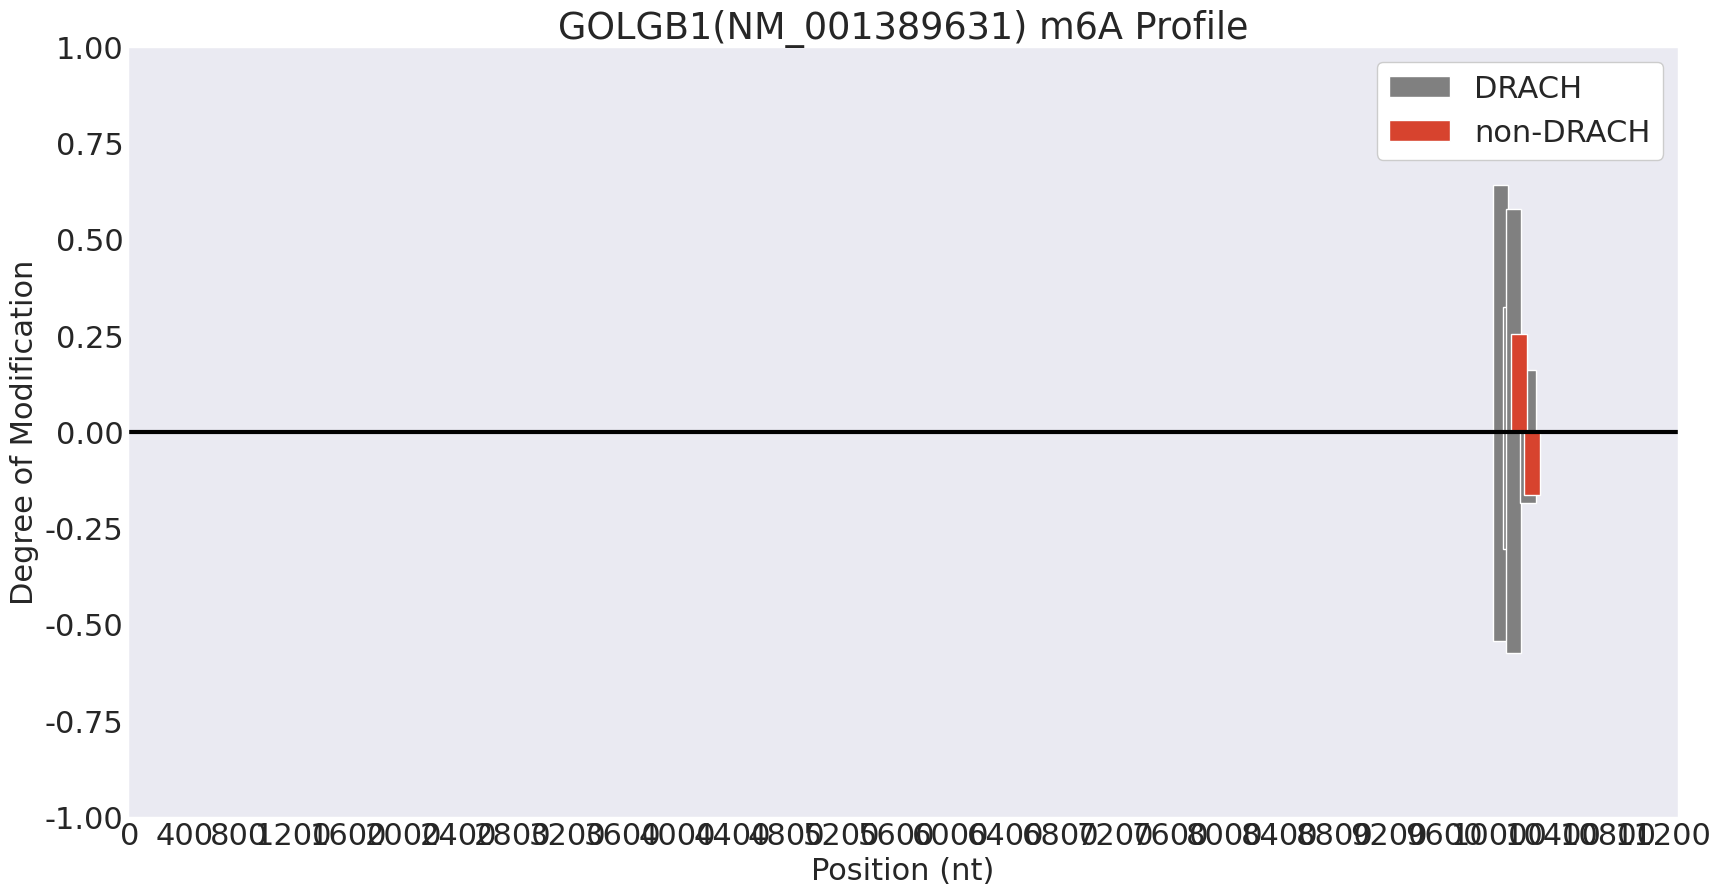

NM_003954


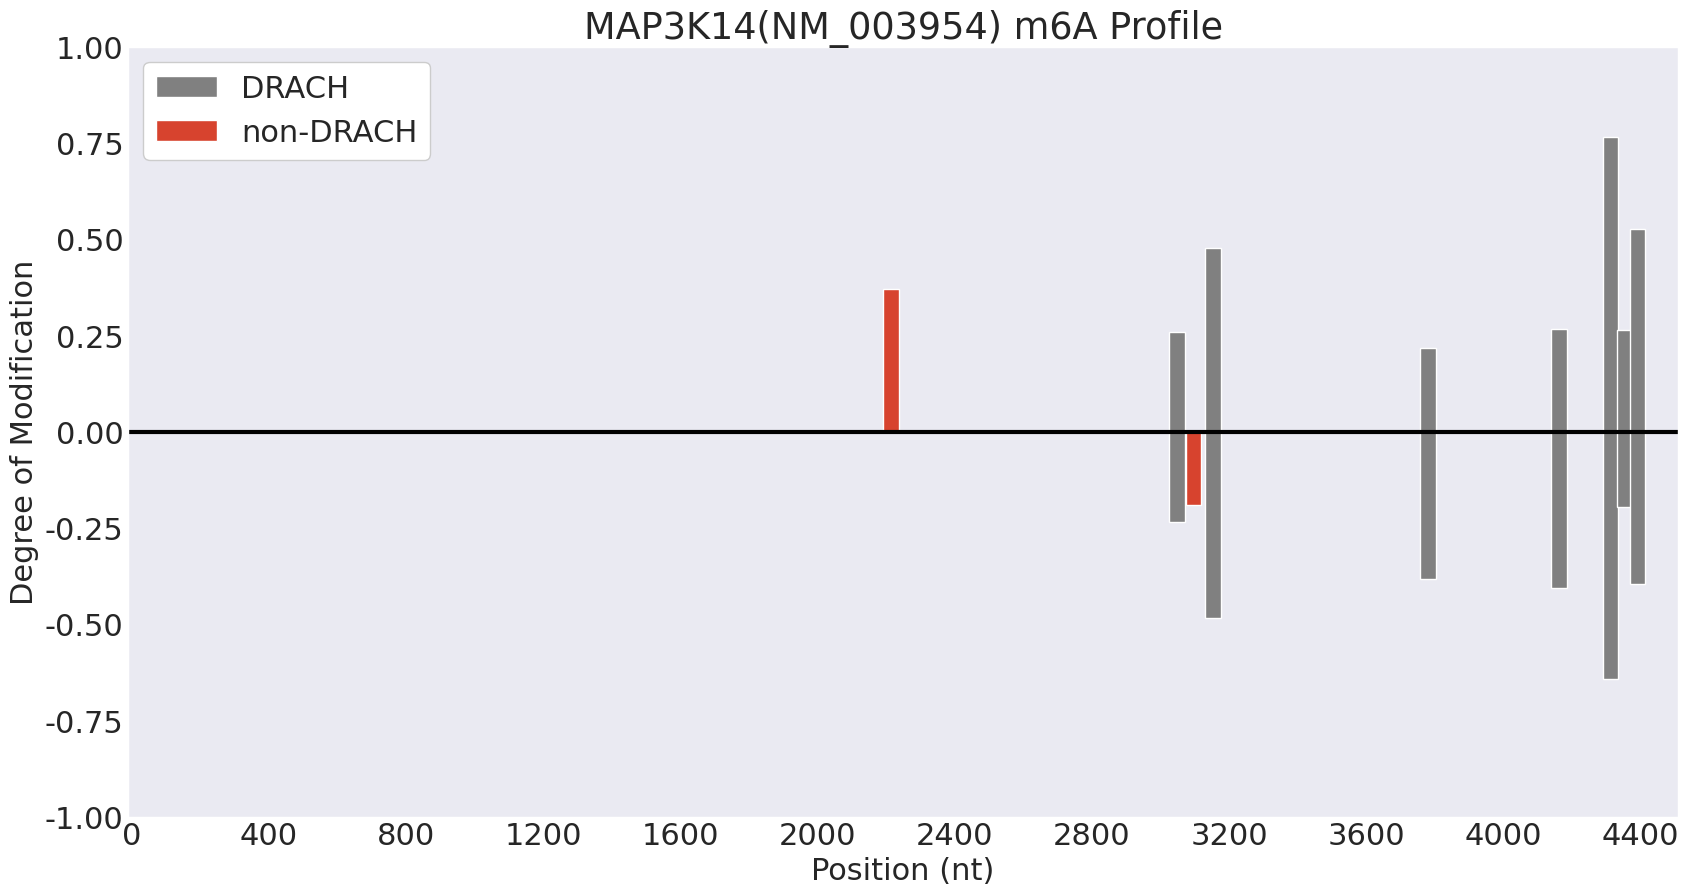

NM_005052


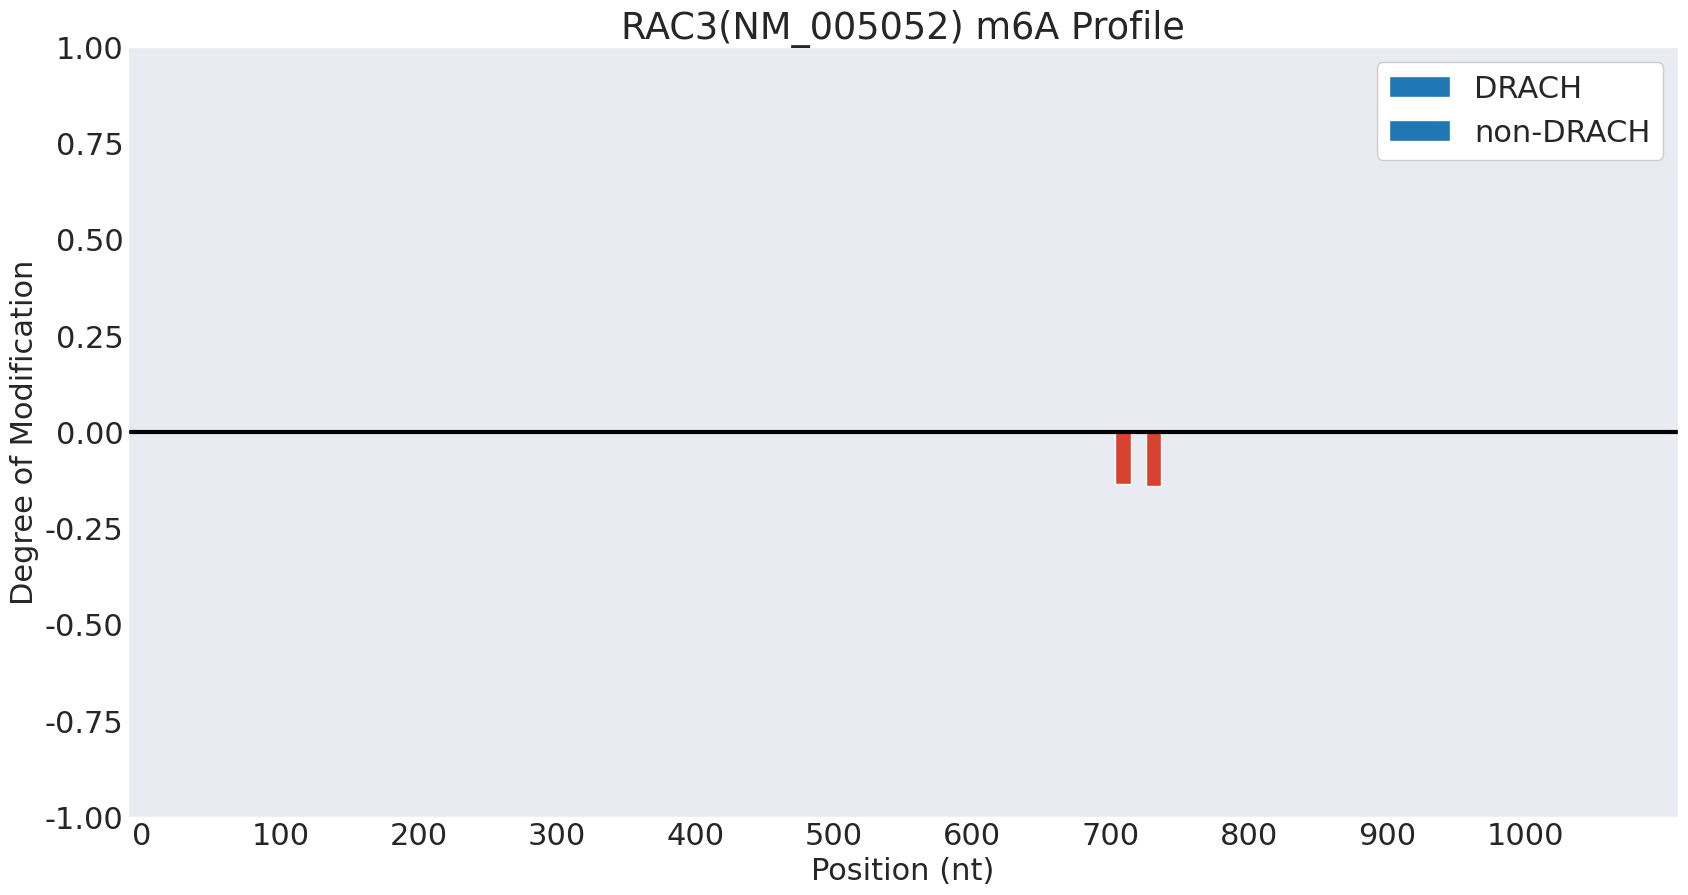

NM_005690


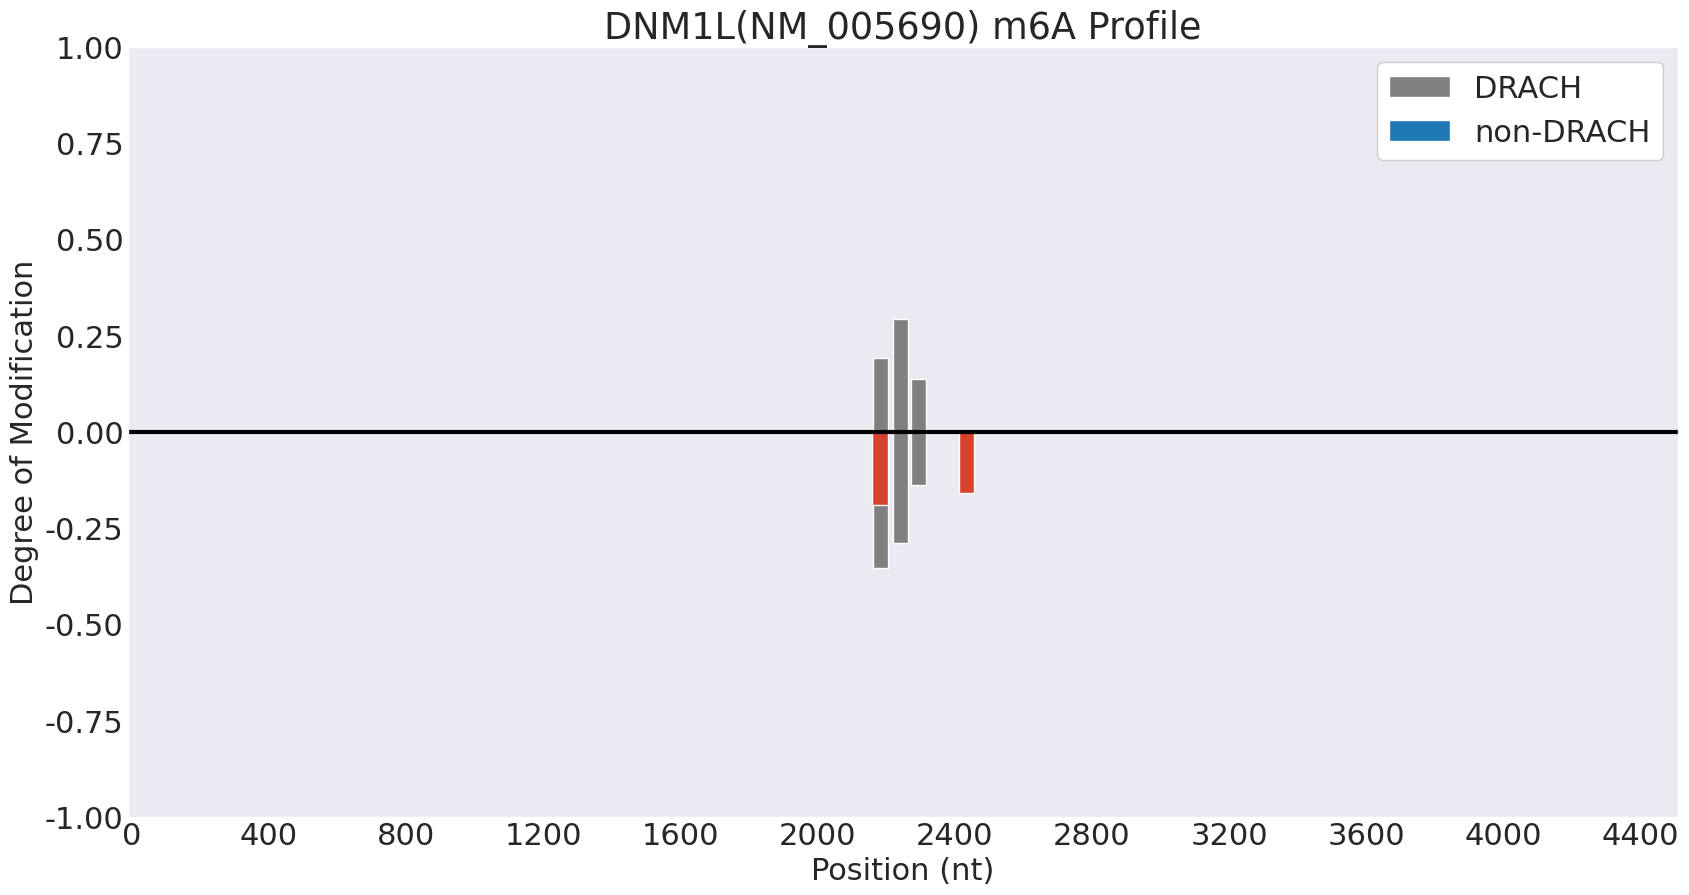

NM_007350


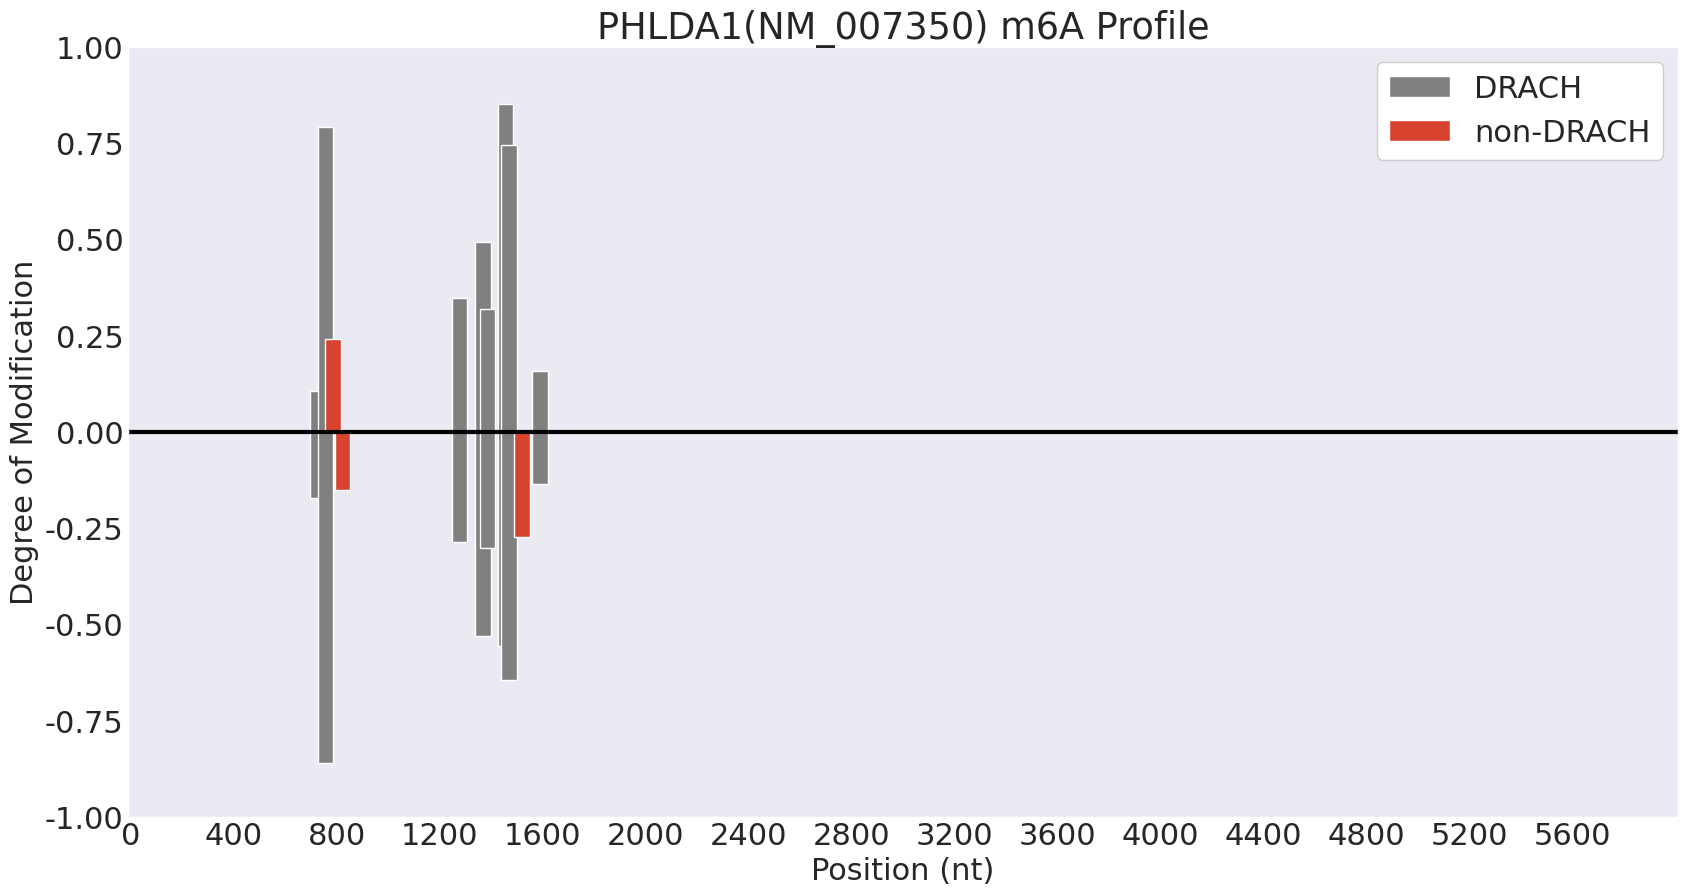

NM_024311


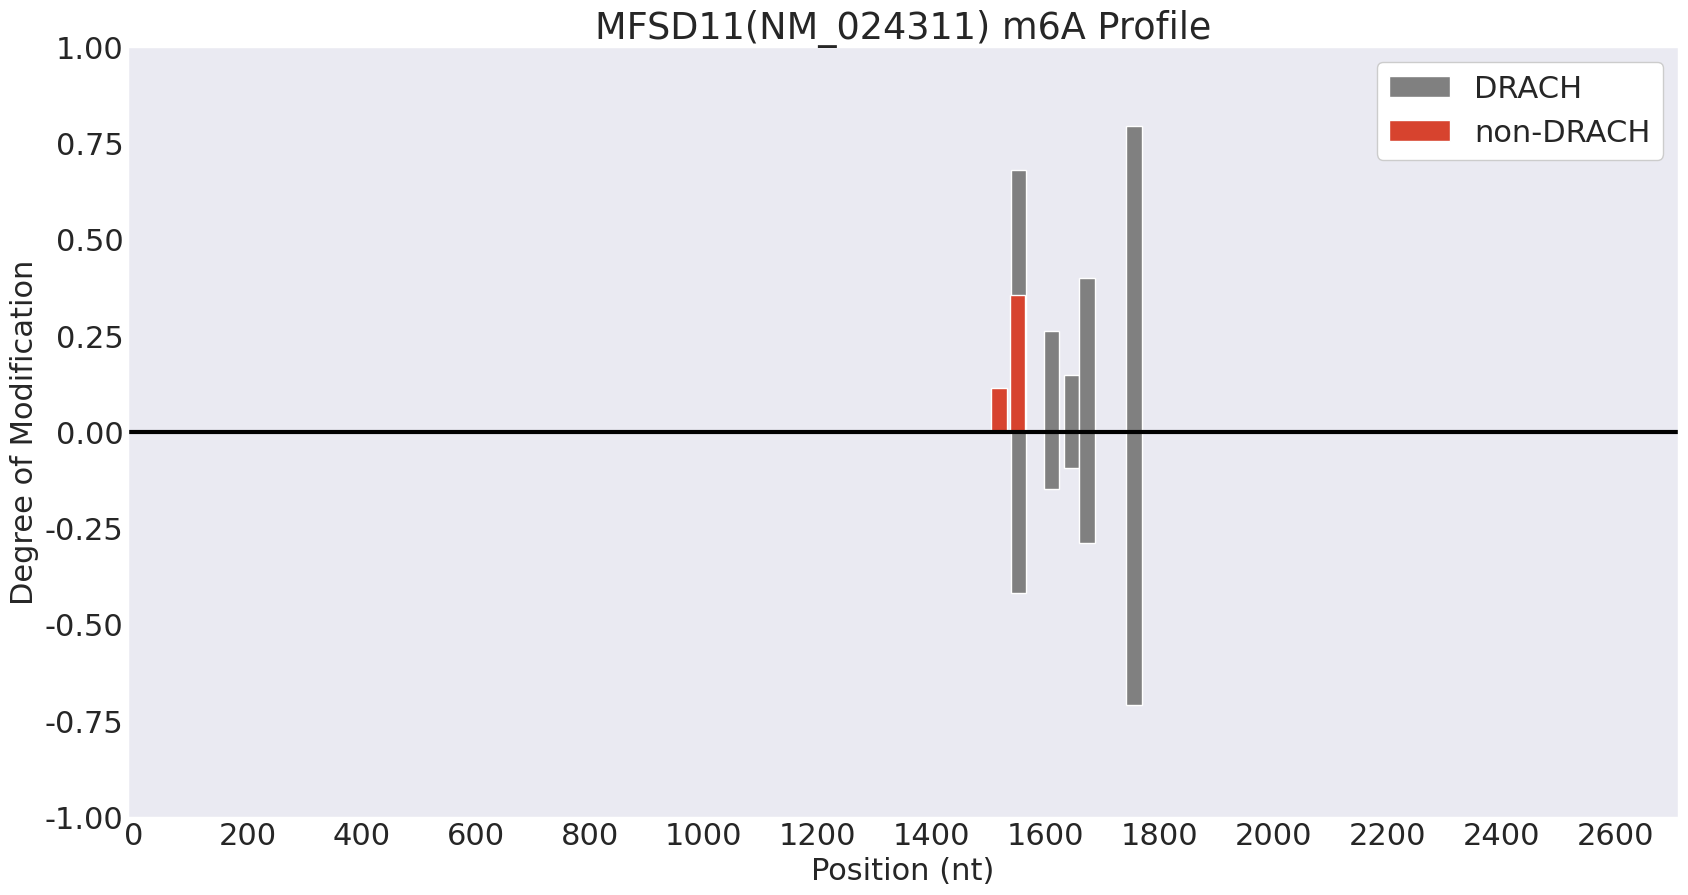

NM_024980


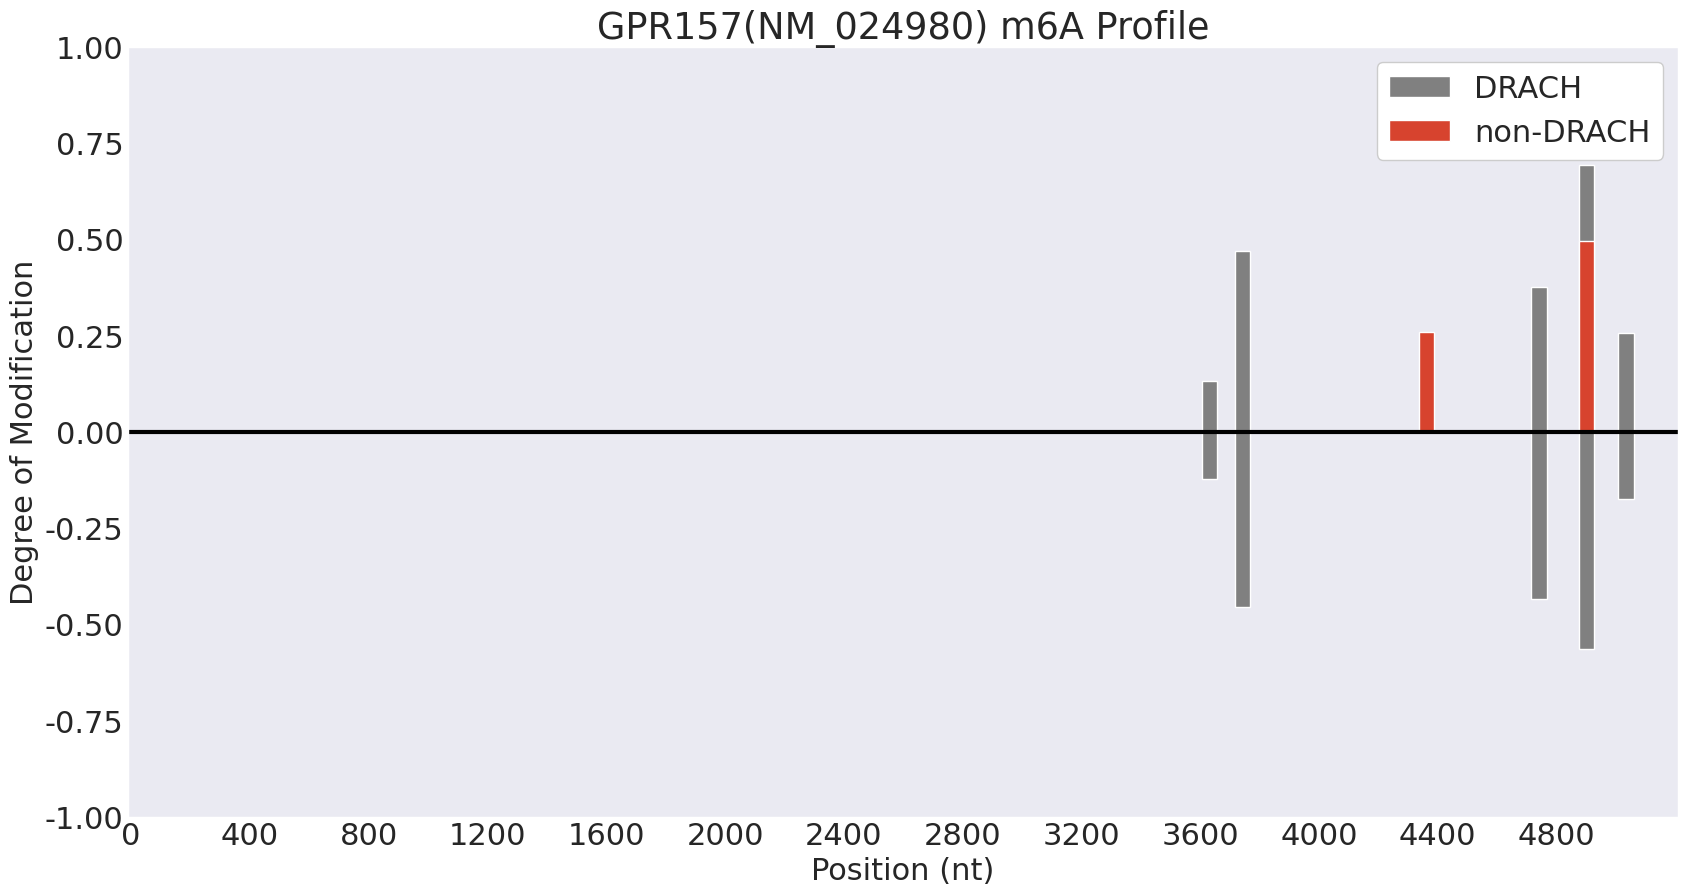

NM_138930


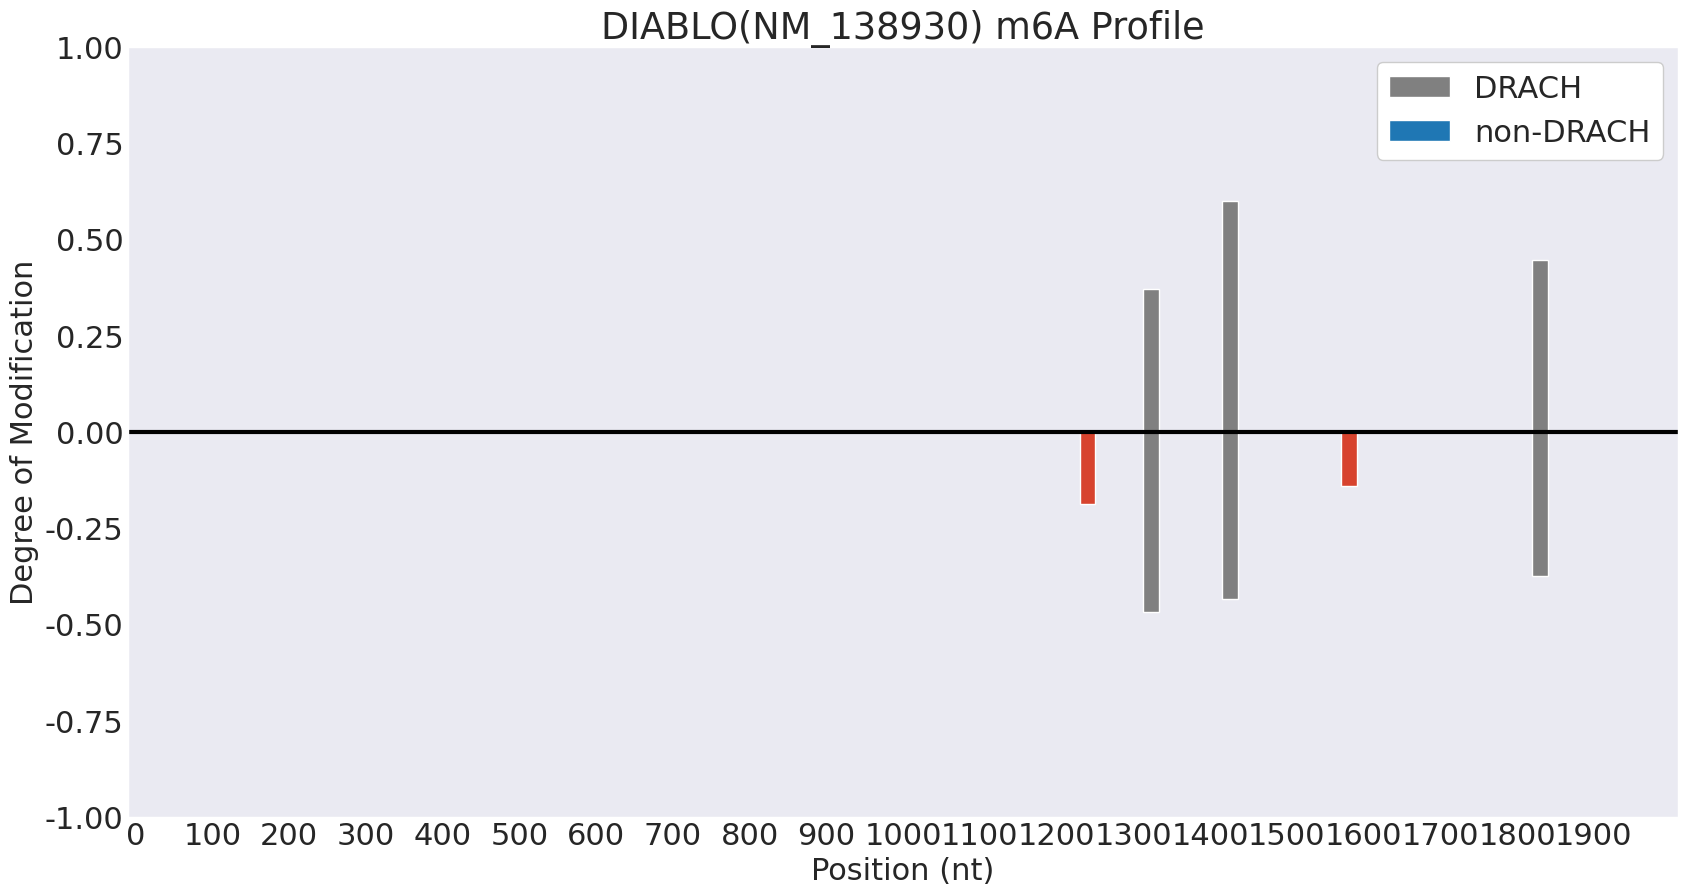

NM_206967


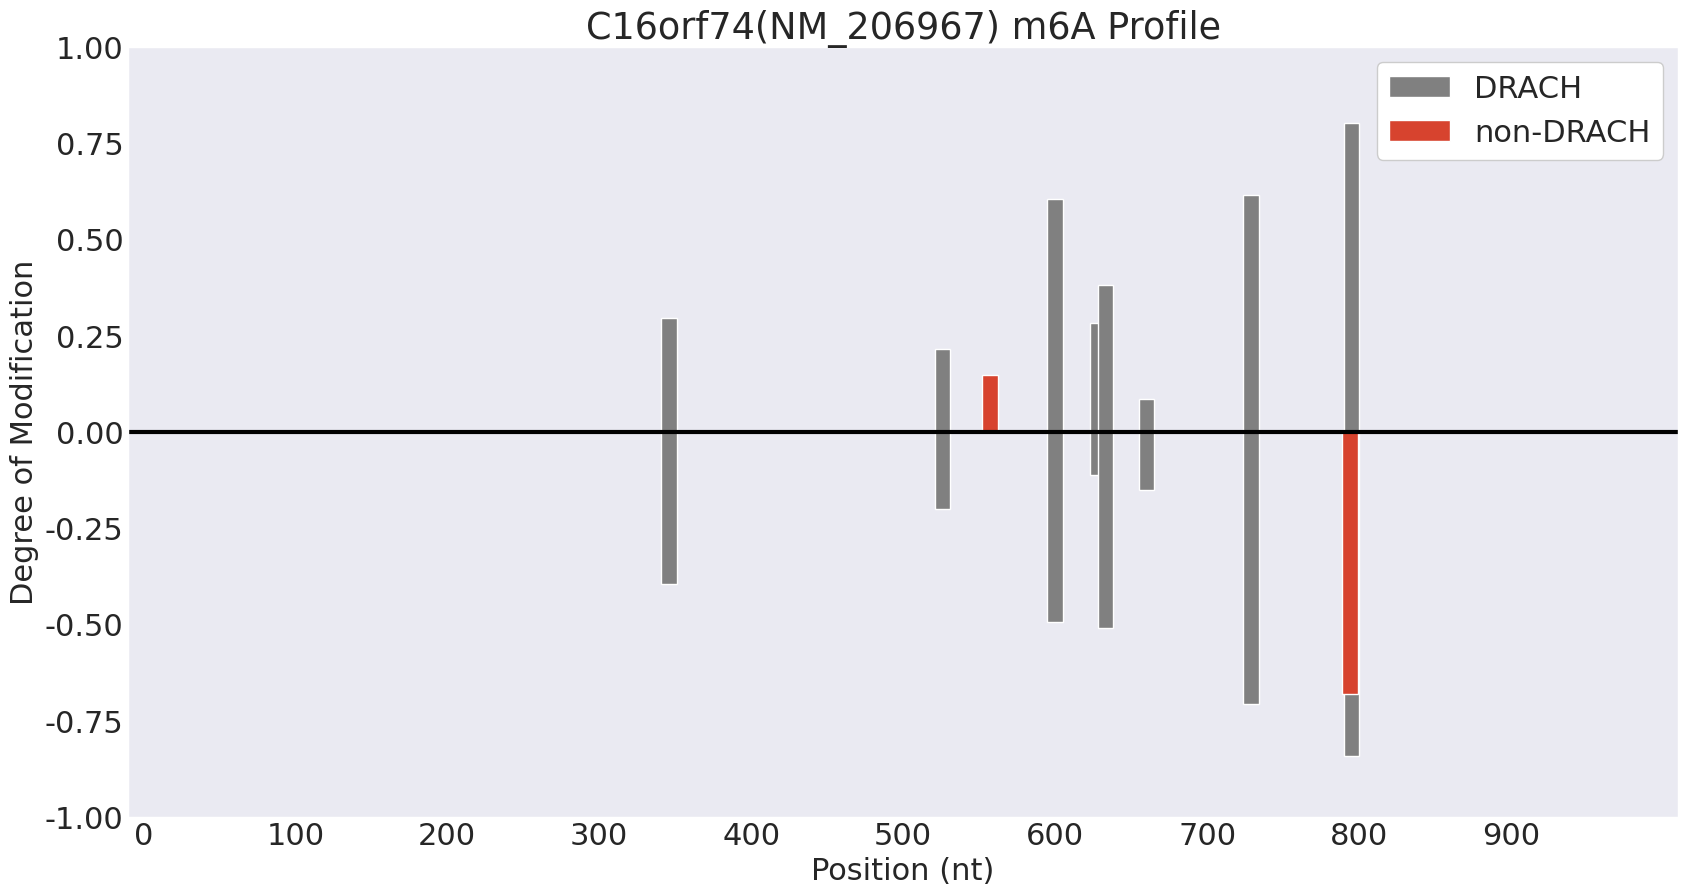

NR_024252


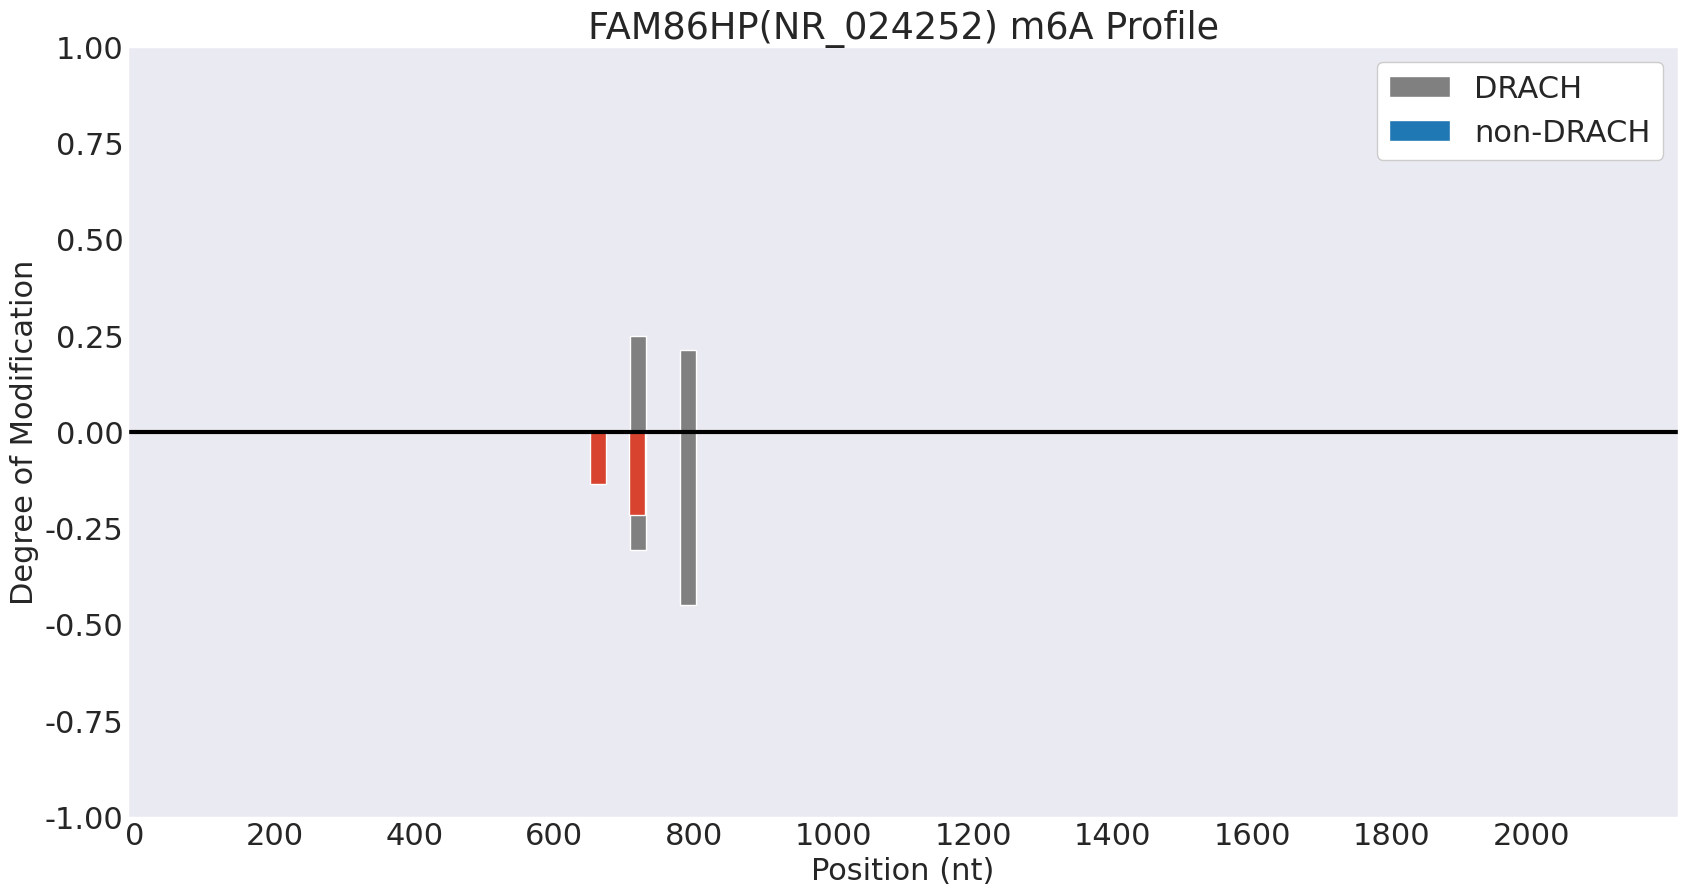

NR_027487


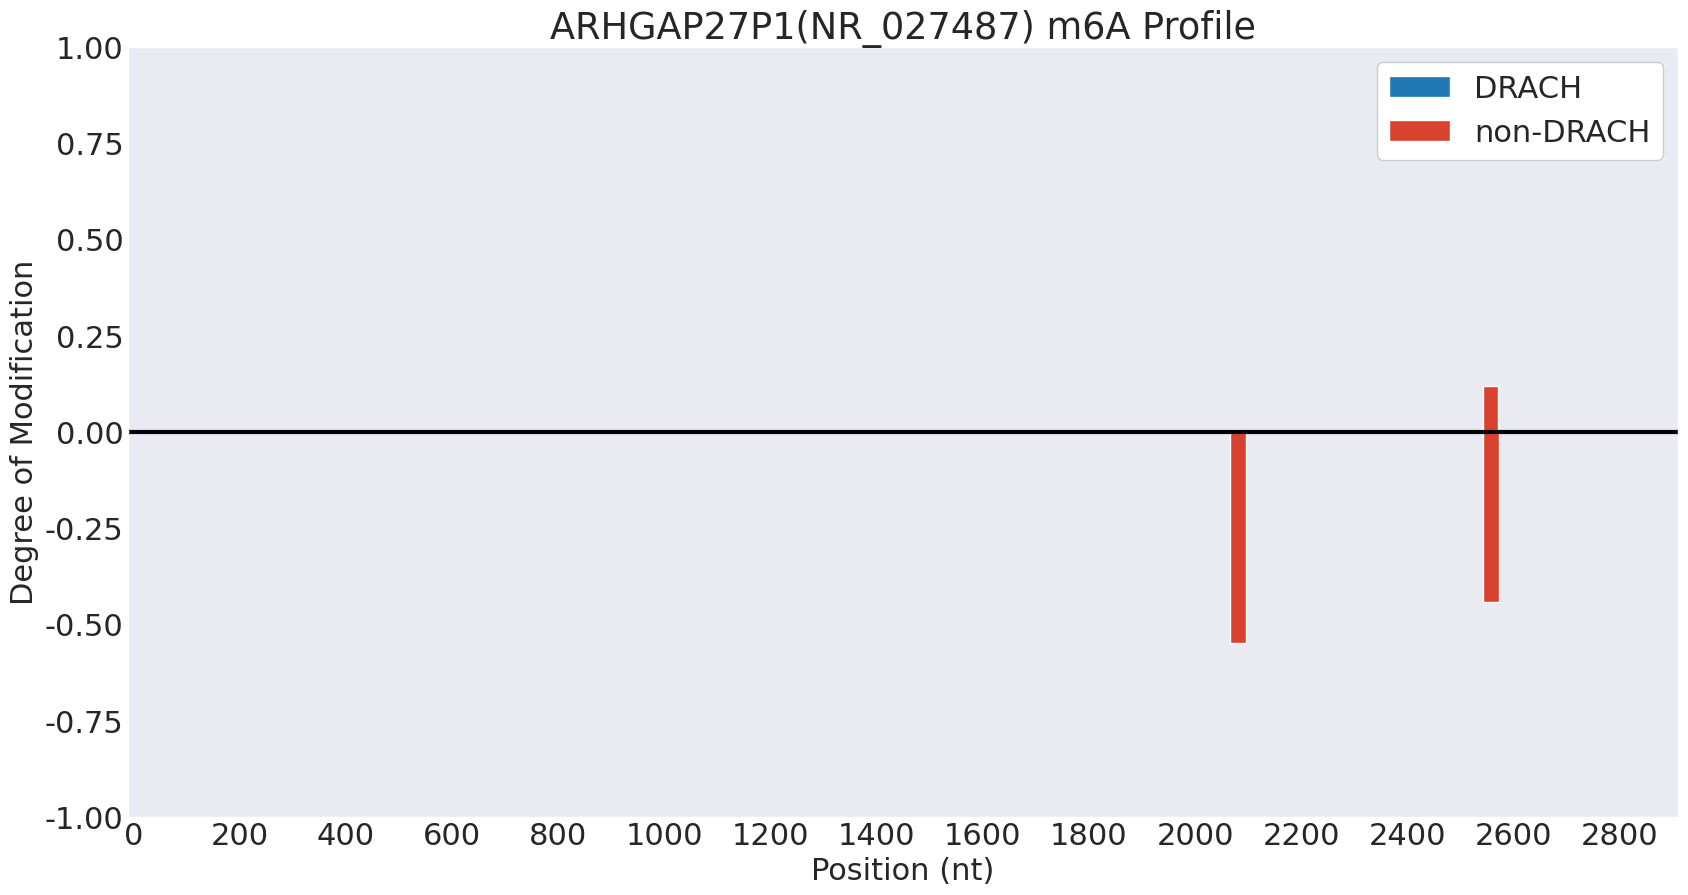

NR_047581


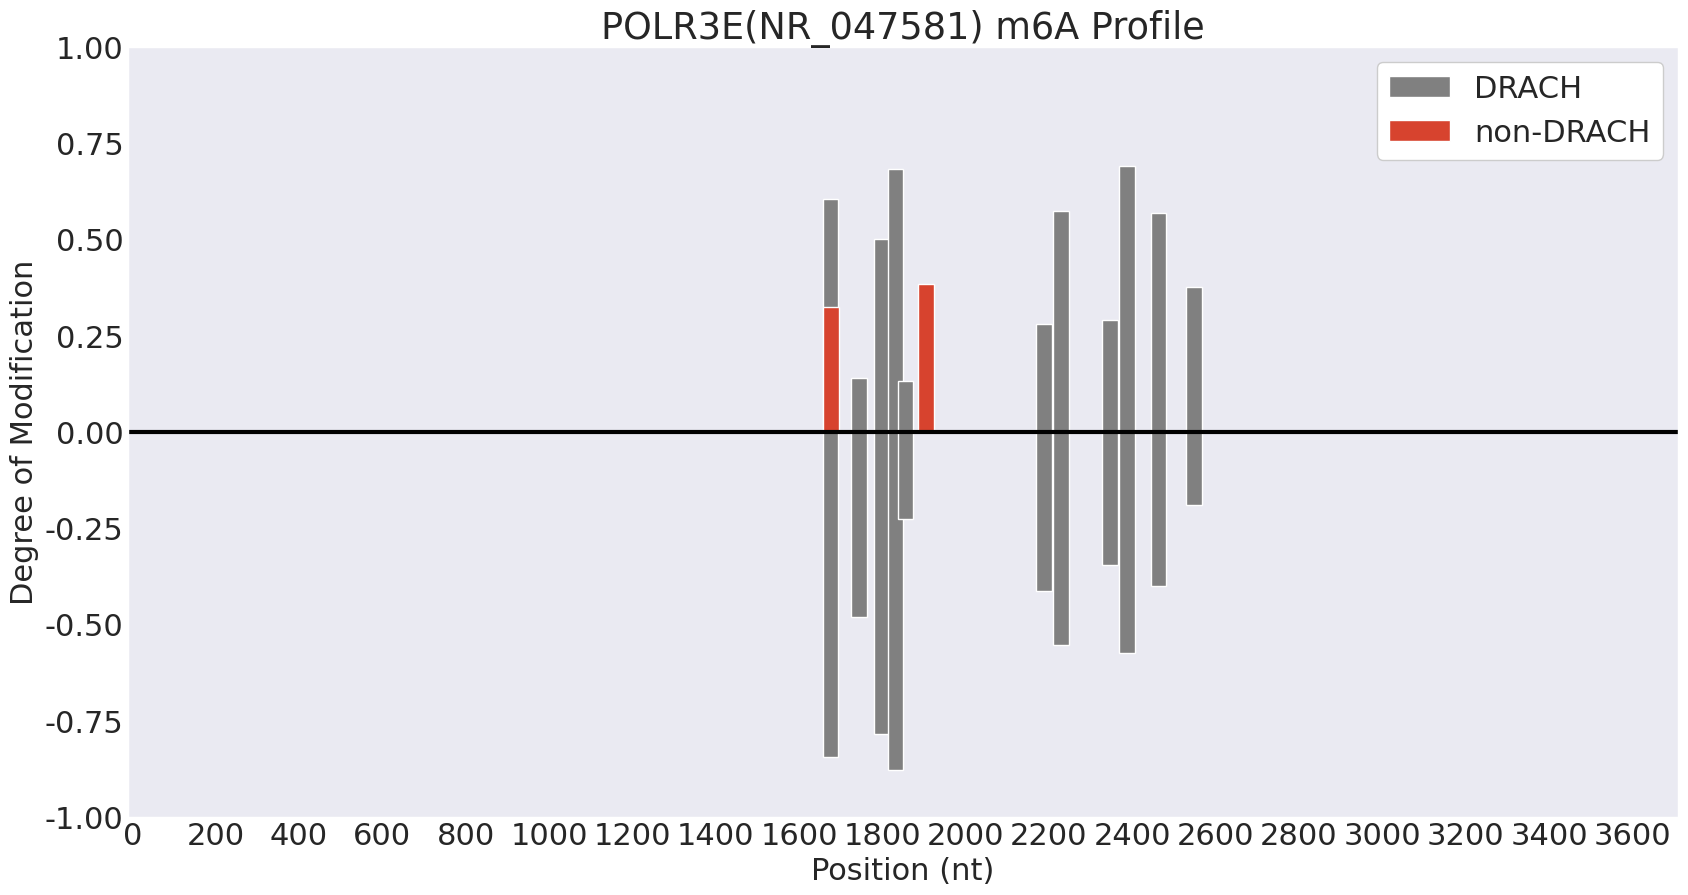

NR_126045


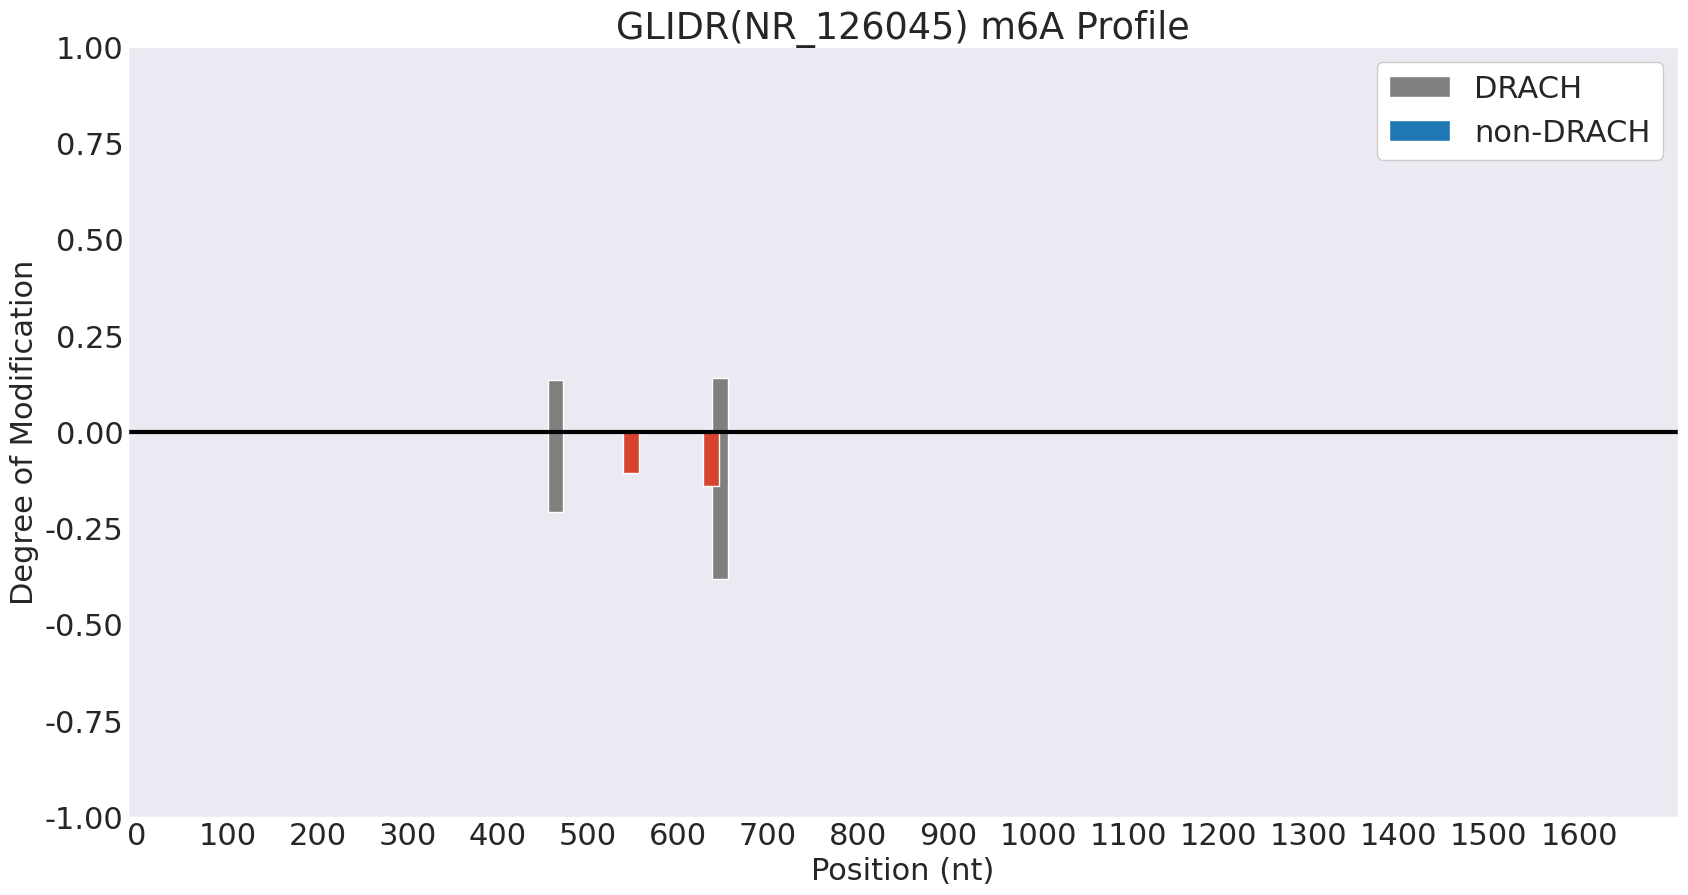

NR_126432


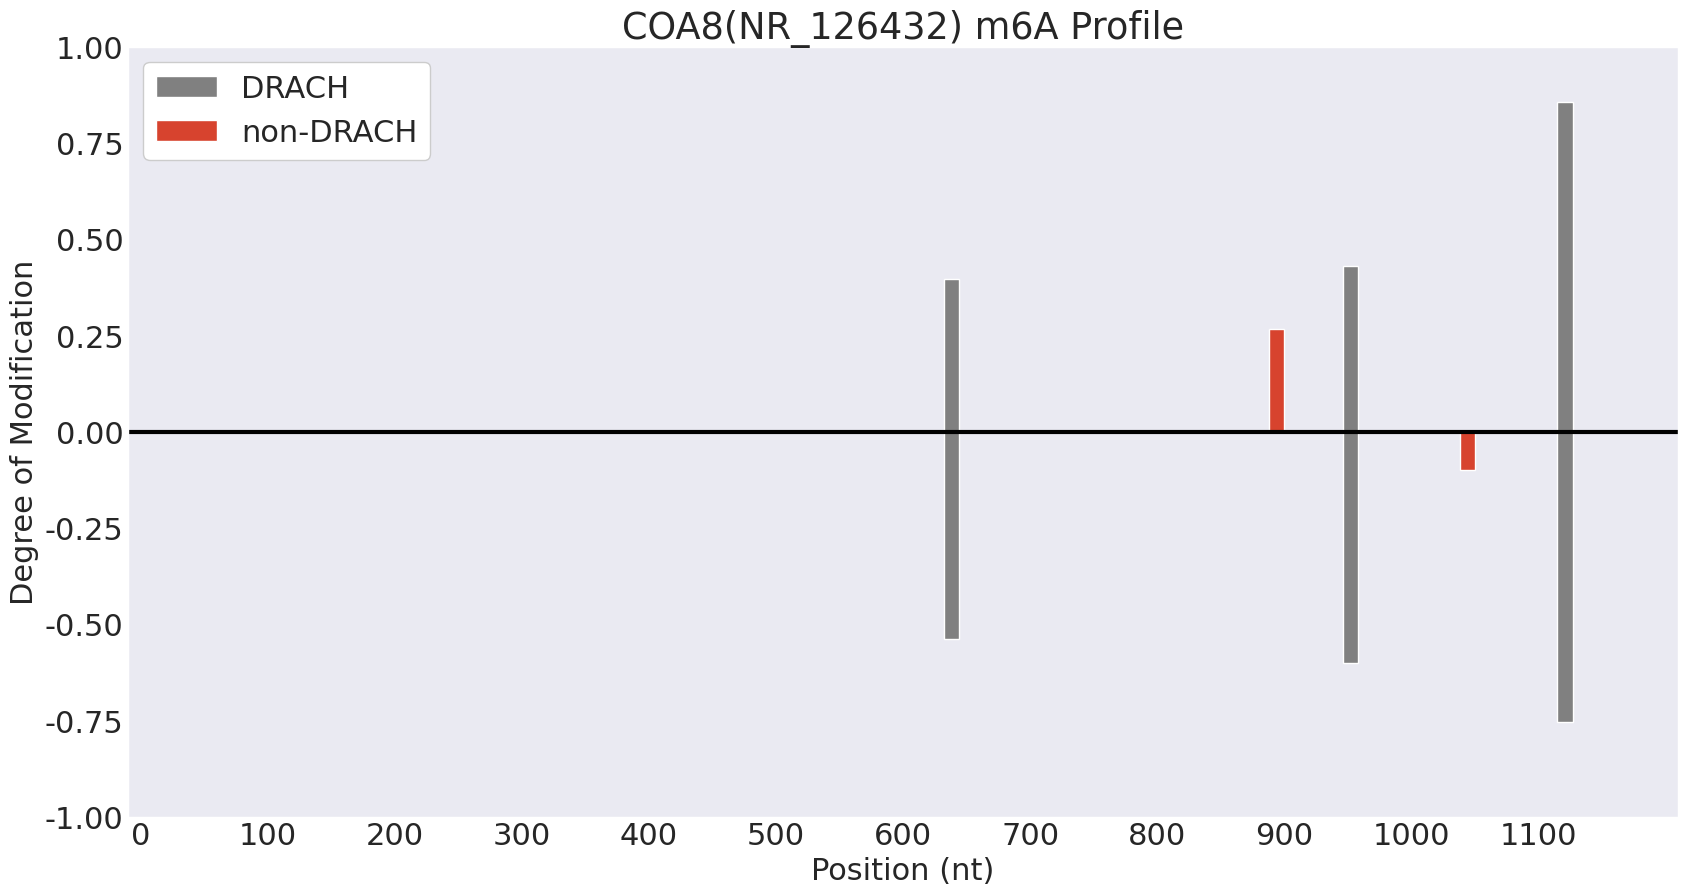

In [109]:
for refseq in selected_nmids["refseq"]:
    plot(refseq, colour="drach")

NM_001017969


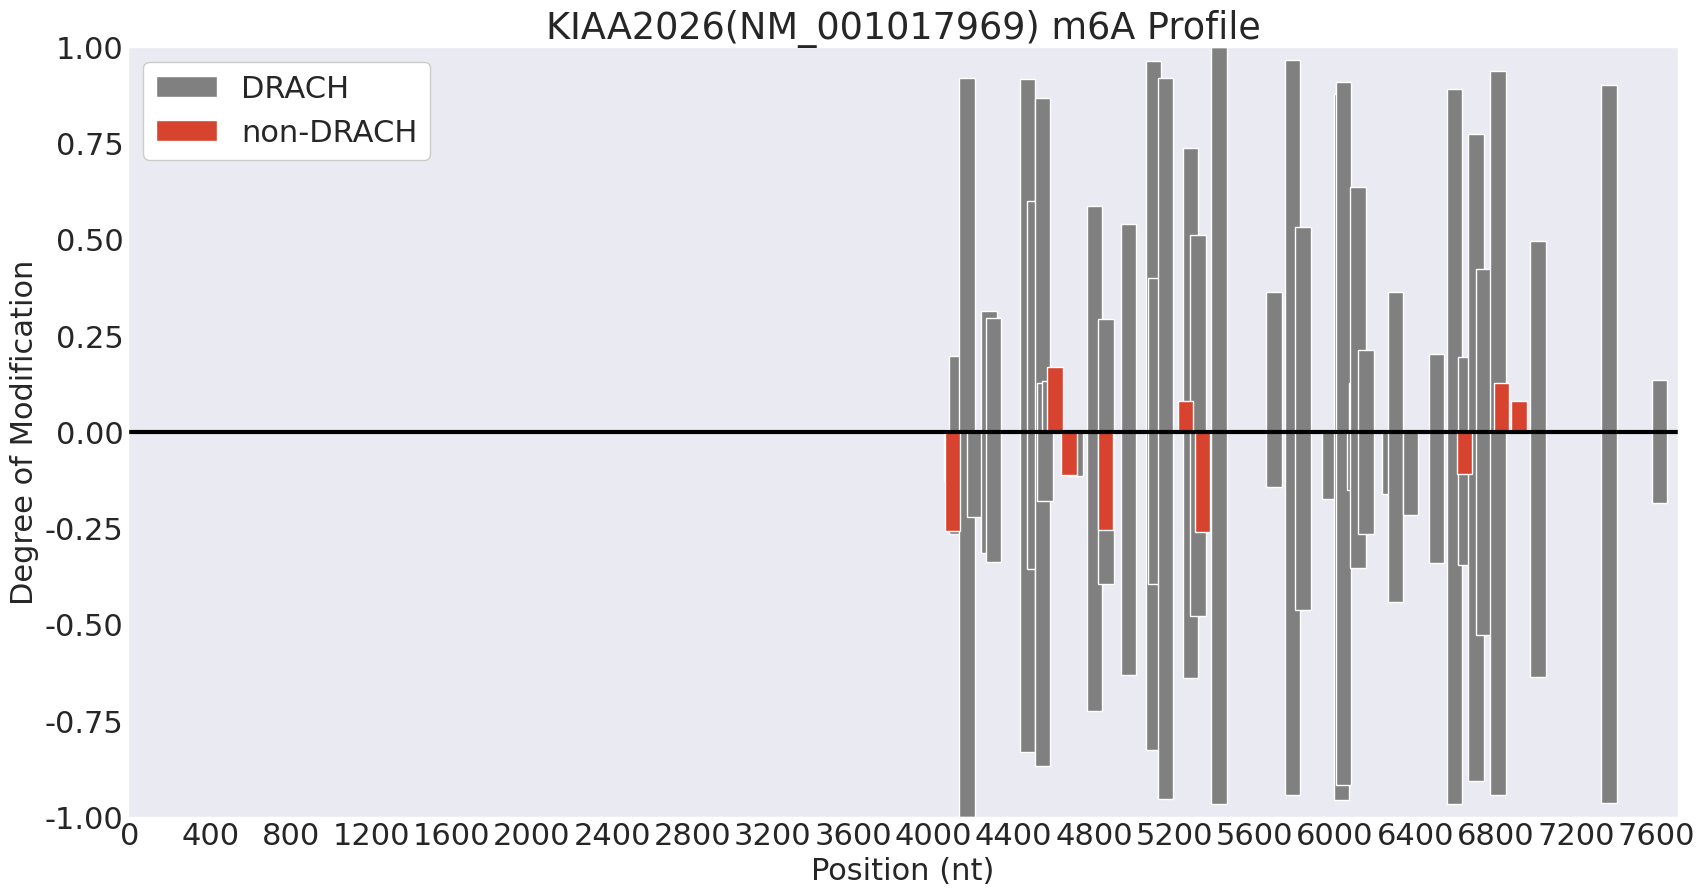

NM_001161546


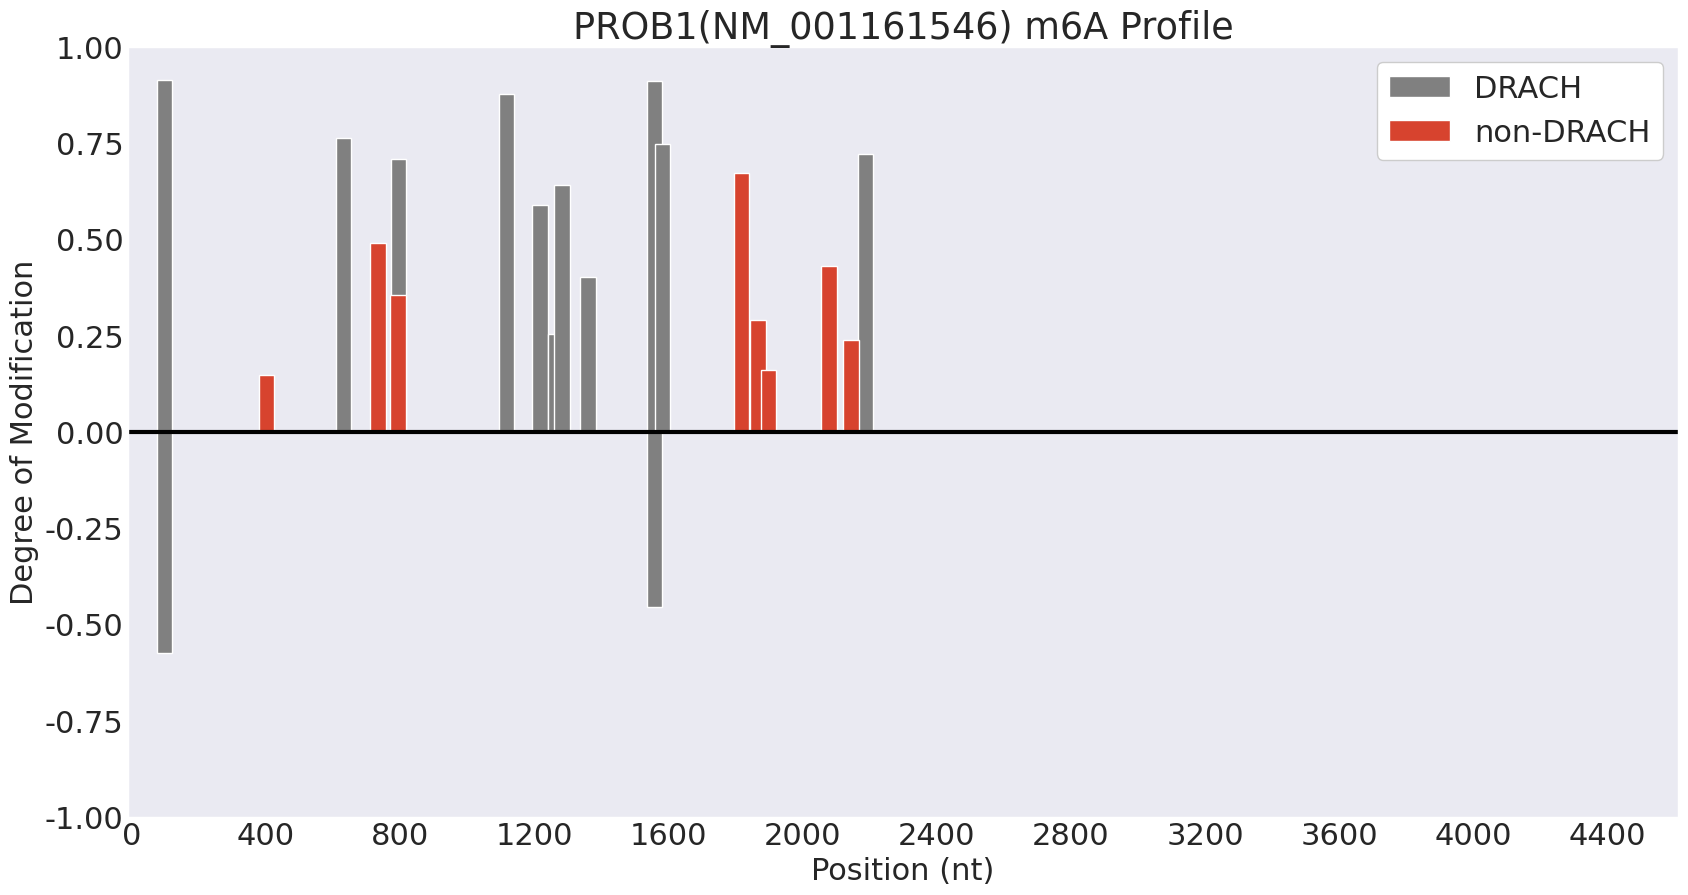

NM_001267783


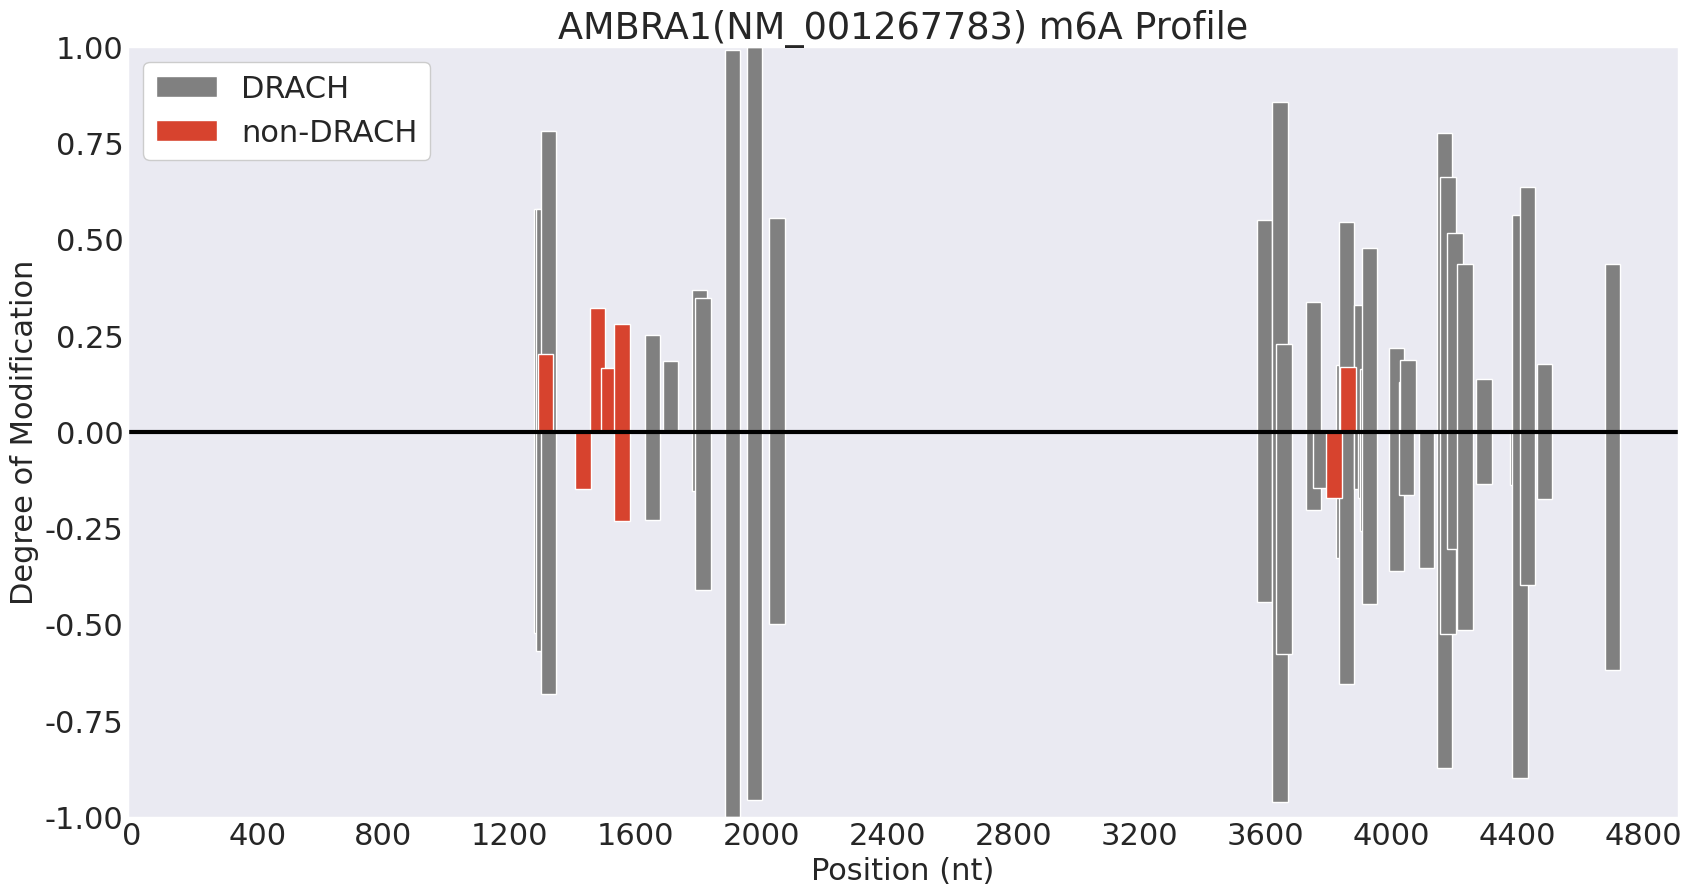

NM_001282858


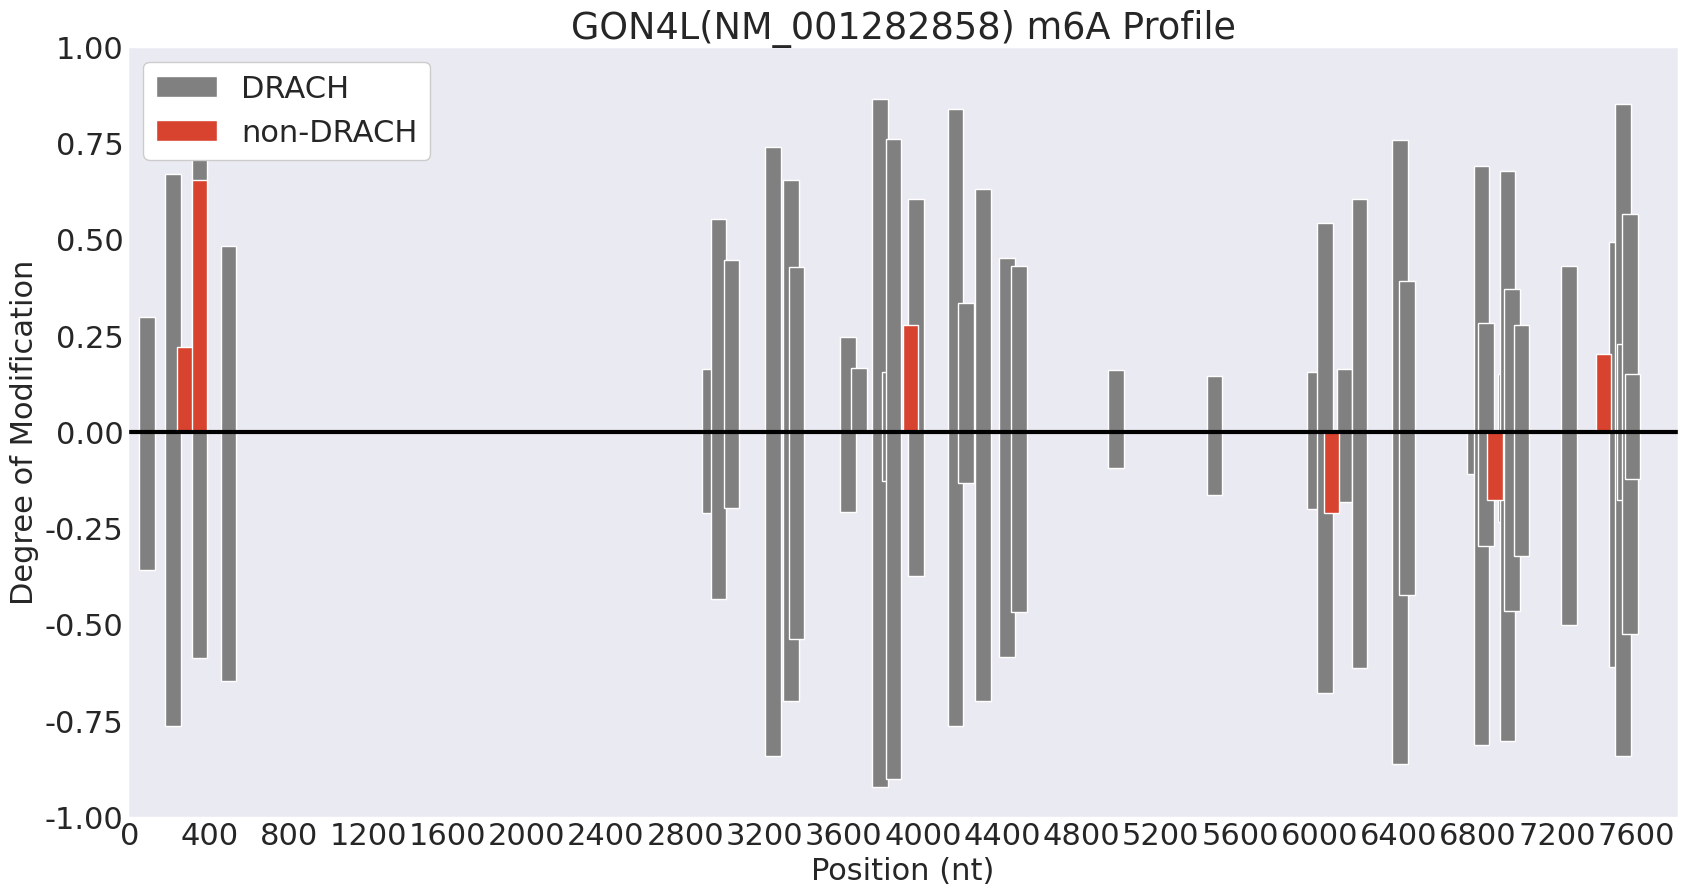

NM_001330682


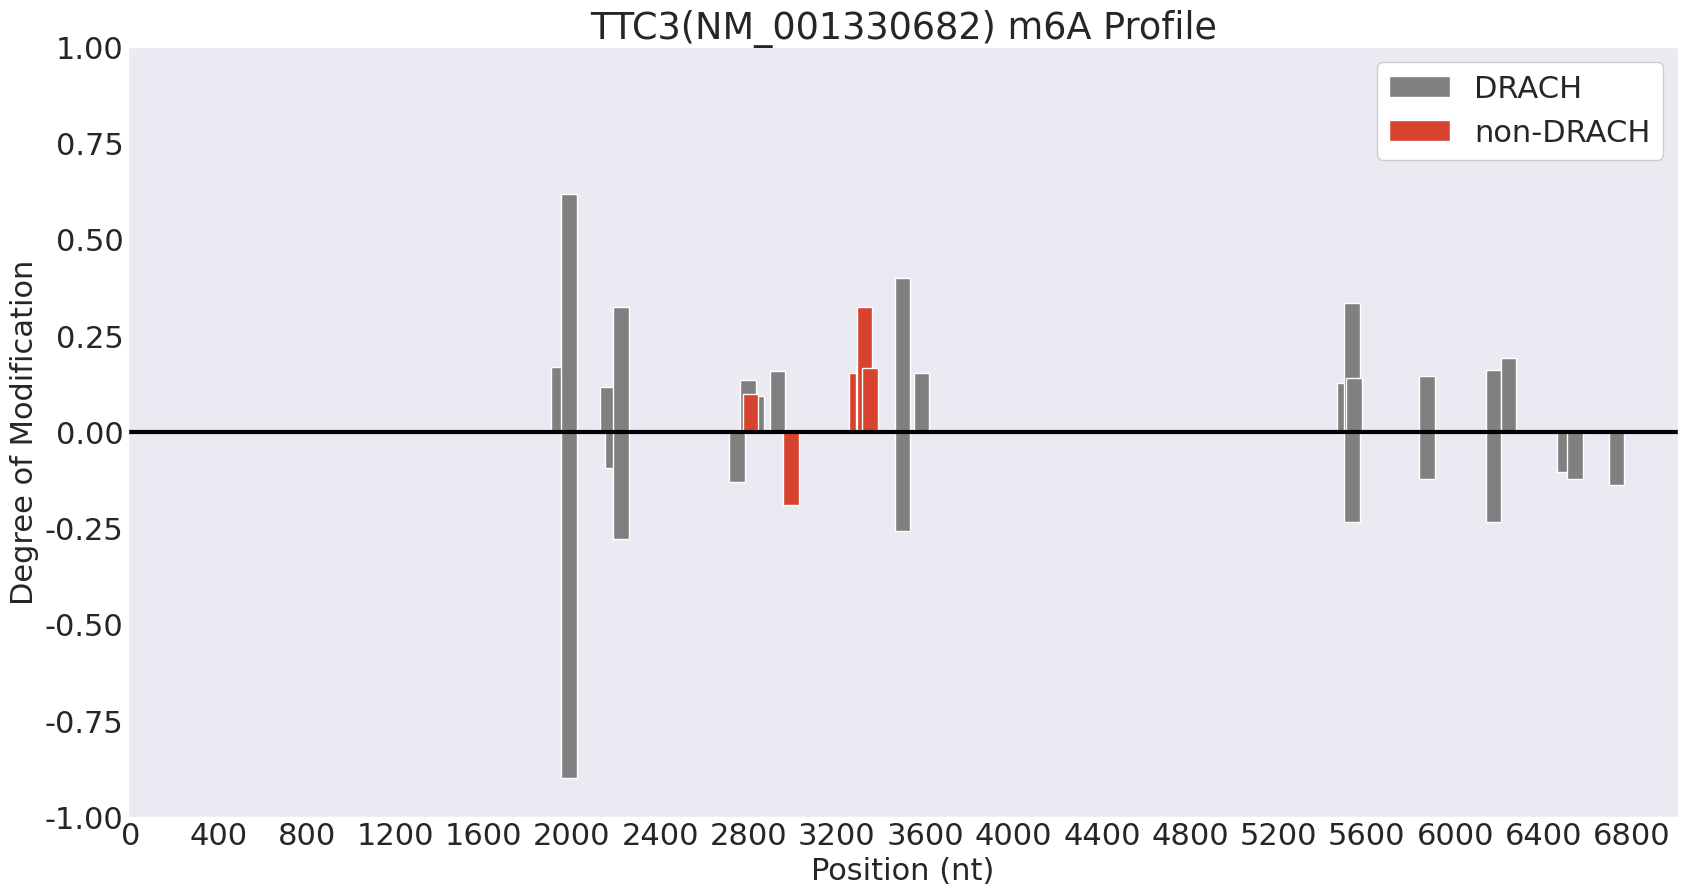

NM_001396518


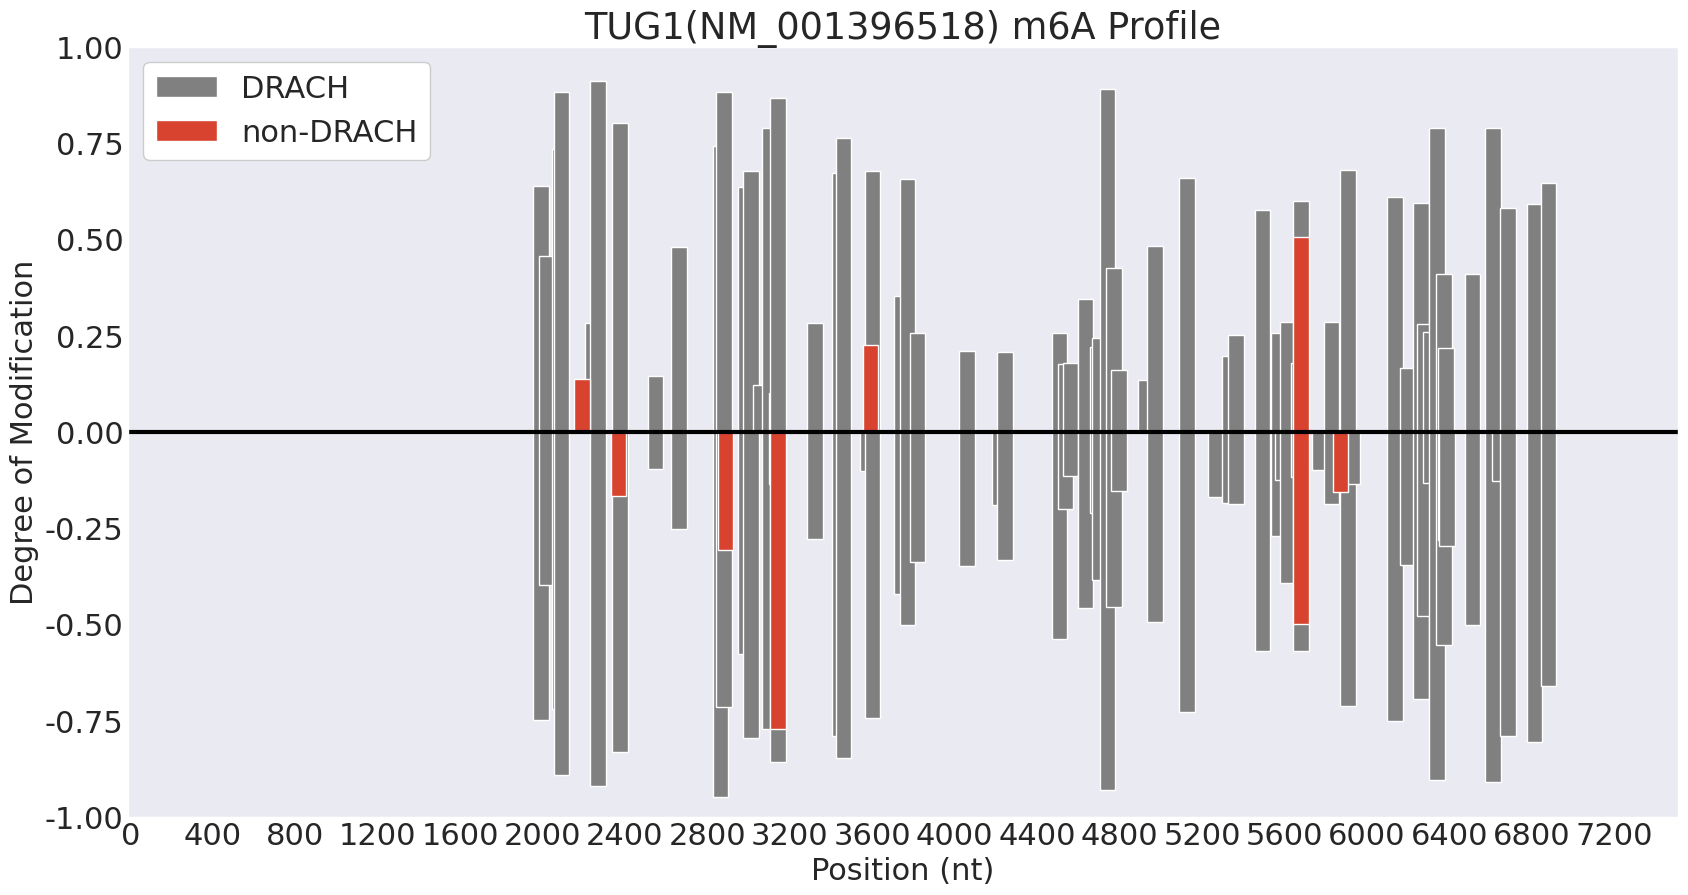

NM_001992


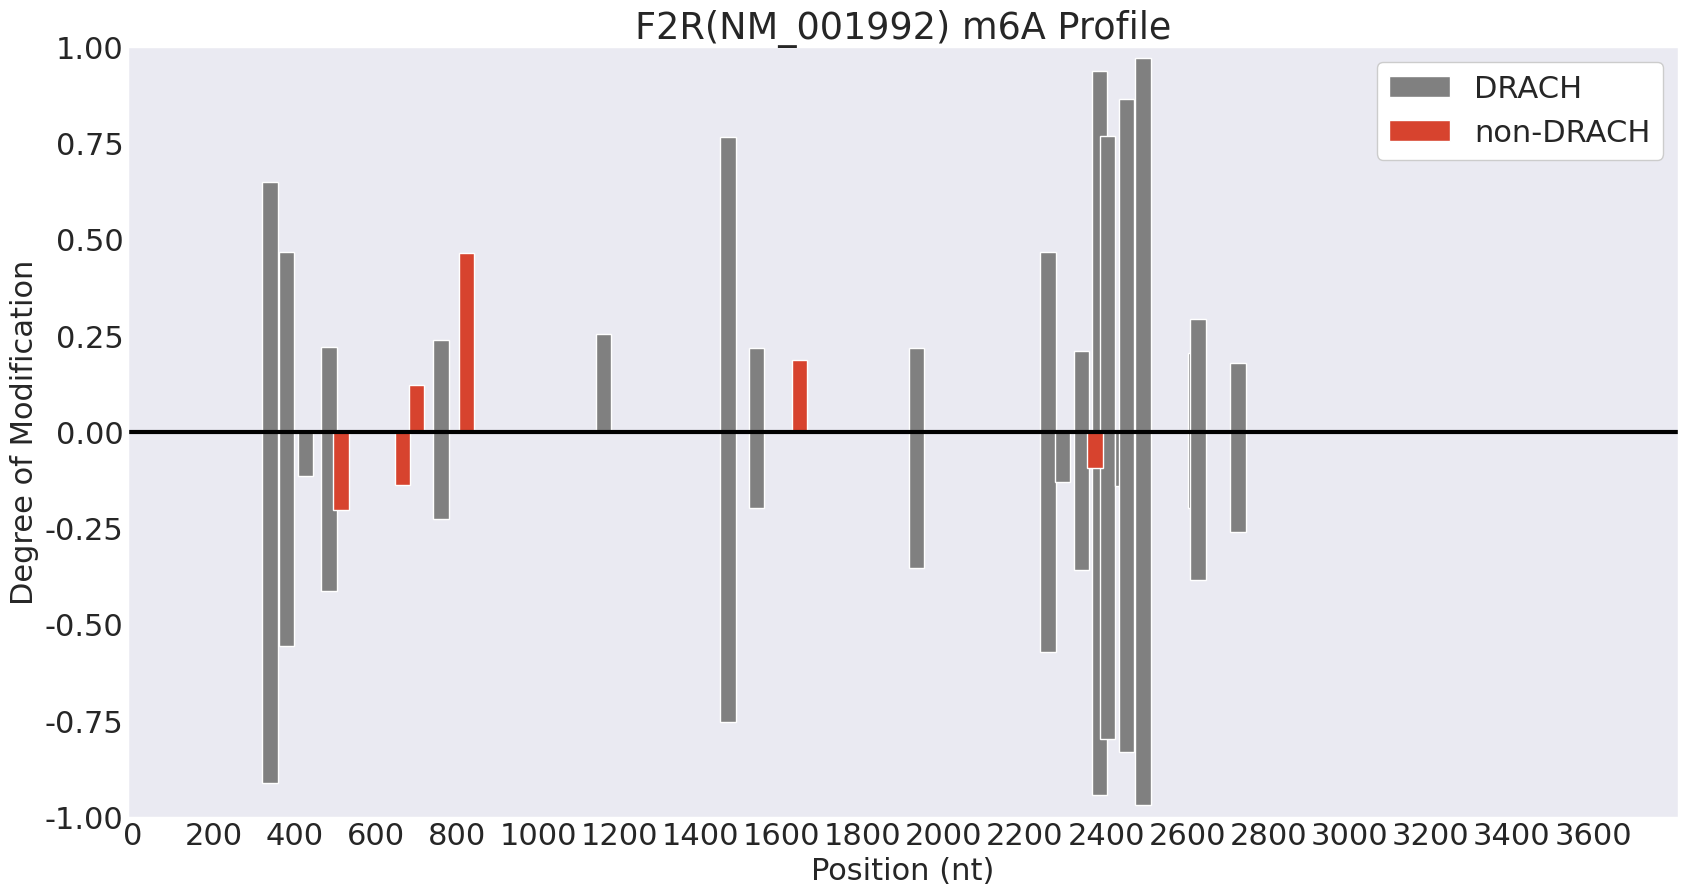

NM_003440


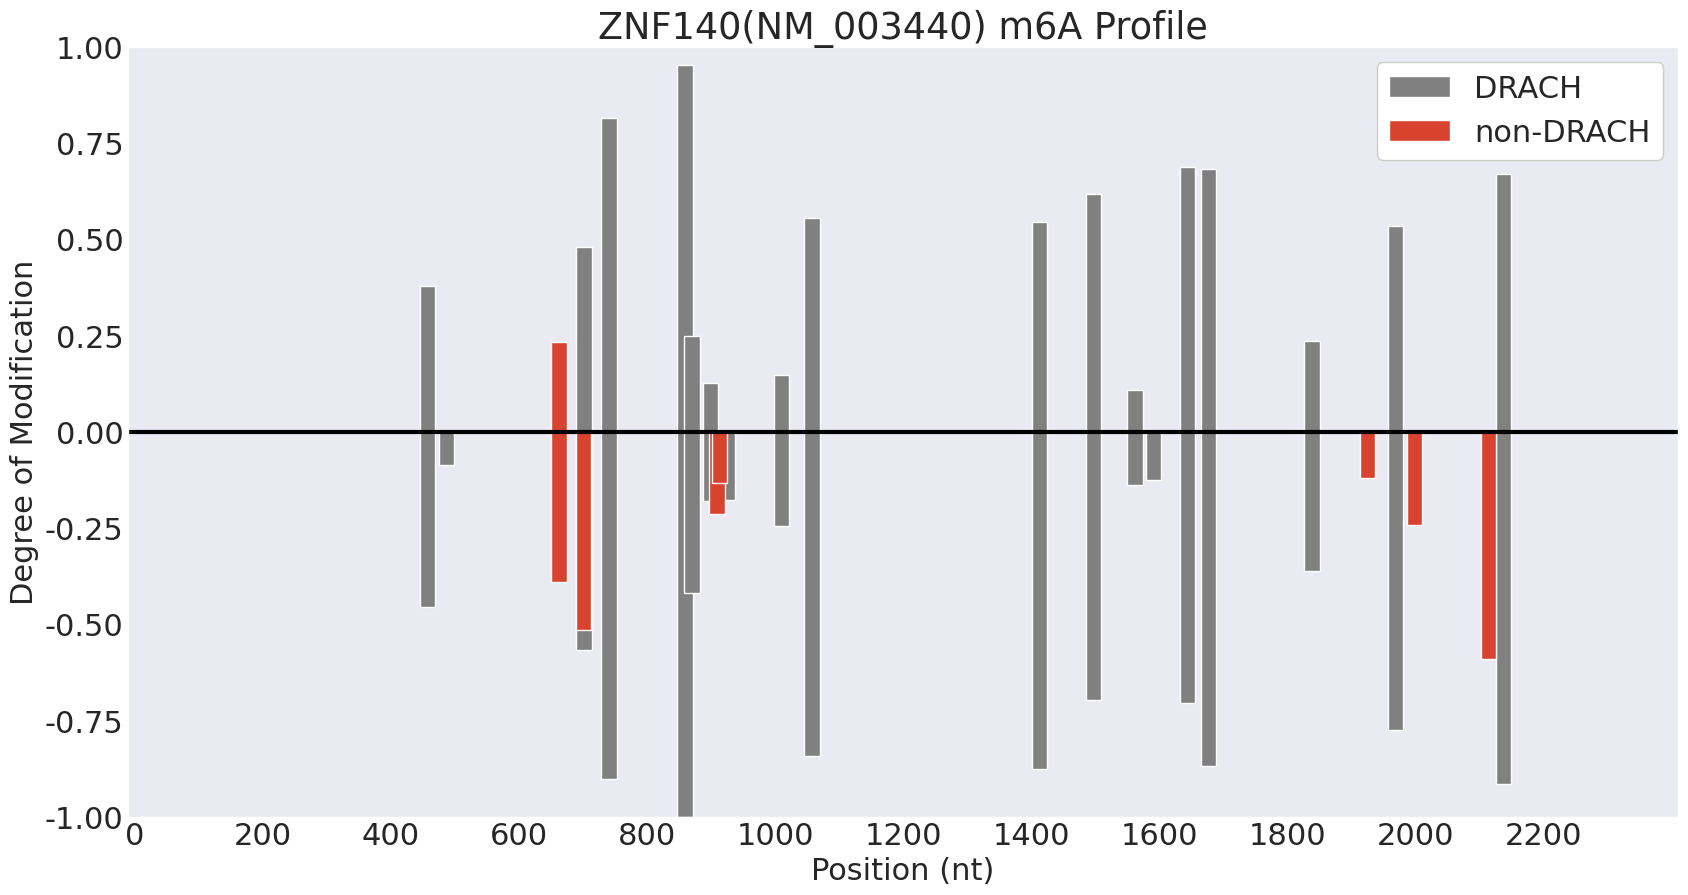

NM_003489


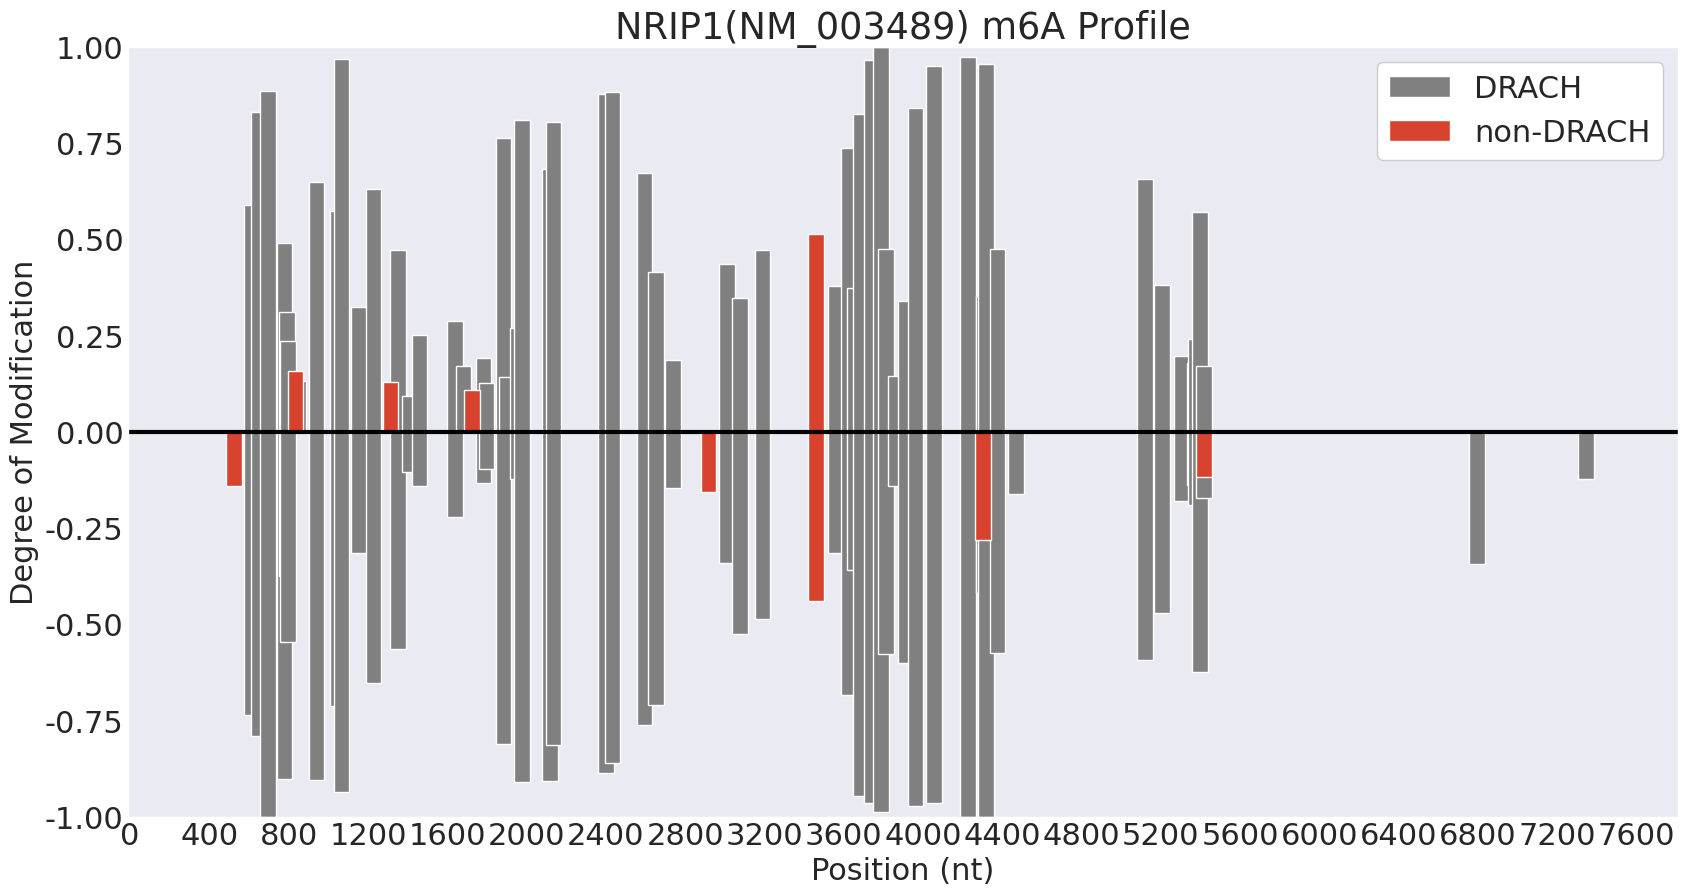

NM_014741


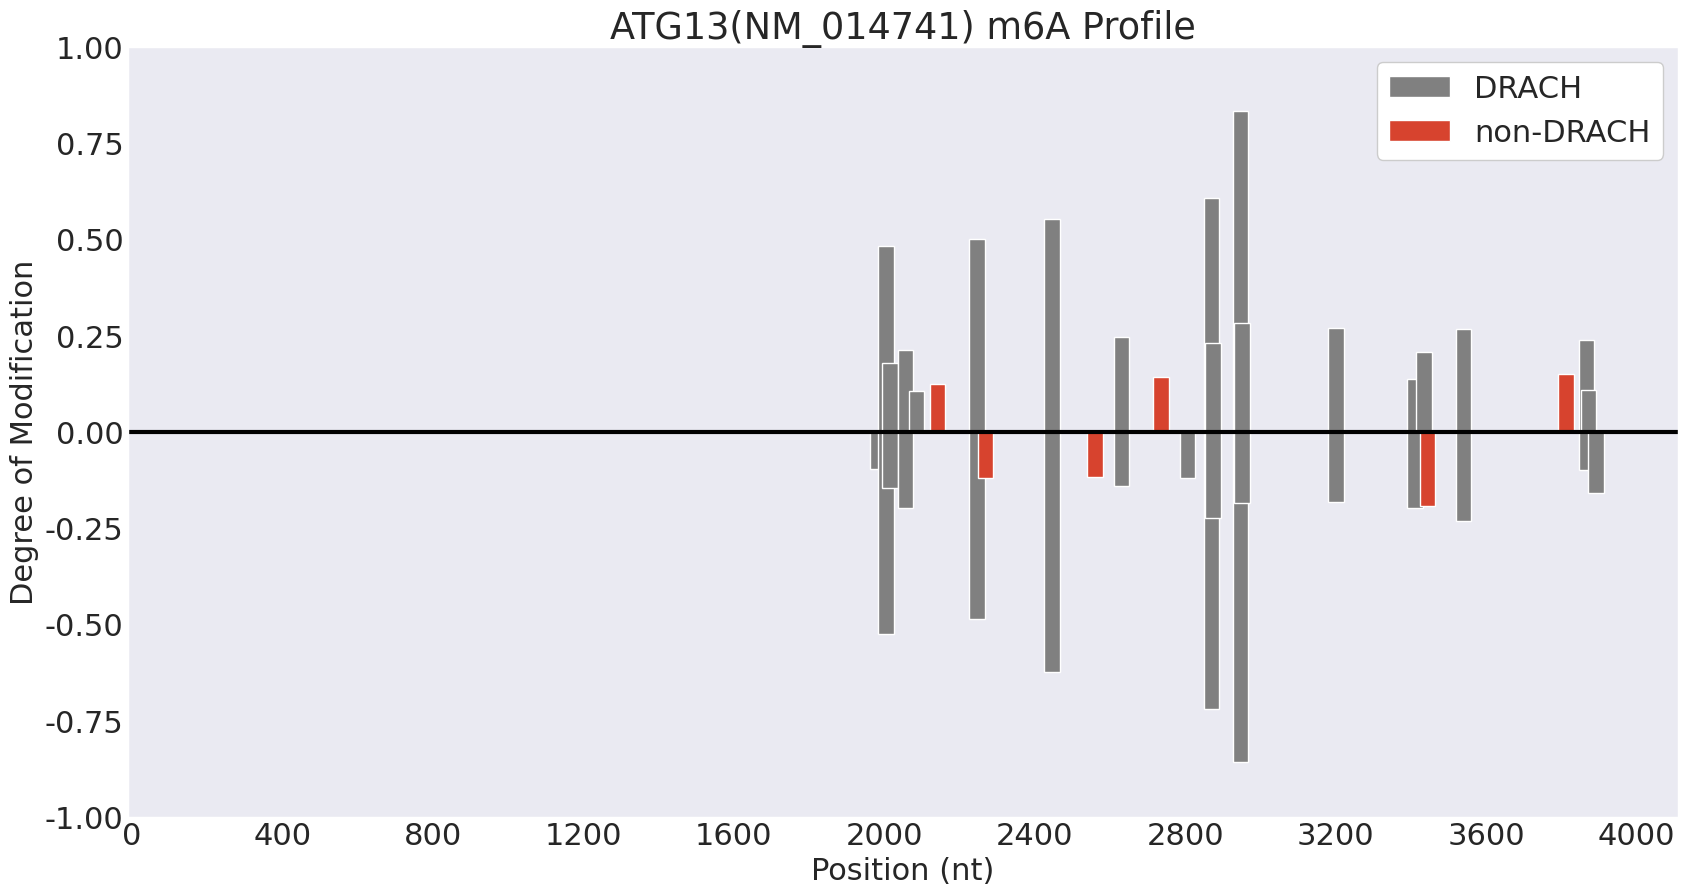

NM_015482


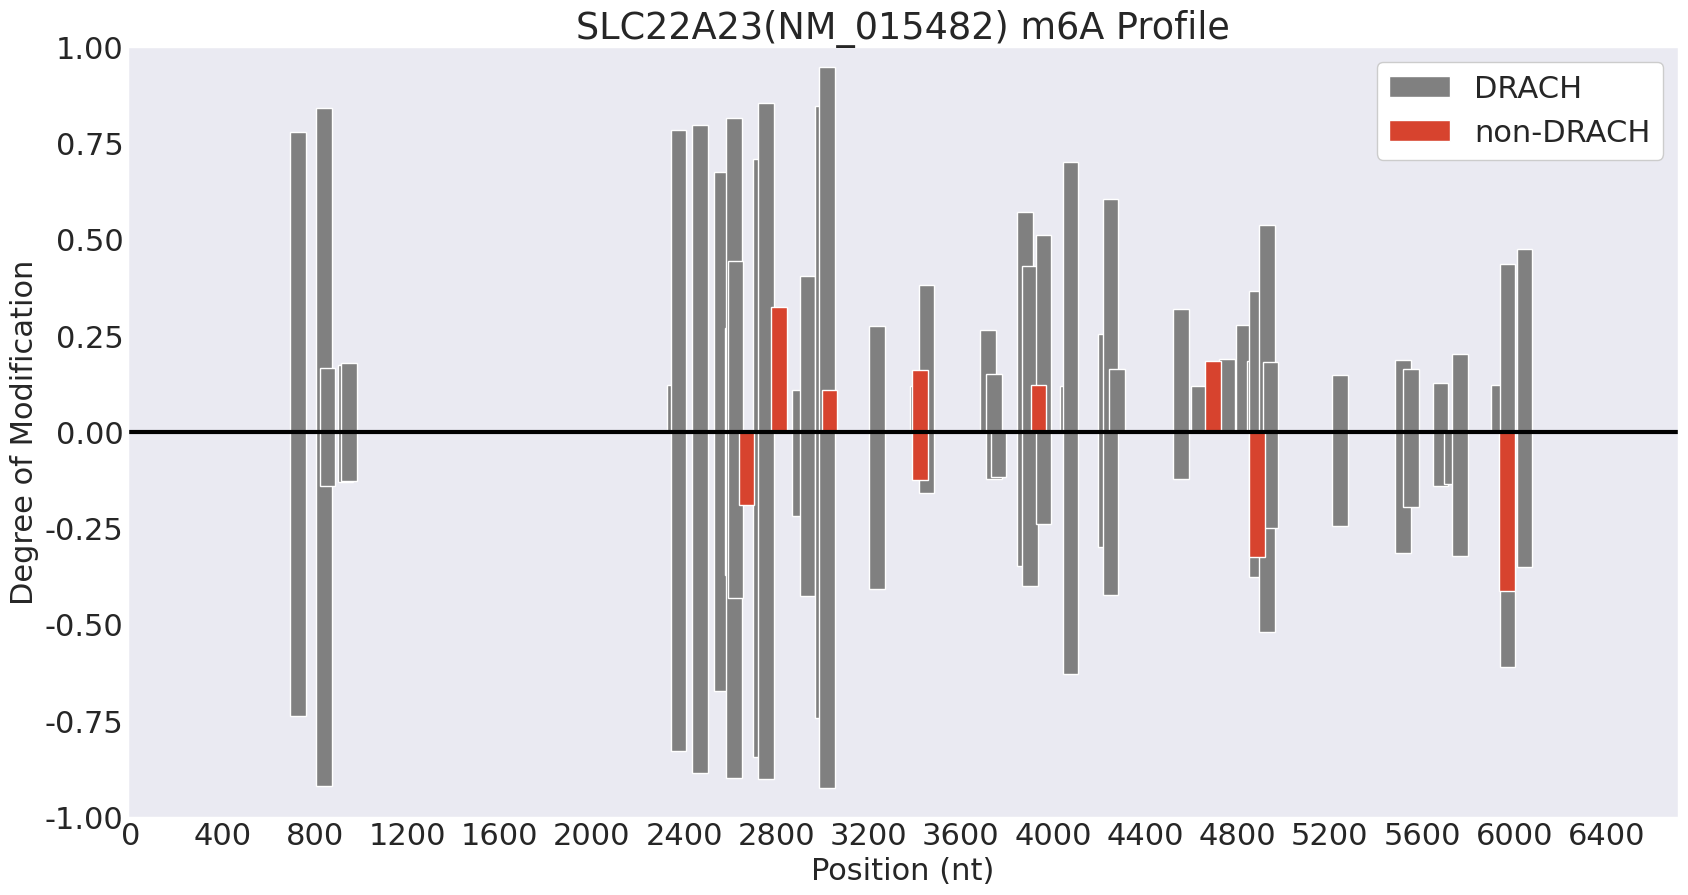

NM_024639


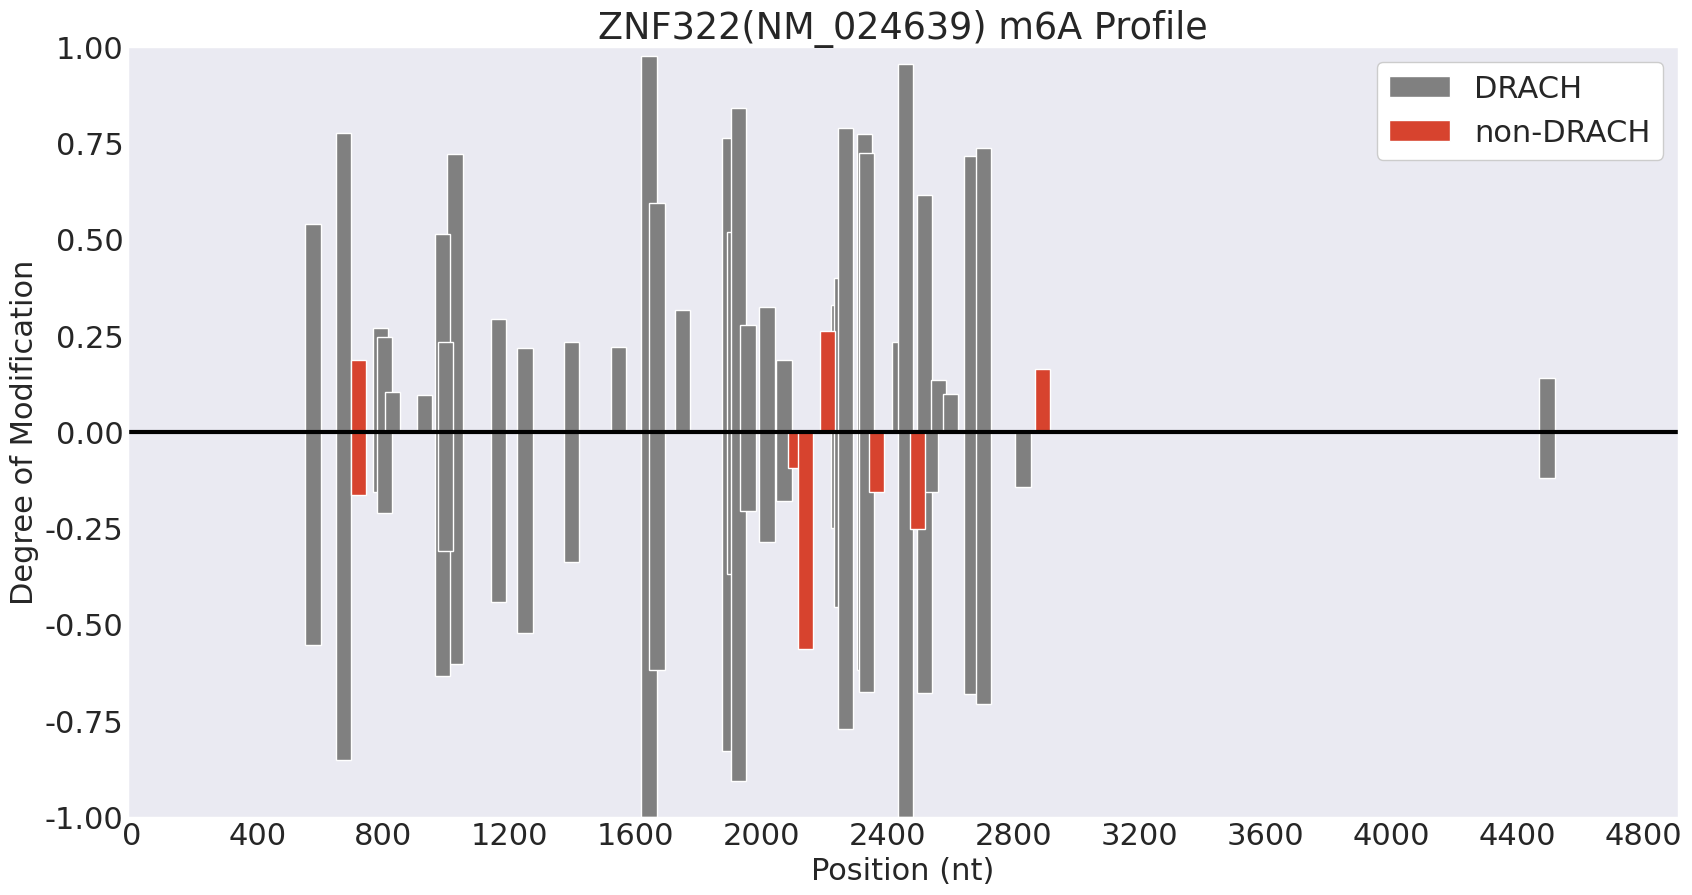

NM_032812


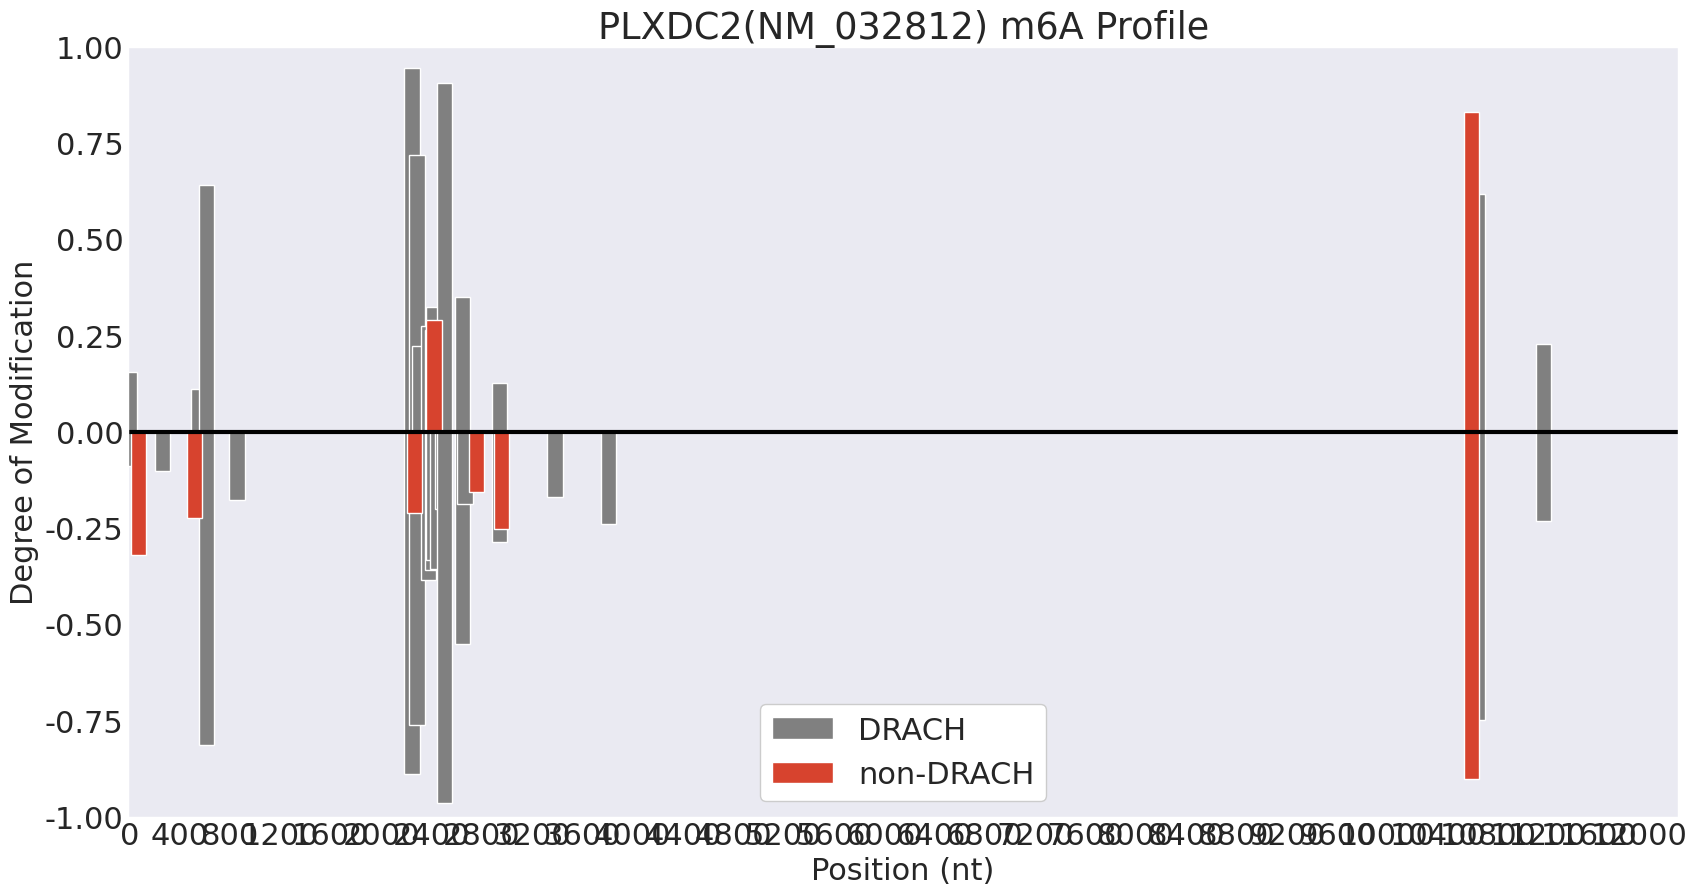

In [106]:
selected_nmids = diff_df[(diff_df["nondrach_unique"] > 5) & (diff_df["nondrach_common"] < 2)]
for refseq in selected_nmids["refseq"]:
    plot(refseq, colour="drach")

In [75]:
diff_df = diff_df.sort_values("l2", ascending=False)
select_df = diff_df[(diff_df[["hela_size","hek_size"]].max(axis=1) >= 3) & (diff_df["l2"] > 0.4) & (diff_df["refseq"].str.startswith("NM"))]
print(select_df)

             refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
3832   NM_001282334    0.000000      40.464515          6         0  0.000000   
3374   NM_001258328    0.000000      36.389068          4         0  0.000000   
3341   NM_001257330    0.265323       1.142768          1         3  0.333333   
2225   NM_001161546    0.478922       0.920953          2        19  0.105263   
5213   NM_001321232    0.000000      34.764441          6         0  0.000000   
14454     NM_152421    0.000000       0.805262          0         3  0.000000   
3820   NM_001282285    0.106465      23.792699          3         1  0.333333   
7188   NM_001388394    0.737681      21.312961          3         2  0.666667   
6359   NM_001365004    0.579724      29.527427          3         1  0.333333   
10247     NM_012292    0.352822      30.358517          8         1  0.125000   
6823   NM_001376057    0.163809      24.385003          3         1  0.333333   
10306     NM_012446    0.525

In [76]:
weak_mod = diff_df[diff_df[["hela_size","hek_size"]].max(axis=1) < 5]
moderate_mod = diff_df[(diff_df[["hela_size","hek_size"]].max(axis=1) >= 5)&(diff_df[["hela_size","hek_size"]].max(axis=1) <= 20)]
strong_mod = diff_df[diff_df[["hela_size","hek_size"]].max(axis=1) > 20]
print(np.sum(weak_mod["unique"] > 0) , len(weak_mod))
print(np.sum(moderate_mod["unique"] > 0) , len(moderate_mod))
print(np.sum(strong_mod["unique"] > 0) , len(strong_mod))

4385 7781
6562 7442
1533 1550


In [77]:
for i in range(len(select_df)):
    plot(select_df.iloc[i]["refseq"])

NameError: name 'plot' is not defined

In [78]:
diff_df["nonunique"] = (diff_df["hela_size"]+diff_df["hek_size"]-diff_df["unique"])//2
print(diff_df)

             refseq  cosine_sim  cross_entropy  hela_size  hek_size  iou  \
14265     NM_145080         0.0      58.914757          1         0  0.0   
16167     NR_104049         0.0      55.262042          1         0  0.0   
16162     NR_104015         0.0      54.612595          2         0  0.0   
7168   NM_001387999         0.0       1.540445          0         1  0.0   
8412      NM_003370         0.0      40.504243          2         0  0.0   
...             ...         ...            ...        ...       ...  ...   
15186     NM_198830         1.0       0.645390          1         1  1.0   
694       NM_001019         1.0       0.692509          1         1  1.0   
656    NM_001017928         1.0       0.566653          1         1  1.0   
2344   NM_001166135         1.0       0.617242          1         1  1.0   
12185     NM_019103         1.0       0.585953          1         1  1.0   

       unique            l1            l2  nonunique  
14265       1  8.528785e-01  8.5

In [83]:
weak_mod = diff_df[diff_df[["hela_size","hek_size"]].max(axis=1) < 5]
moderate_mod = diff_df[(diff_df[["hela_size","hek_size"]].max(axis=1) >= 5)&(diff_df[["hela_size","hek_size"]].max(axis=1) <= 10)]
strong_mod = diff_df[diff_df[["hela_size","hek_size"]].max(axis=1) > 10]
print(np.sum(weak_mod["unique"]) / (np.sum(weak_mod["nonunique"])+np.sum(weak_mod["unique"])))
print(np.sum(moderate_mod["unique"]) / (np.sum(moderate_mod["nonunique"])+np.sum(moderate_mod["unique"])))
print(np.sum(strong_mod["unique"]) / (np.sum(strong_mod["nonunique"]) + np.sum(strong_mod["unique"])))

0.34929718317684316
0.2610744022045098
0.216102541455054


In [95]:
print(weak_mod[(weak_mod["unique"]>2) & (weak_mod["cosine_sim"] < 0.3) & (weak_mod["cosine_sim"] > 0)])

             refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
2264   NM_001164095    0.200781       2.412928          2         3  0.250000   
7550   NM_001411044    0.224358      12.977060          3         3  0.200000   
7078   NM_001384981    0.273555      12.872143          3         2  0.250000   
15373     NM_206873    0.102012       4.078553          2         3  0.250000   
12086     NM_018677    0.159899       9.494636          2         3  0.250000   
11510     NM_016602    0.288551      16.471283          4         1  0.250000   
5734   NM_001346409    0.228745       6.780876          2         4  0.200000   
4935   NM_001318249    0.236573       9.860718          3         2  0.250000   
15740     NR_033149    0.097248       6.464302          4         4  0.142857   
5225   NM_001321324    0.253689       4.562370          4         3  0.166667   
13923     NM_080684    0.189062       8.381987          3         2  0.250000   
14670     NM_173348    0.295

In [ ]:
selected_refseq = weak_mod[(weak_mod["unique"]>2) & (weak_mod["cosine_sim"] < 0.3) & (weak_mod["cosine_sim"] > 0)]["refseq"]
for refseq in selected_refseq:
    plot(refseq)

In [100]:
print(strong_mod[(strong_mod["unique"]>3) & (strong_mod["cosine_sim"] < 0.7) & (strong_mod["cosine_sim"] > 0)])

             refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
16512     NR_145819    0.674489      13.660380         13        13  0.444444   
2225   NM_001161546    0.478922       0.920953          2        19  0.105263   
8796      NM_004289    0.607129       0.667221          4        25  0.160000   
16429     NR_135765    0.689525      11.005163         16        10  0.368421   
10886     NM_015099    0.543378      12.583673         11         2  0.181818   
15041     NM_183380    0.647368       5.156864         11        10  0.312500   
15026     NM_183006    0.695645       1.241445          6        12  0.384615   
9612      NM_006154    0.627250       6.159492         13         7  0.250000   

       unique        l1        l2  nonunique  
16512      10  0.447056  0.589365          8  
2225       17  0.507122  0.547969          2  
8796       21  0.378882  0.440927          4  
16429      12  0.321620  0.359572          7  
10886       9  0.217382  0.255972  

NR_145819


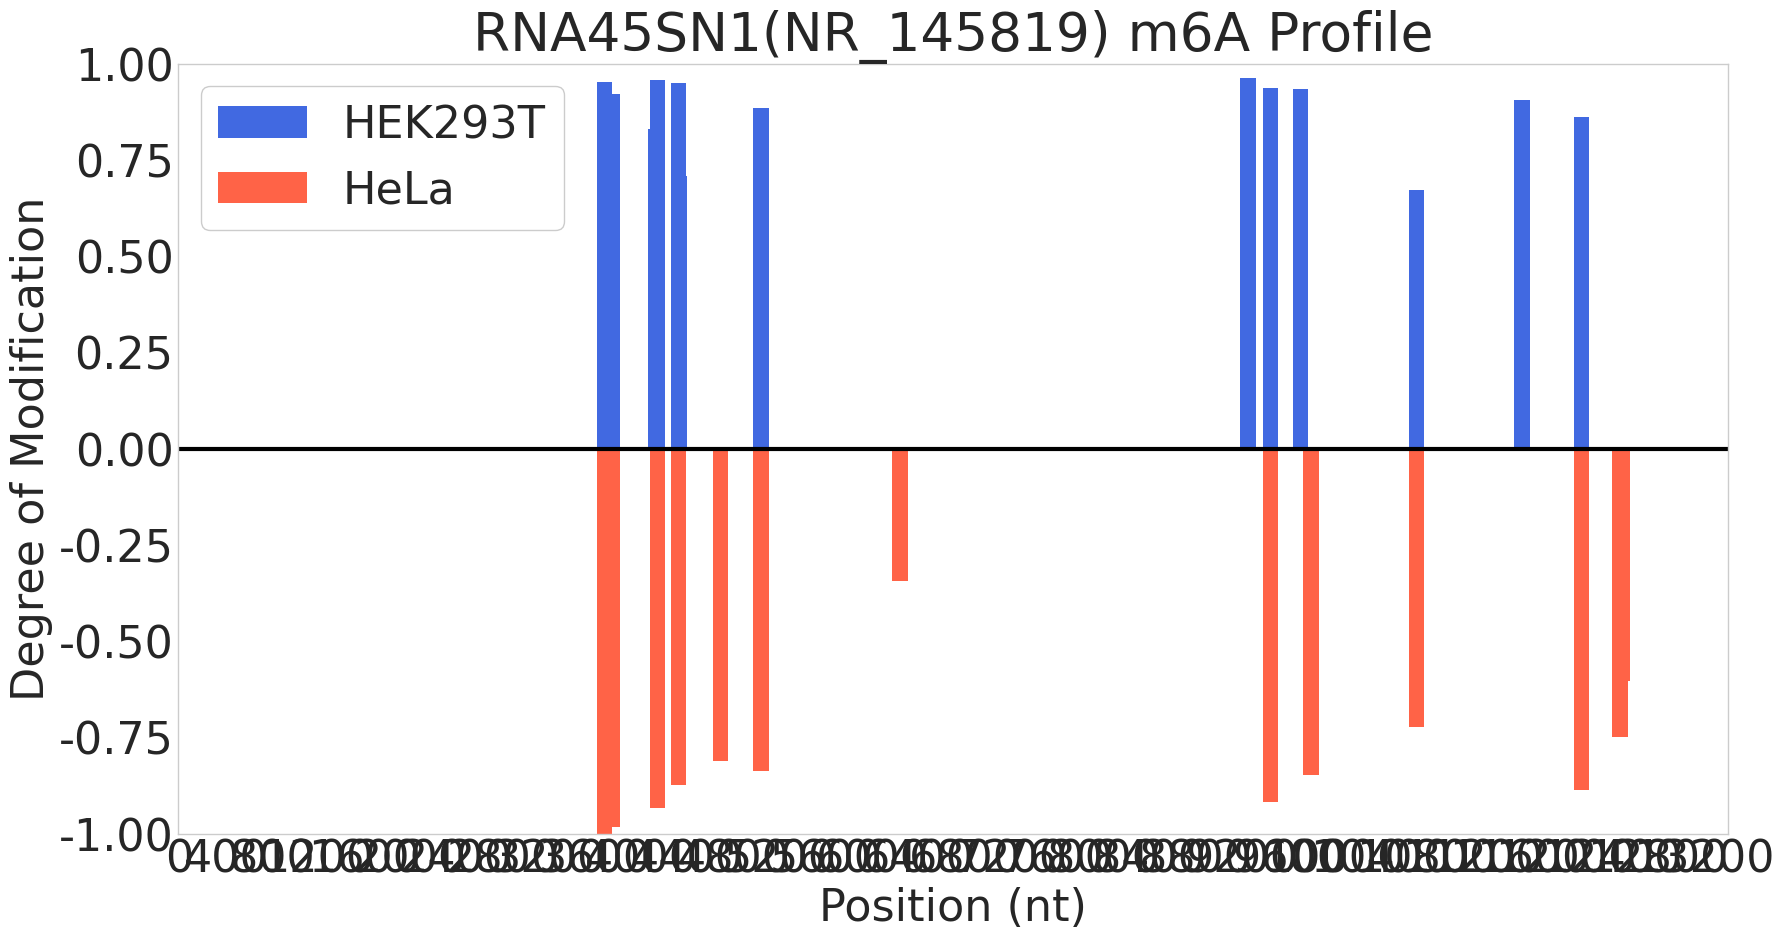

NM_001161546


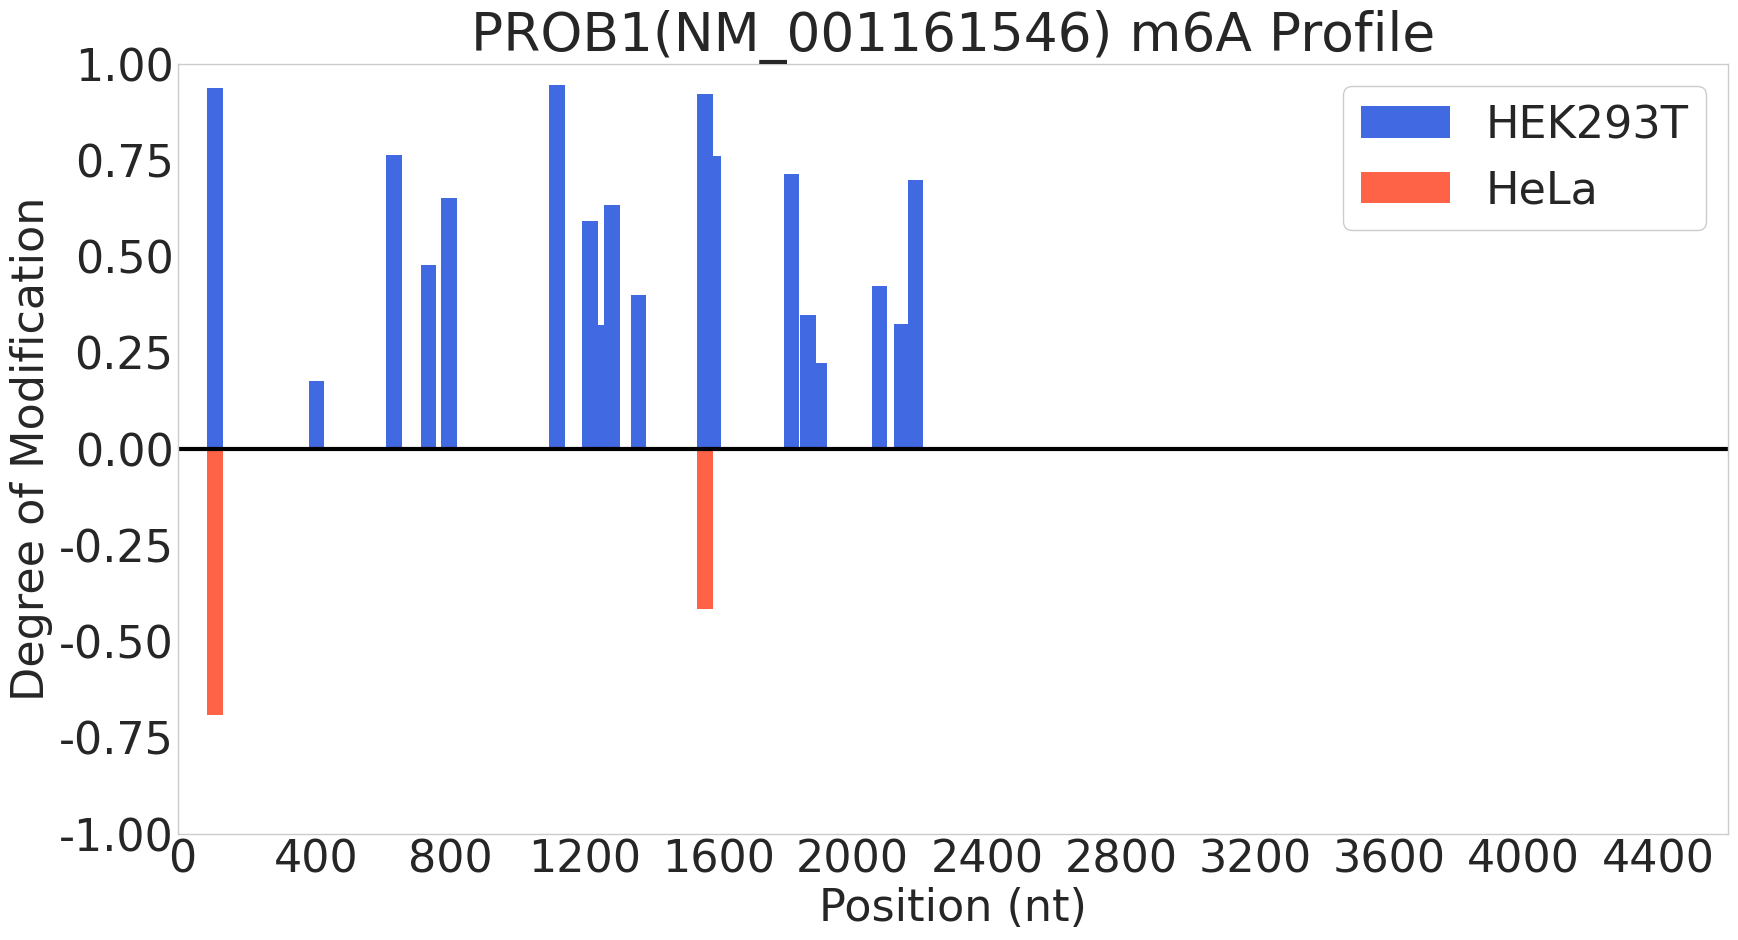

NM_004289


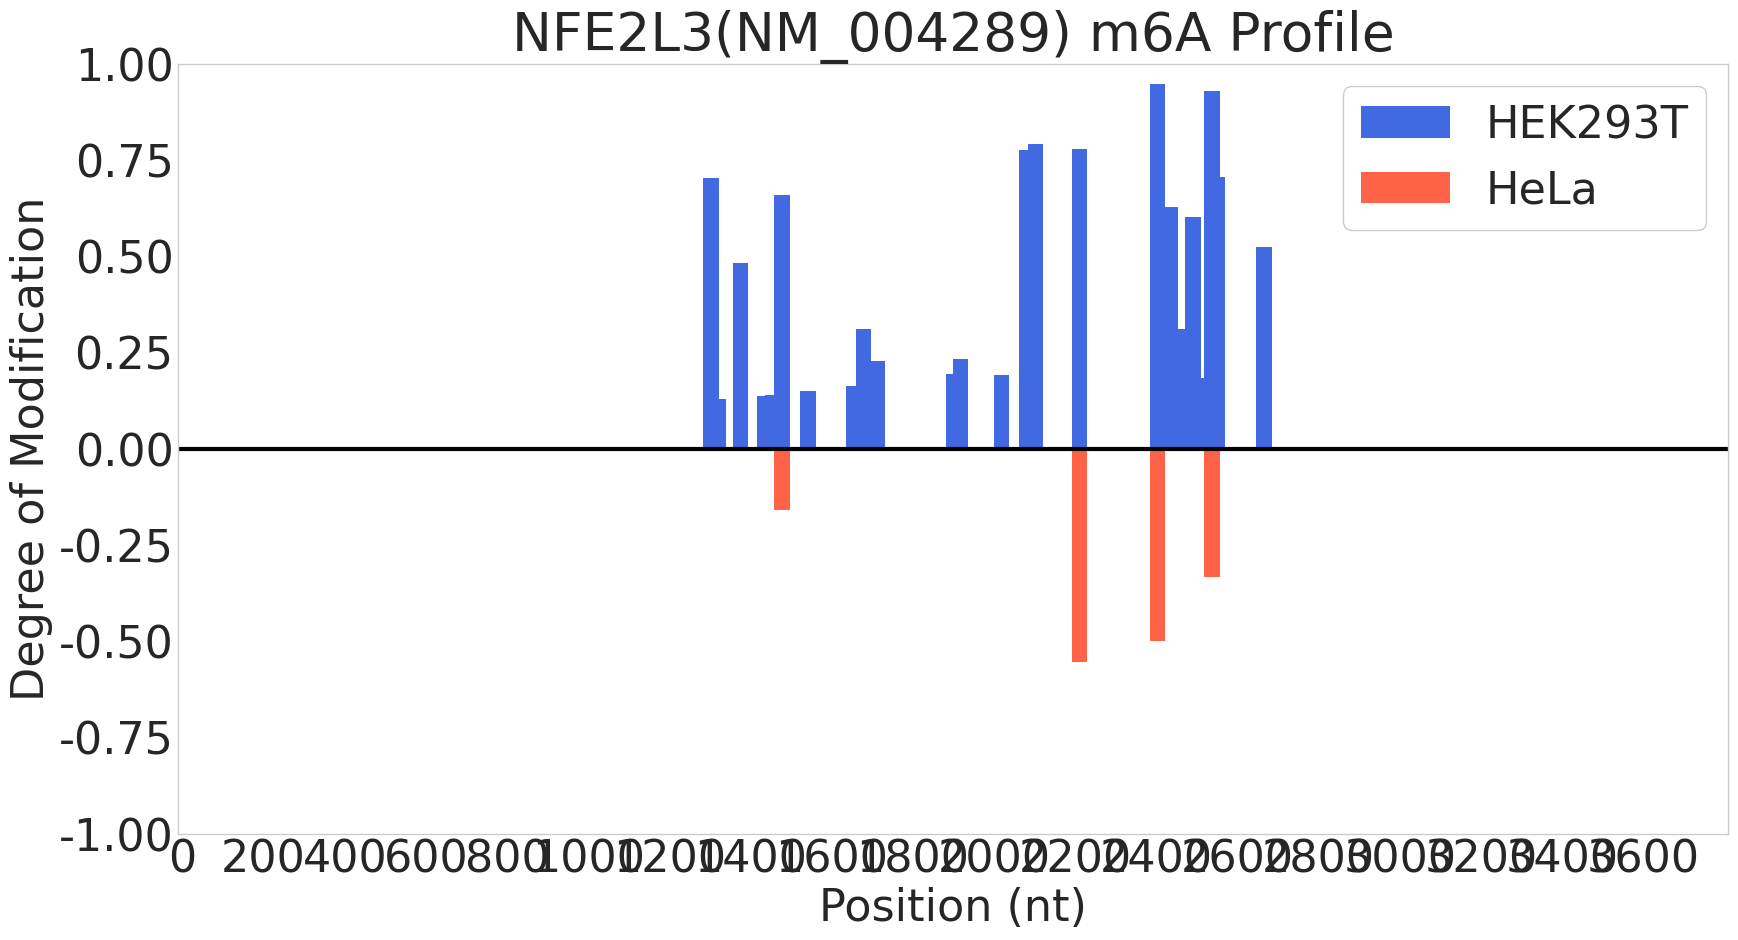

NR_135765


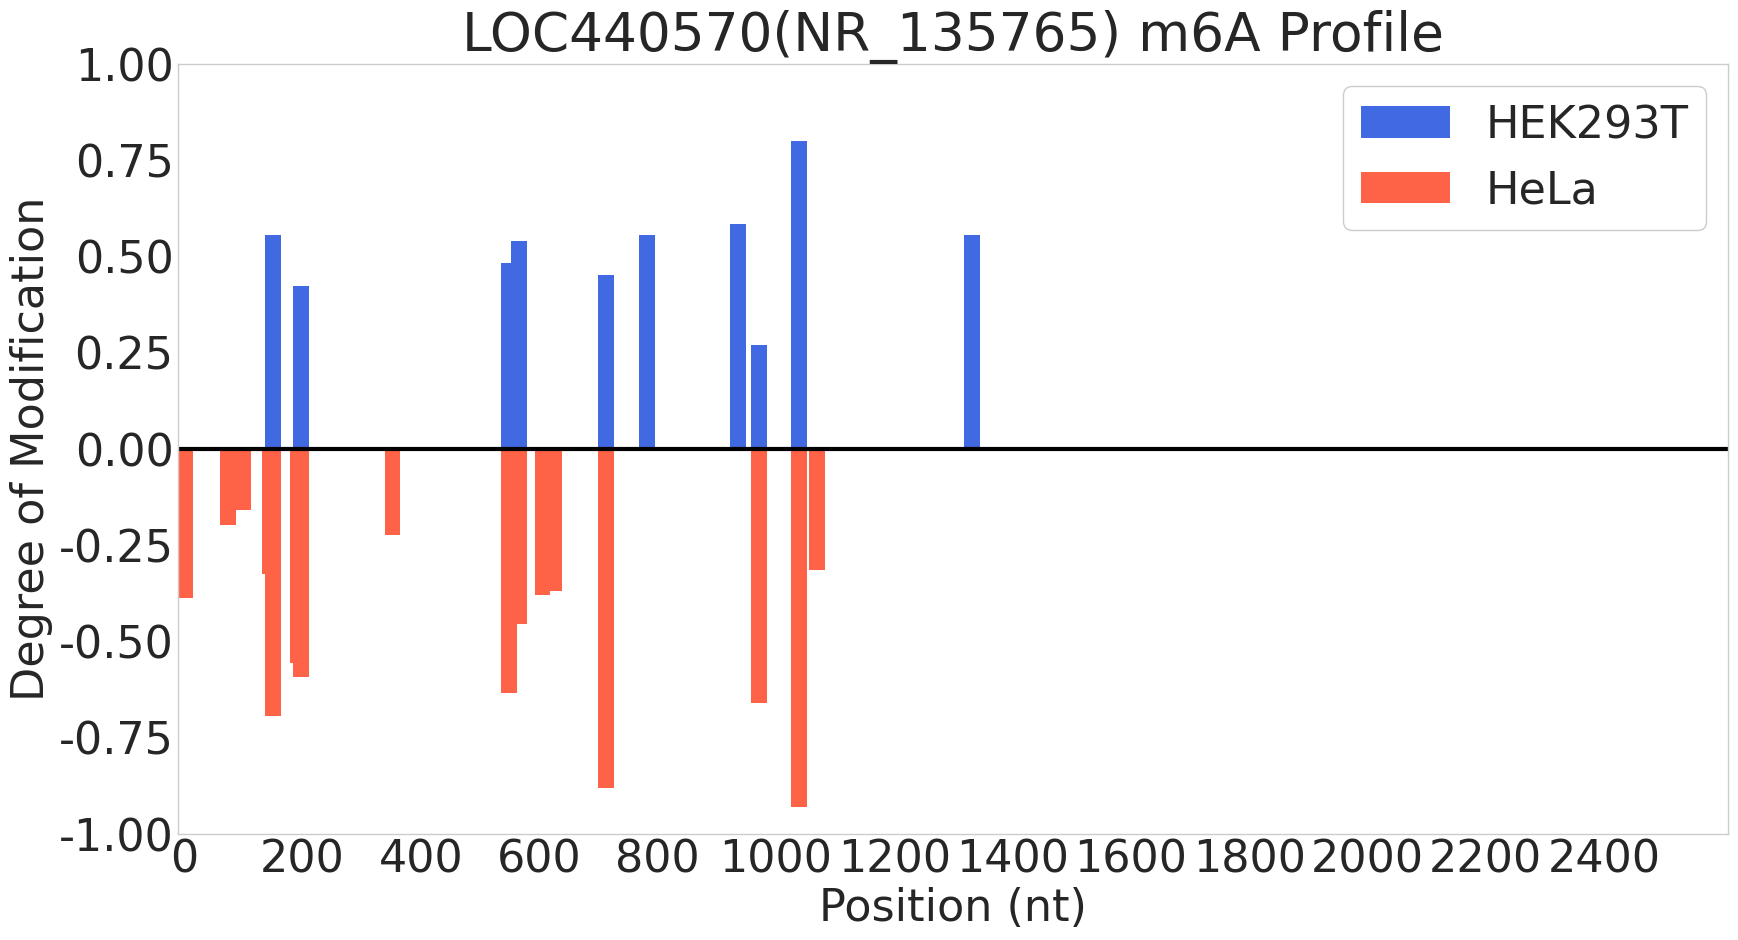

NM_015099


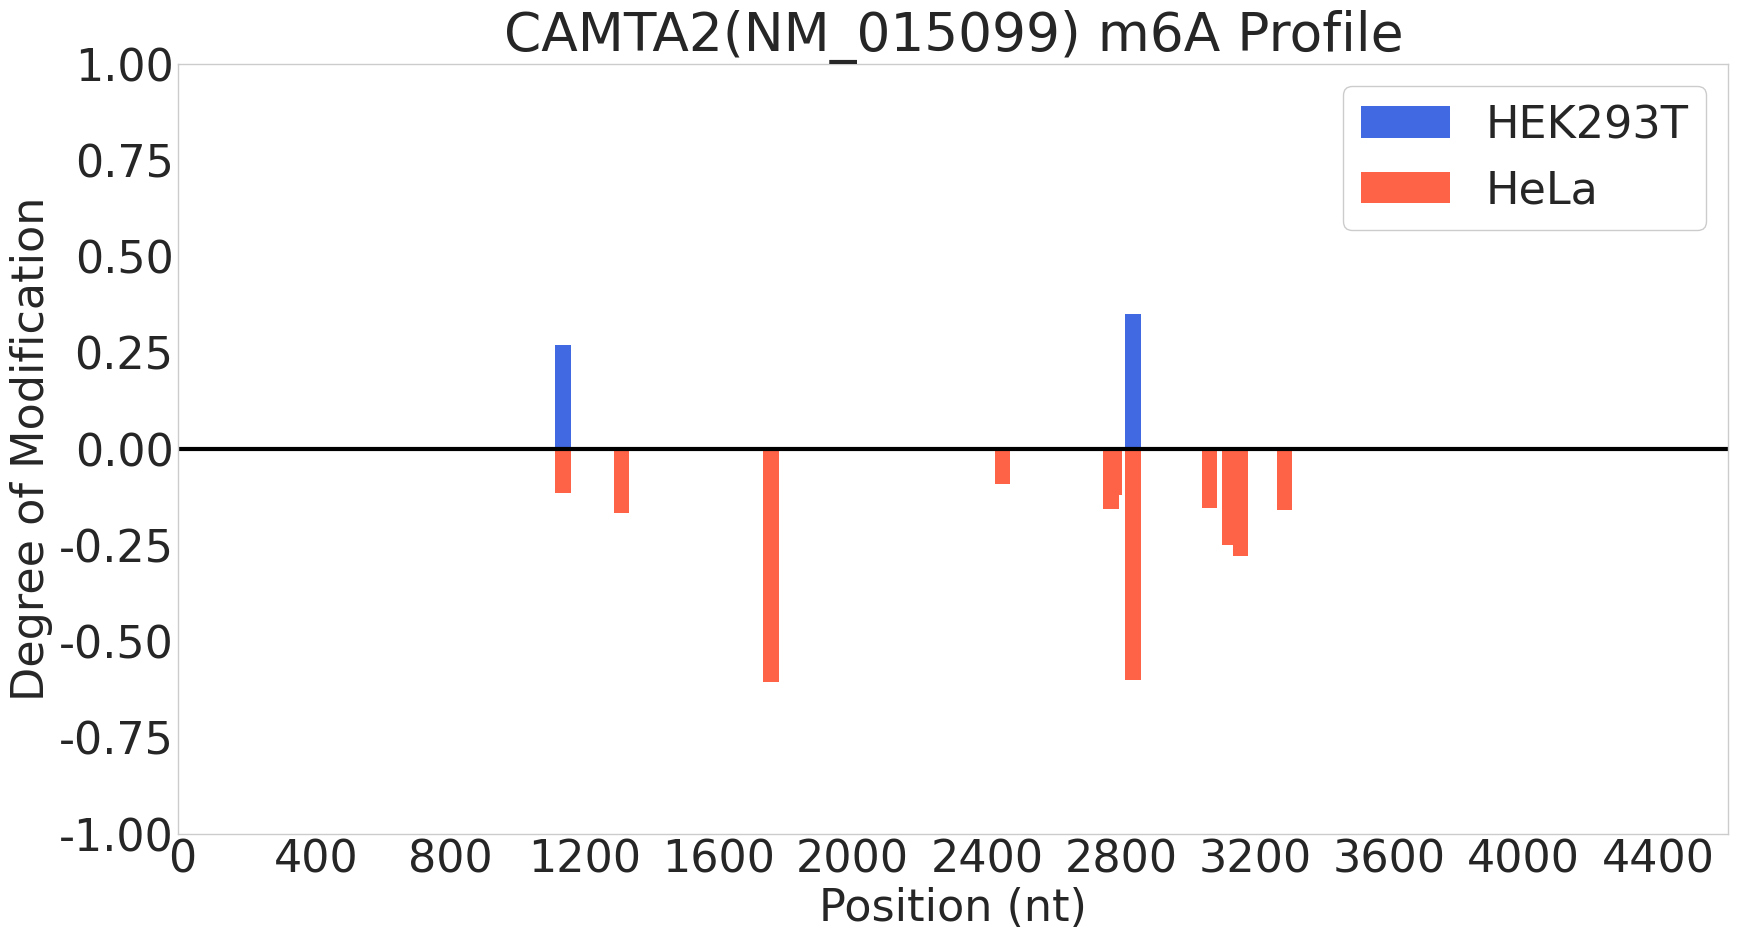

NM_183380


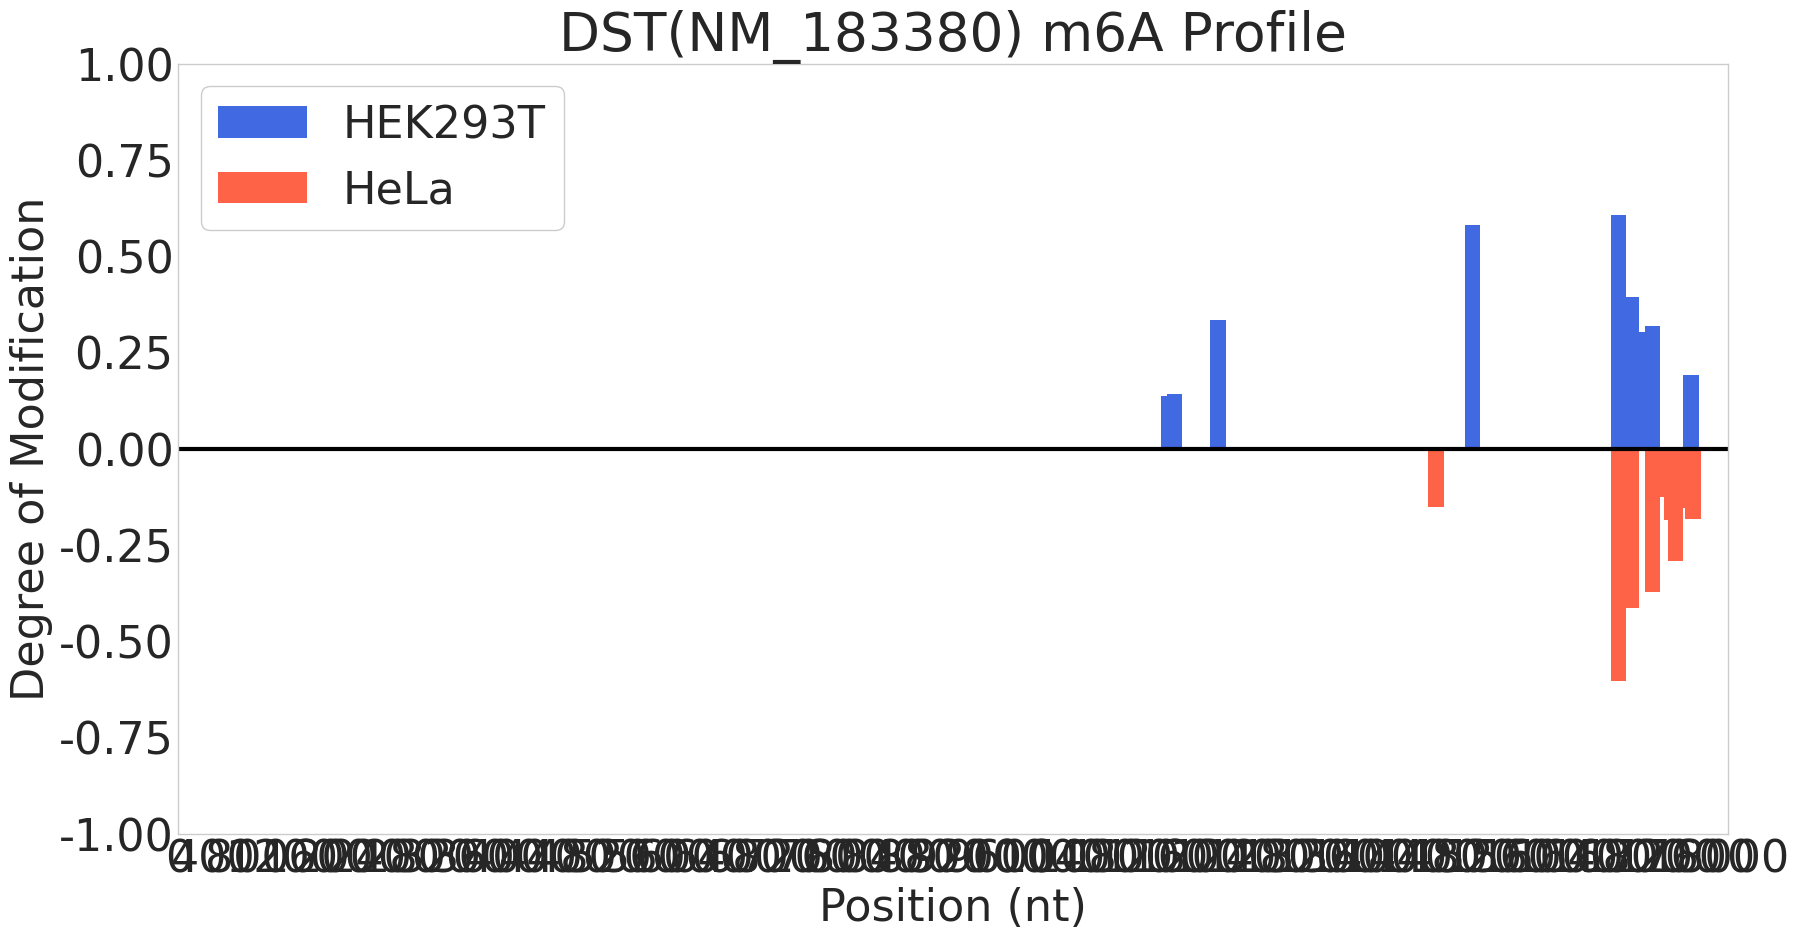

NM_183006


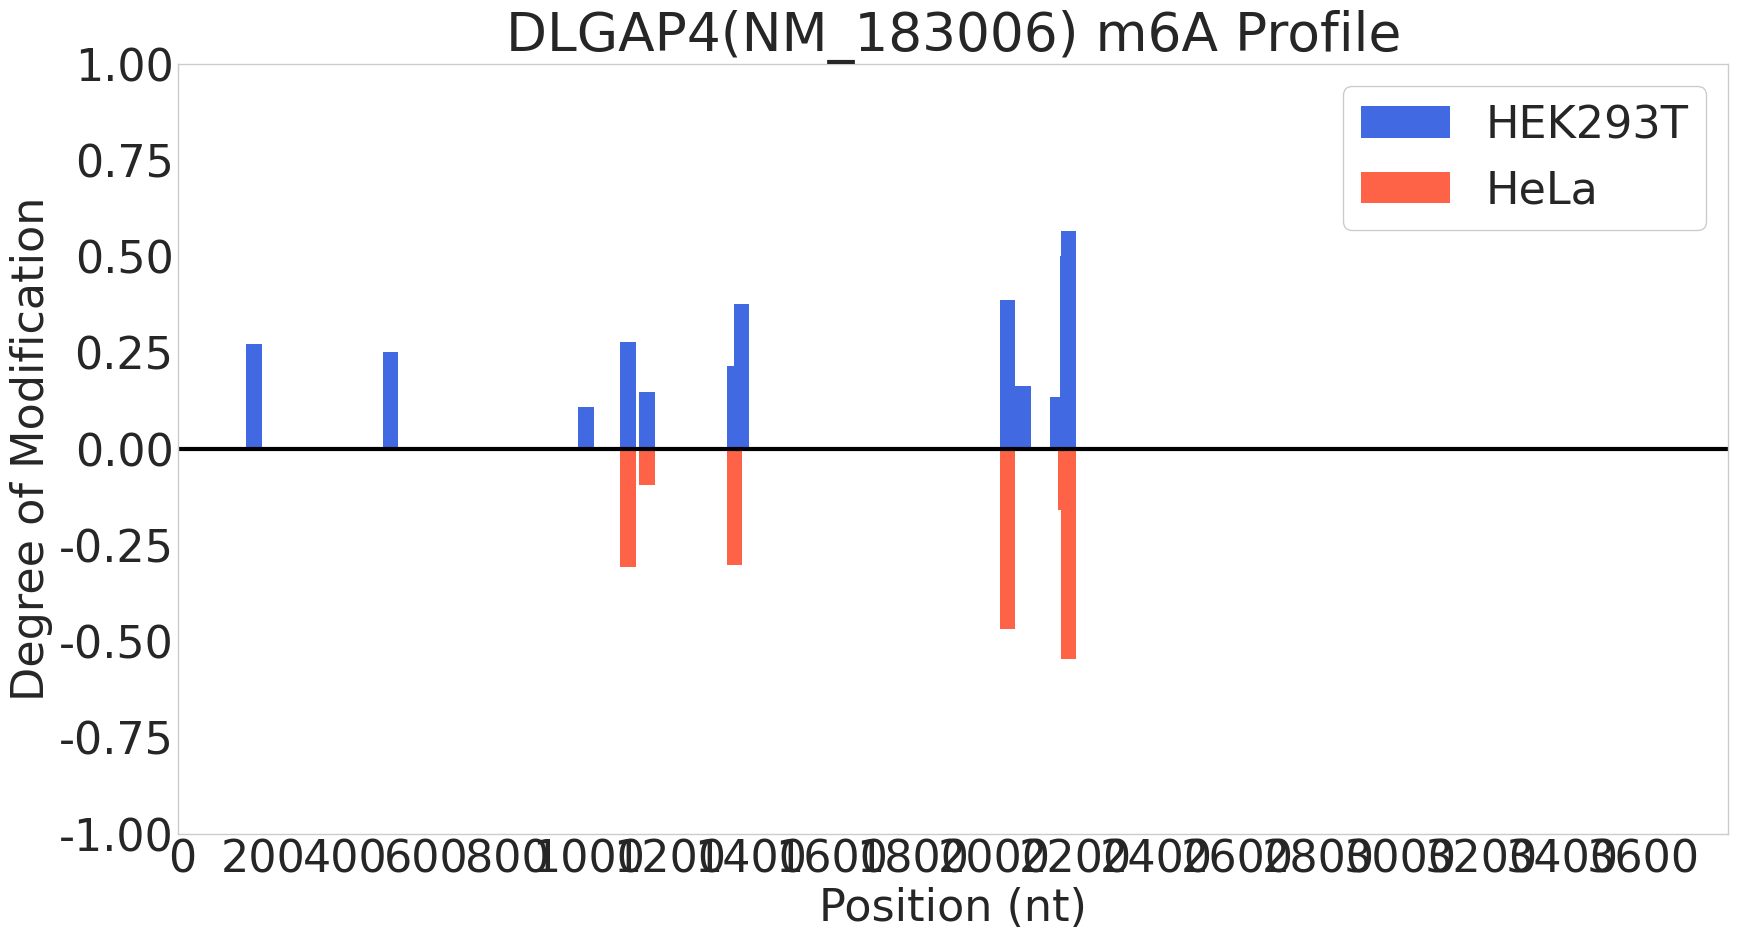

NM_006154


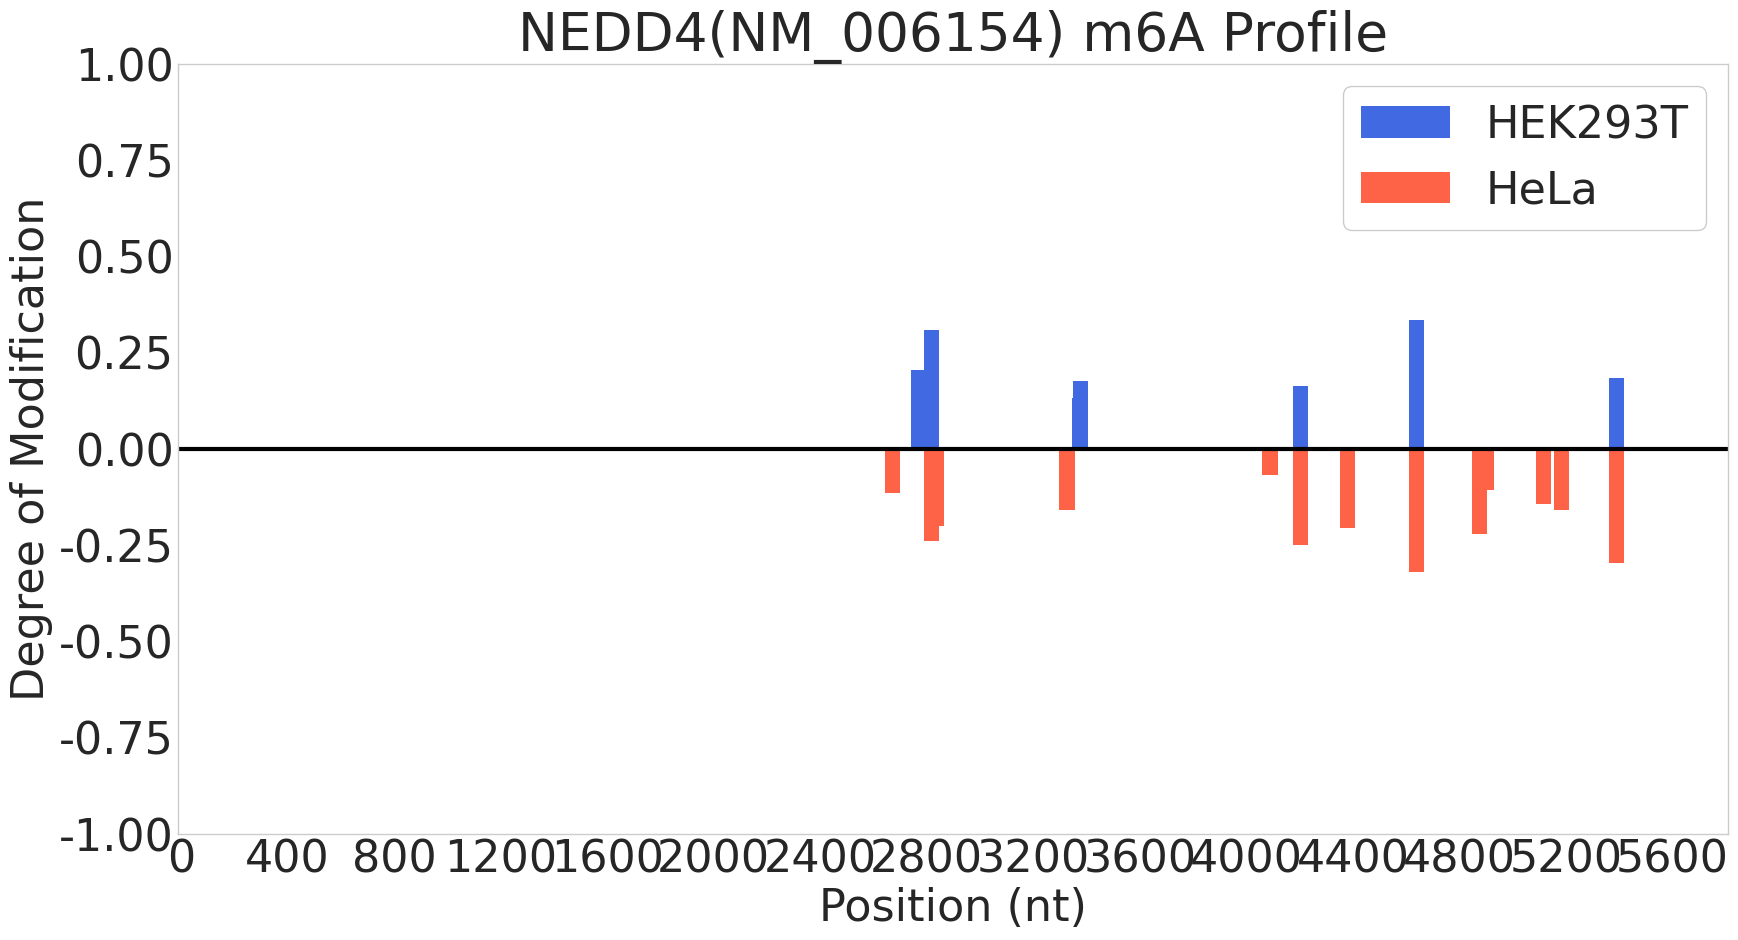

In [103]:
selected_refseq = strong_mod[(strong_mod["unique"]>3) & (strong_mod["cosine_sim"] < 0.7) & (strong_mod["cosine_sim"] > 0)]["refseq"]
for refseq in selected_refseq:
    plot(refseq)

In [70]:
diff_df["union"] = (diff_df["hela_size"] + diff_df["hek_size"] - diff_df["unique"])//2+diff_df["unique"]
print(diff_df)


          refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
0      NM_000016    1.000000       0.573238          1         1  1.000000   
1      NM_000017    0.949245       2.767122          5         5  0.428571   
2      NM_000021    0.983533       2.964824         22        17  0.695652   
3      NM_000027    1.000000       0.586155          1         1  1.000000   
4      NM_000028    1.000000       0.606982          1         1  1.000000   
...          ...         ...            ...        ...       ...       ...   
16796  NR_183625    0.992224       2.003993          5         4  0.800000   
16797  NR_183758    0.985988       0.573215          2         2  1.000000   
16798  NR_183824    0.976160       0.395841          7        11  0.636364   
16799  NR_184202    0.829297       0.598689          3         5  0.600000   
16800  NR_184306    0.990638       0.425246          2         3  0.666667   

       unique        l1        l2  nondrach_common  nondrach_un

In [98]:
selected_df = diff_df[(diff_df["union"] < 5) &(diff_df["union"] > 2) & (diff_df["cosine_sim"] > 0.999) & (diff_df["unique"] == 0)].sample(10)

In [99]:
print(selected_df)

             refseq  cosine_sim  cross_entropy  hela_size  hek_size  iou  \
846    NM_001035005    0.999562       0.492599          3         3  1.0   
8801      NM_004264    0.999881       0.384435          3         3  1.0   
12293     NM_020242    0.999473       0.523916          3         3  1.0   
362    NM_001004106    0.999284       0.634588          3         3  1.0   
406    NM_001006109    0.999572       0.492515          3         3  1.0   
15886     NR_037600    0.999701       0.370828          4         4  1.0   
12794     NM_022875    0.999846       0.570484          3         3  1.0   
12145     NM_018947    0.999587       0.514390          3         3  1.0   
9324      NM_005500    0.999457       0.567954          3         3  1.0   
10618     NM_014462    0.999668       0.467860          3         3  1.0   

       unique        l1        l2  nondrach_common  nondrach_unique  union  
846         0  0.043552  0.050274                0                0      3  
8801     

NM_001035005


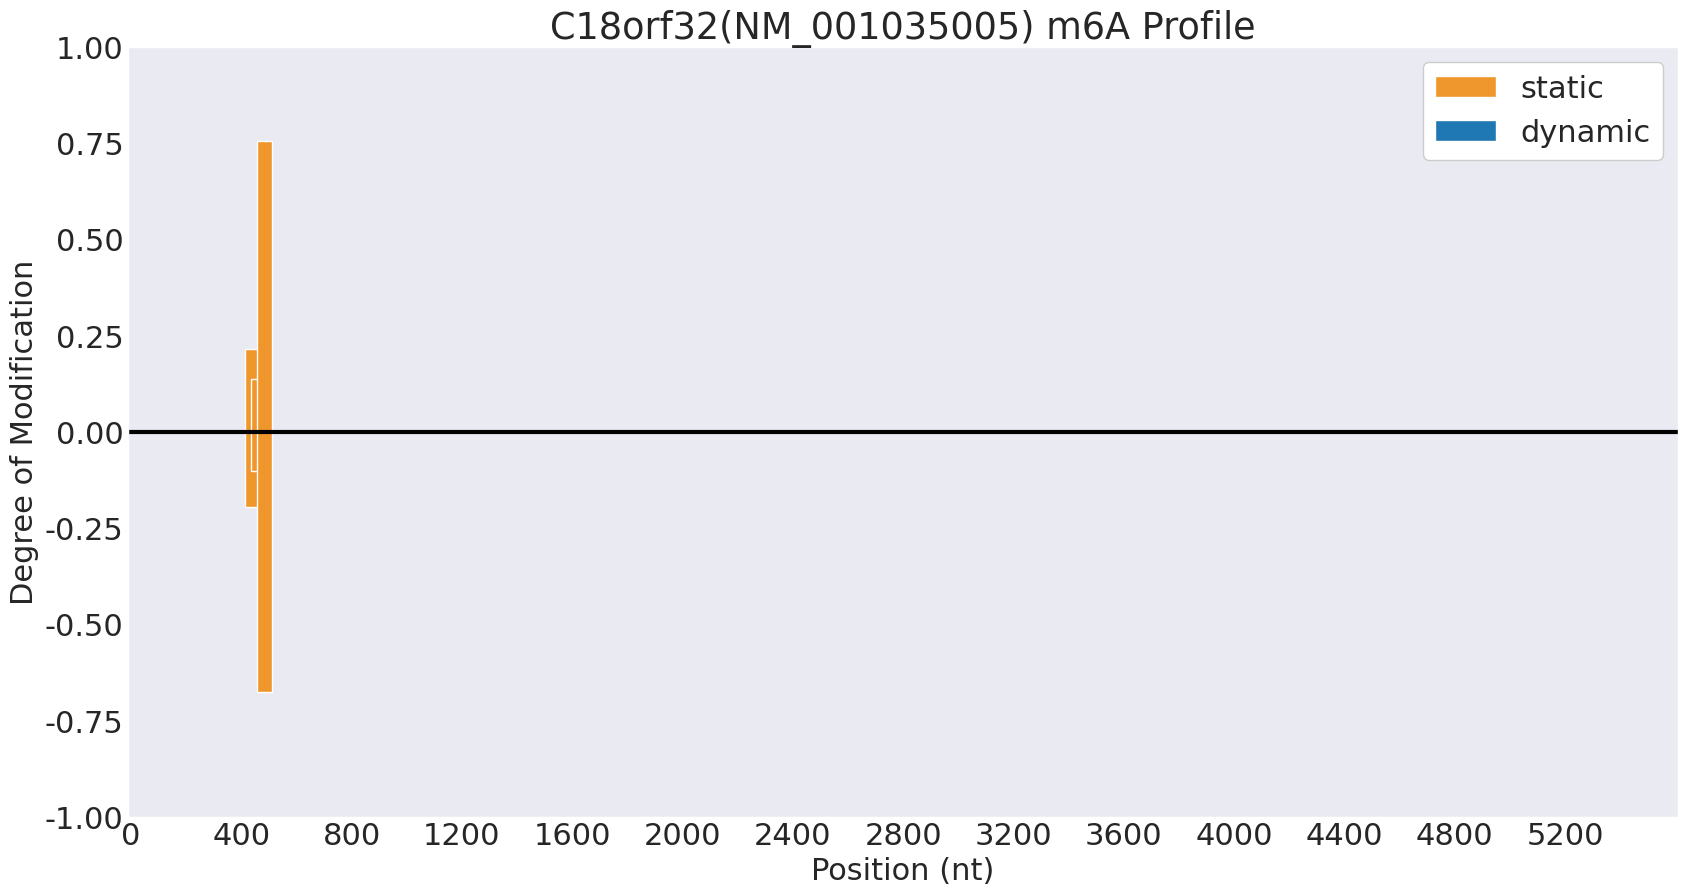

NM_004264


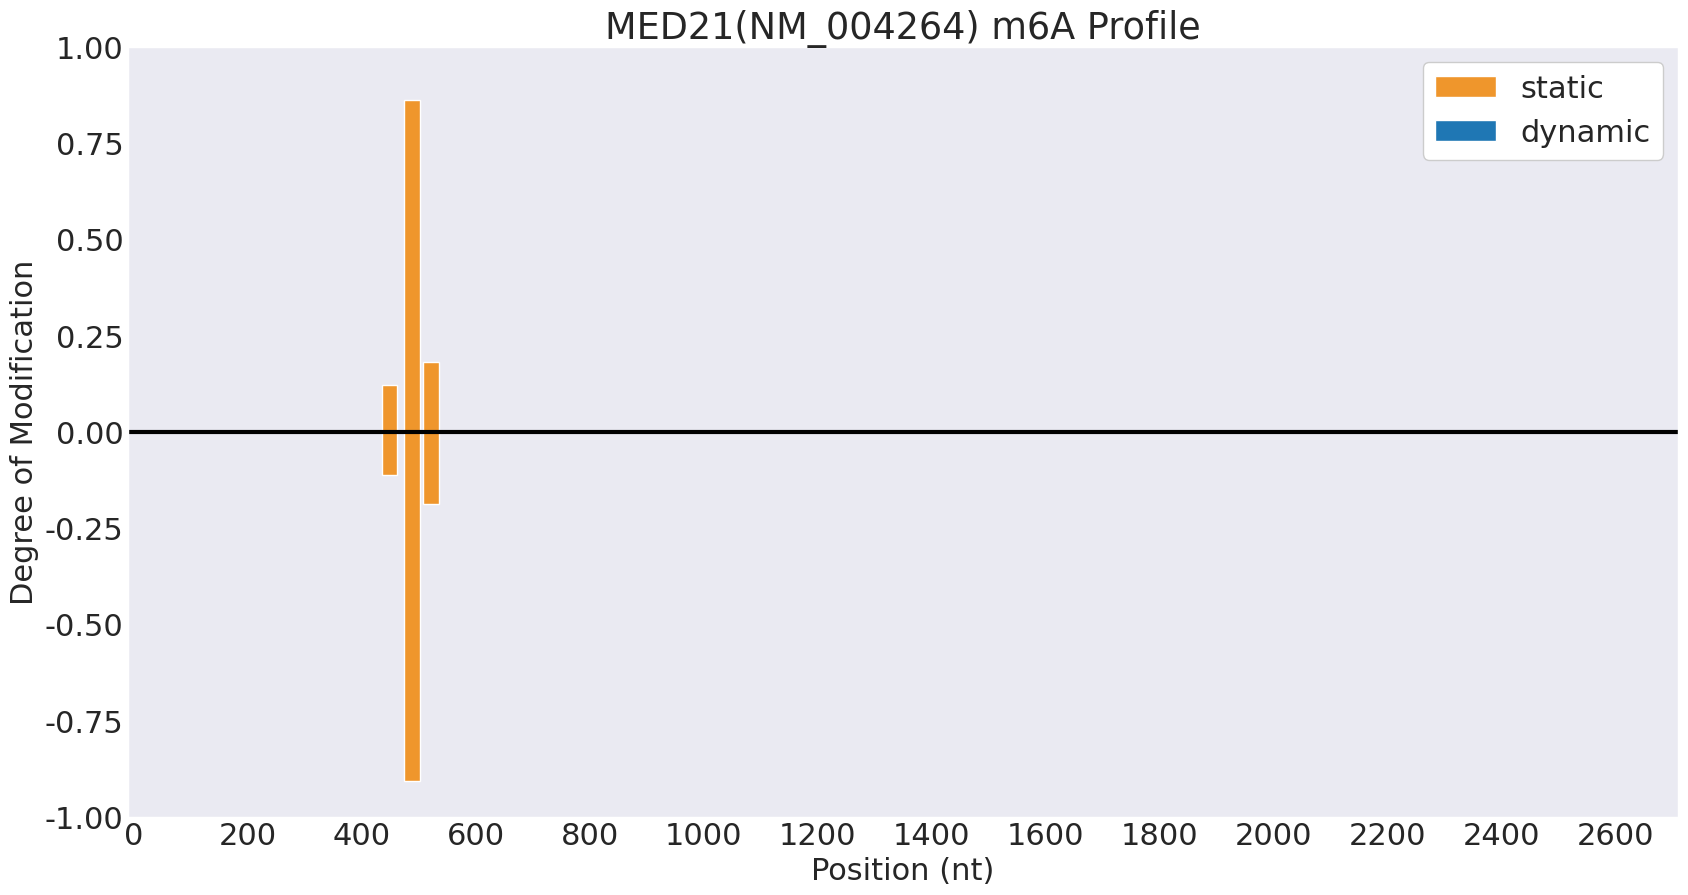

NM_020242


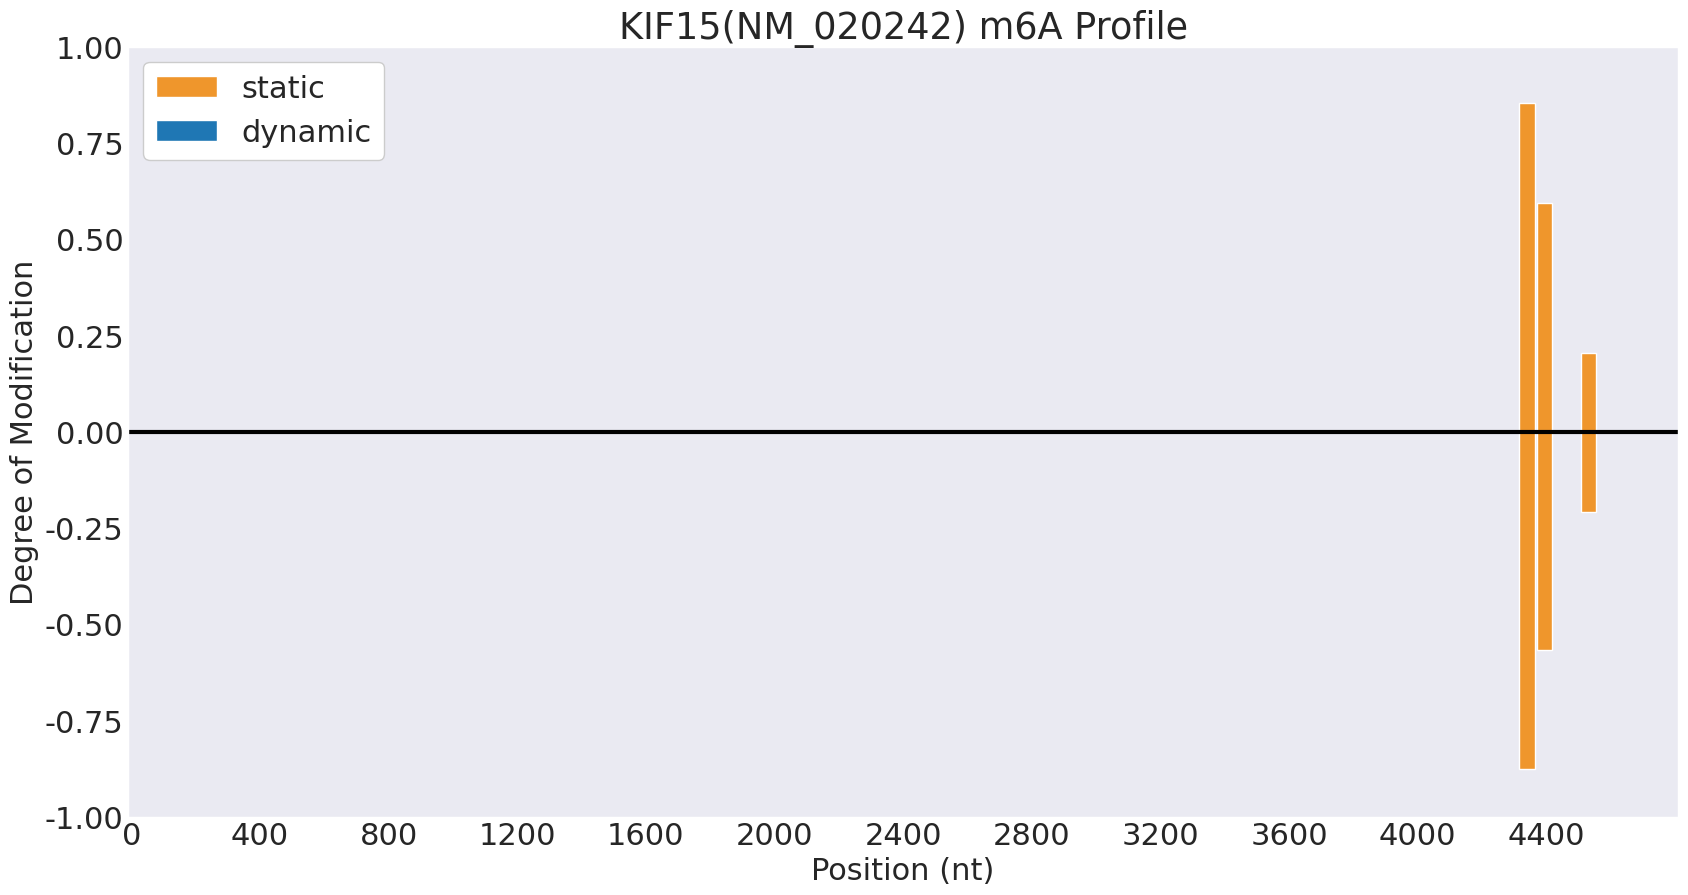

NM_001004106


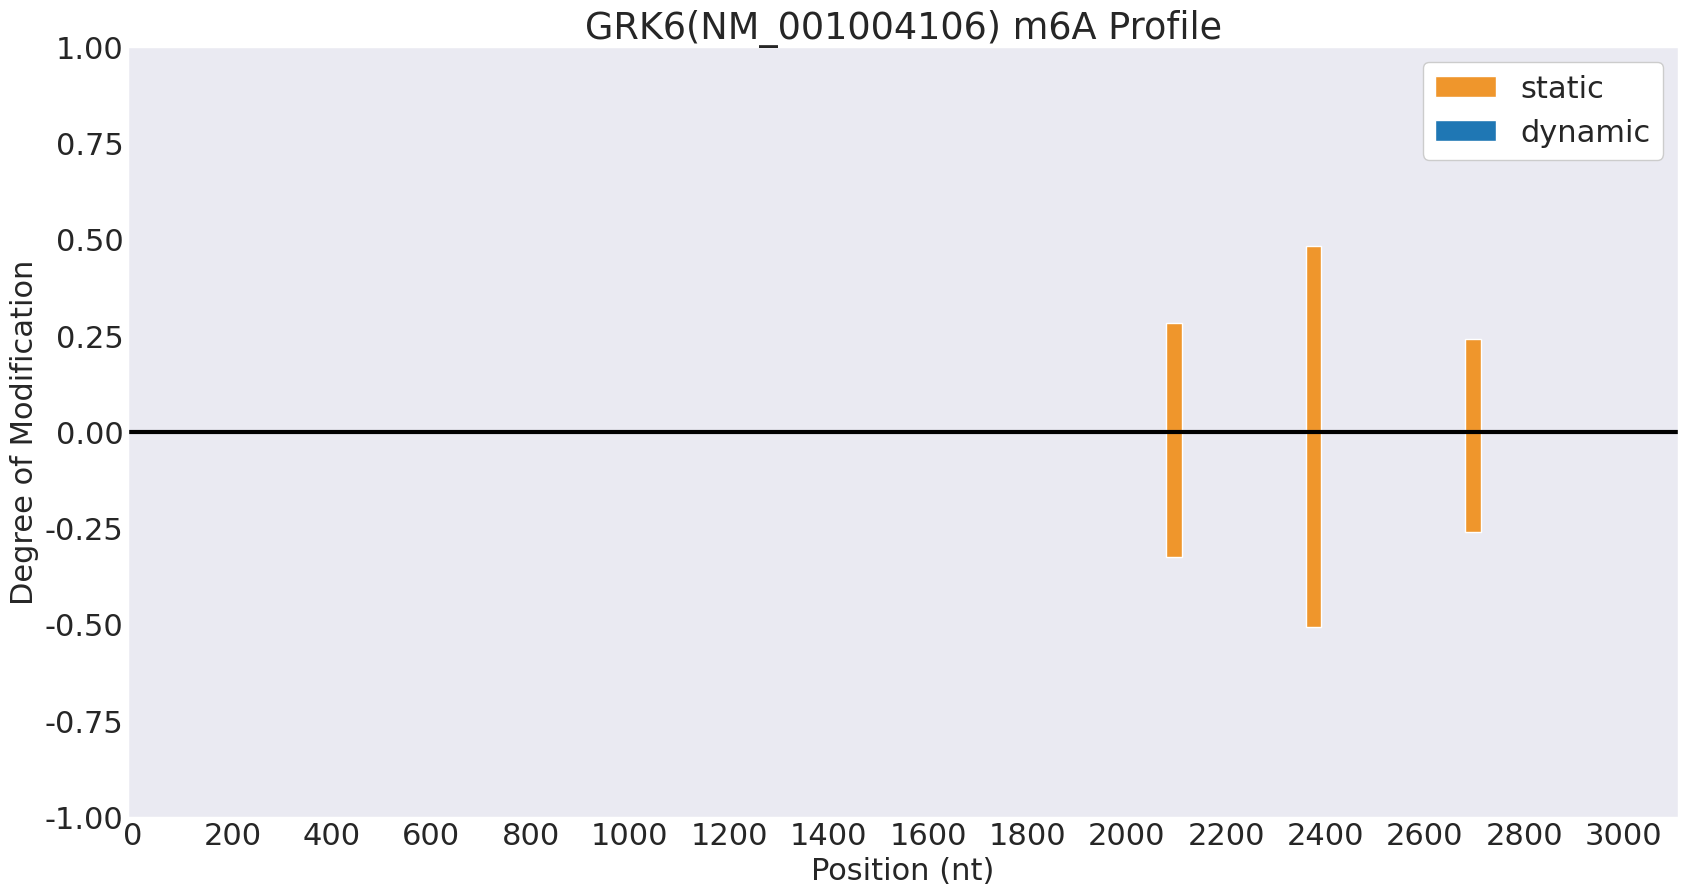

NM_001006109


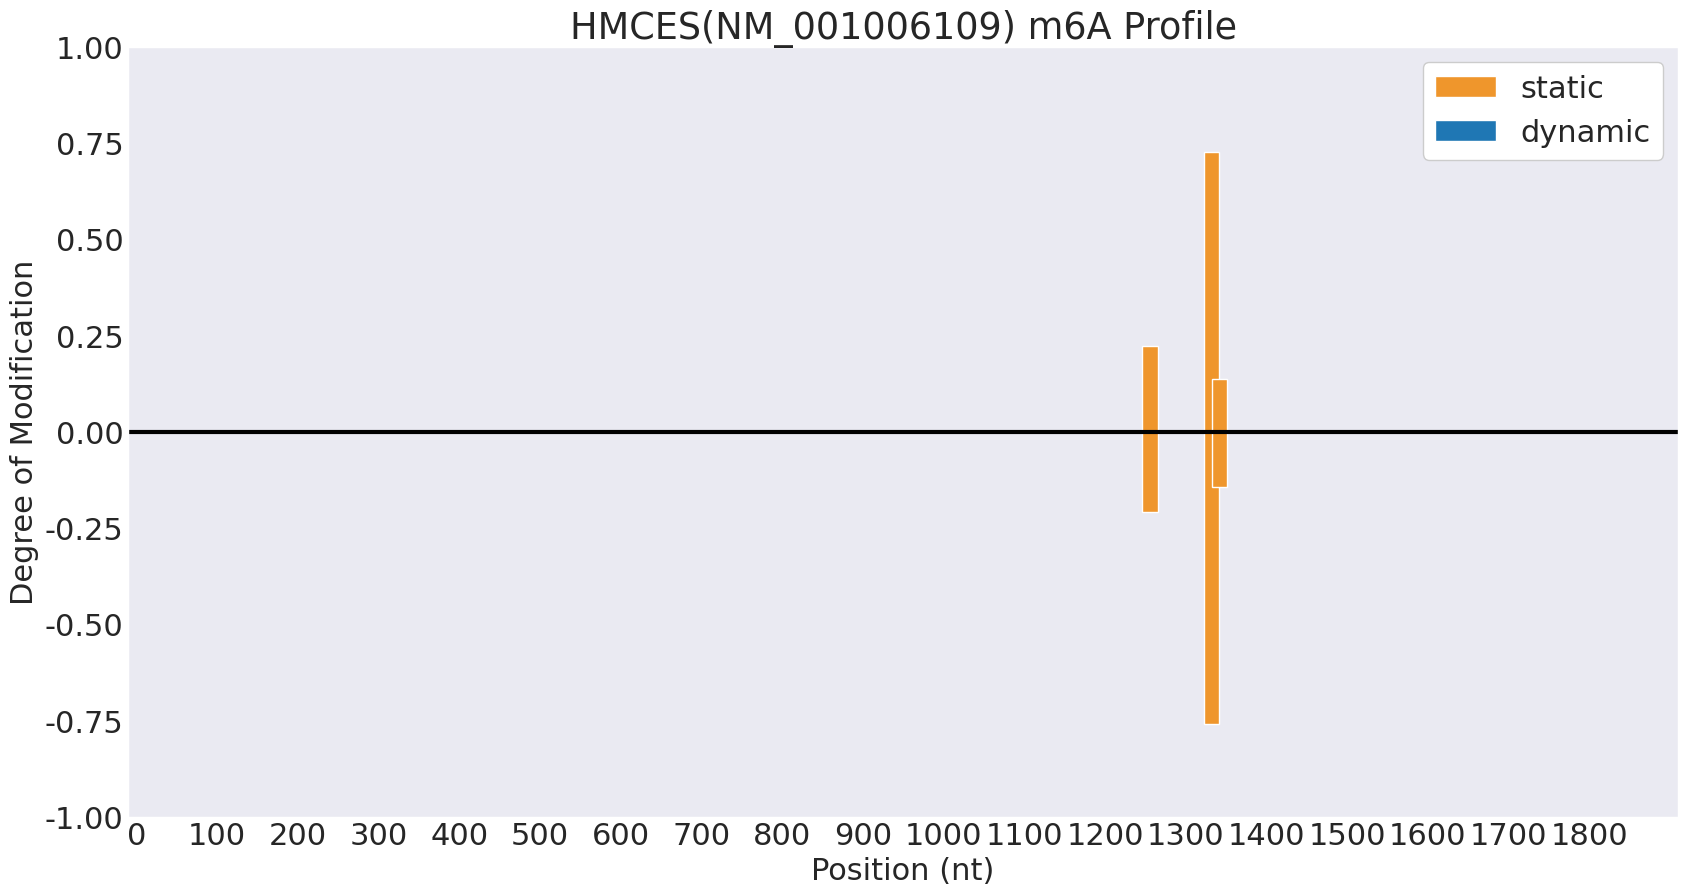

NR_037600


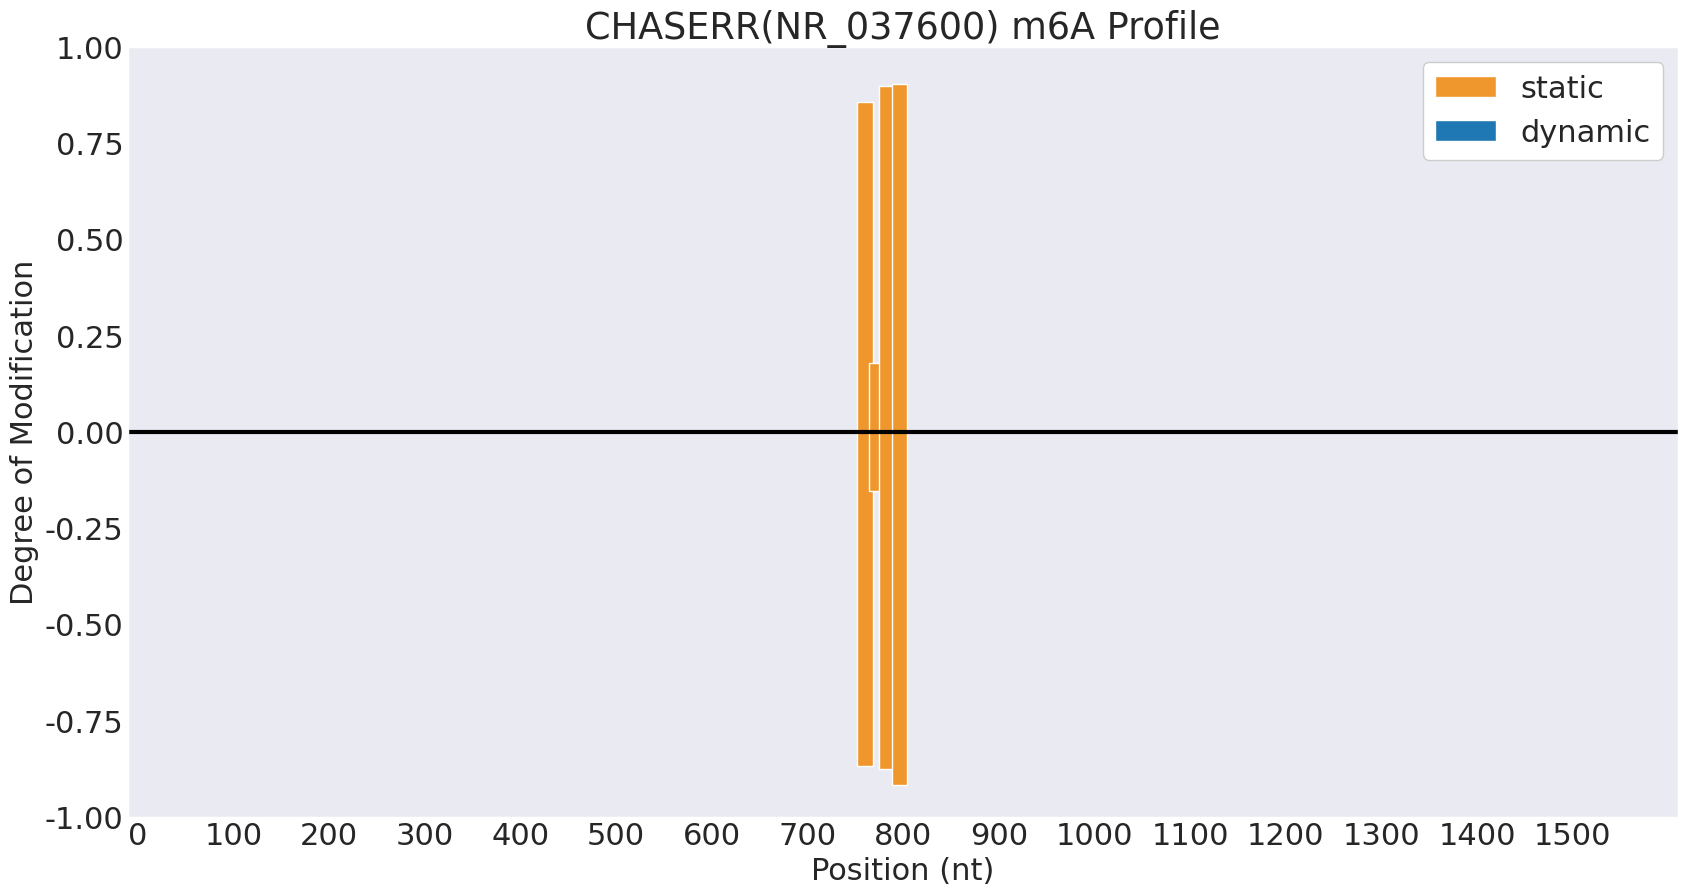

NM_022875


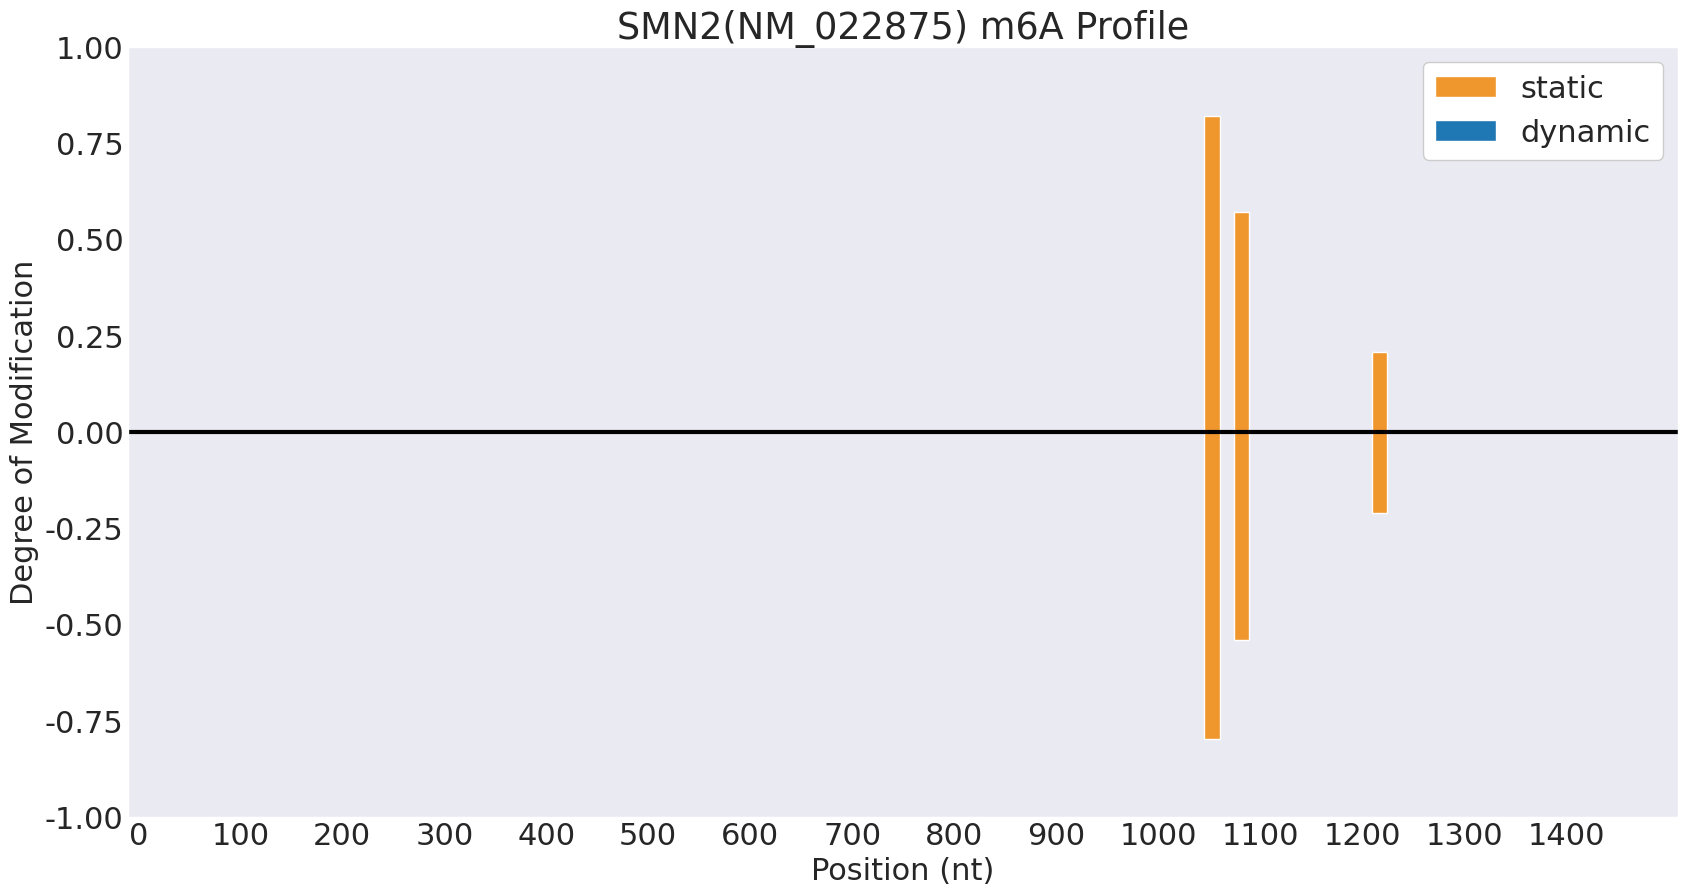

NM_018947


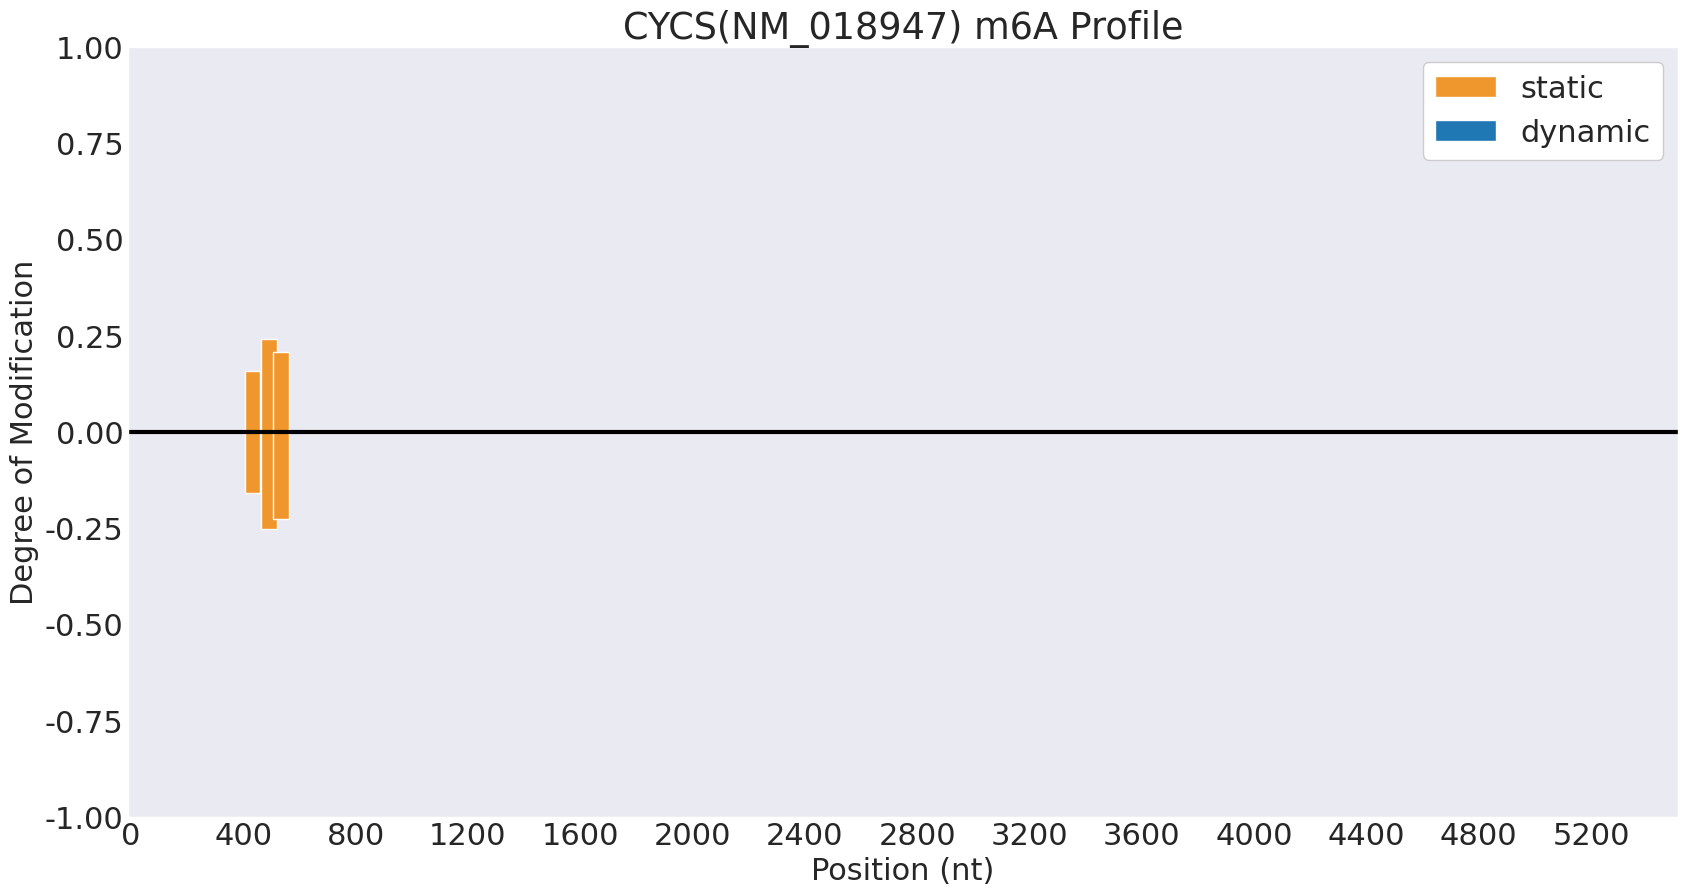

NM_005500


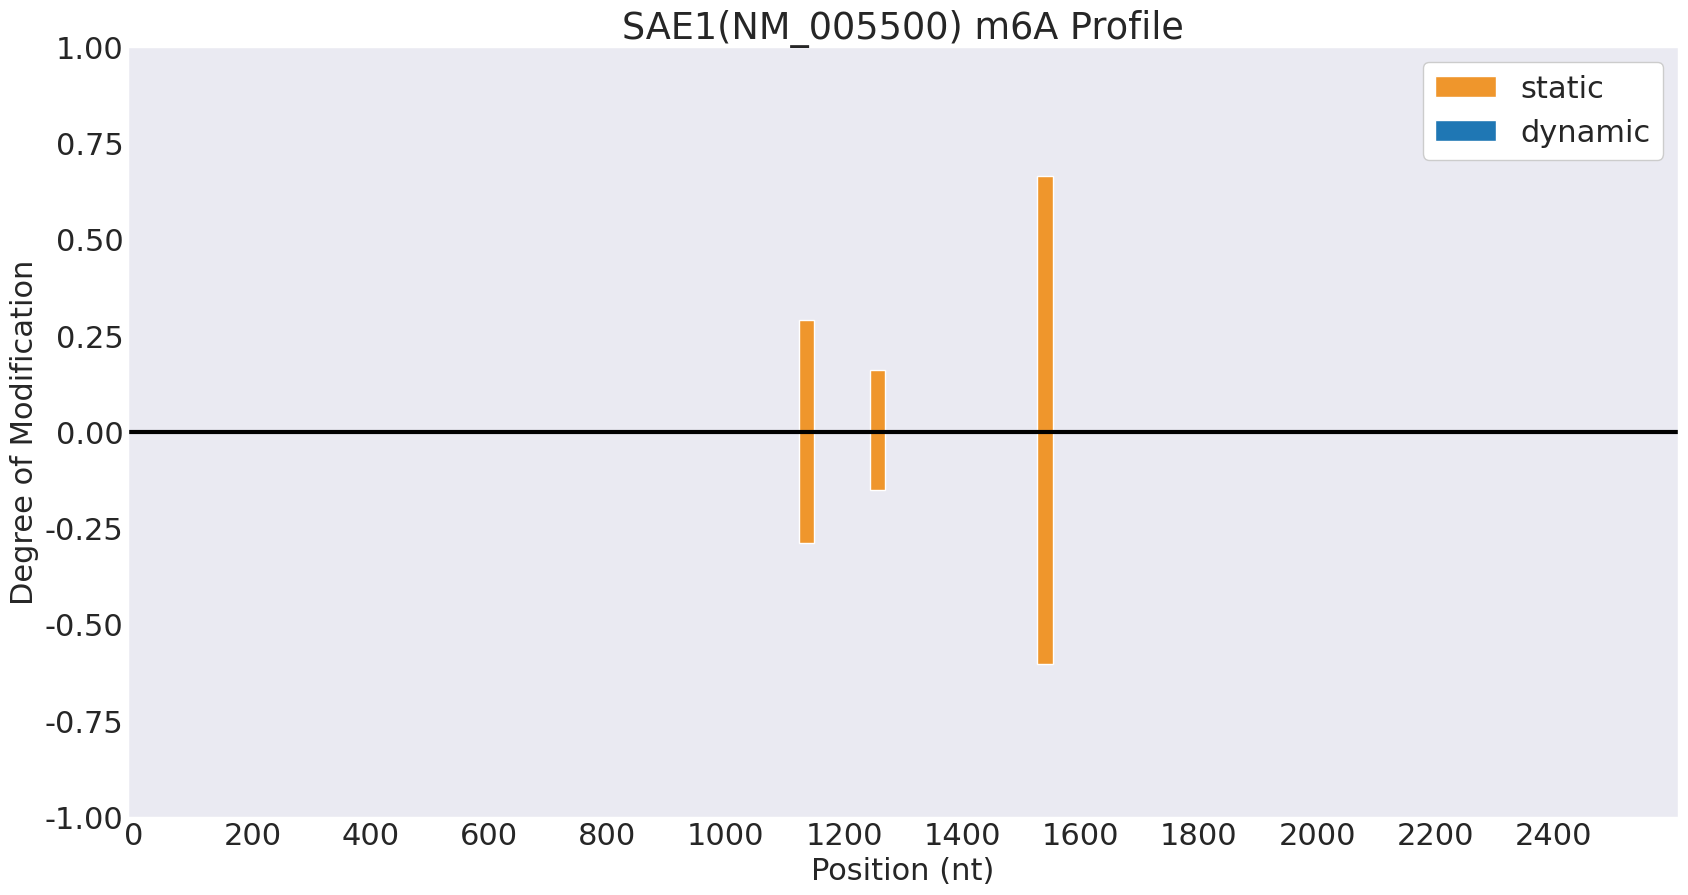

NM_014462


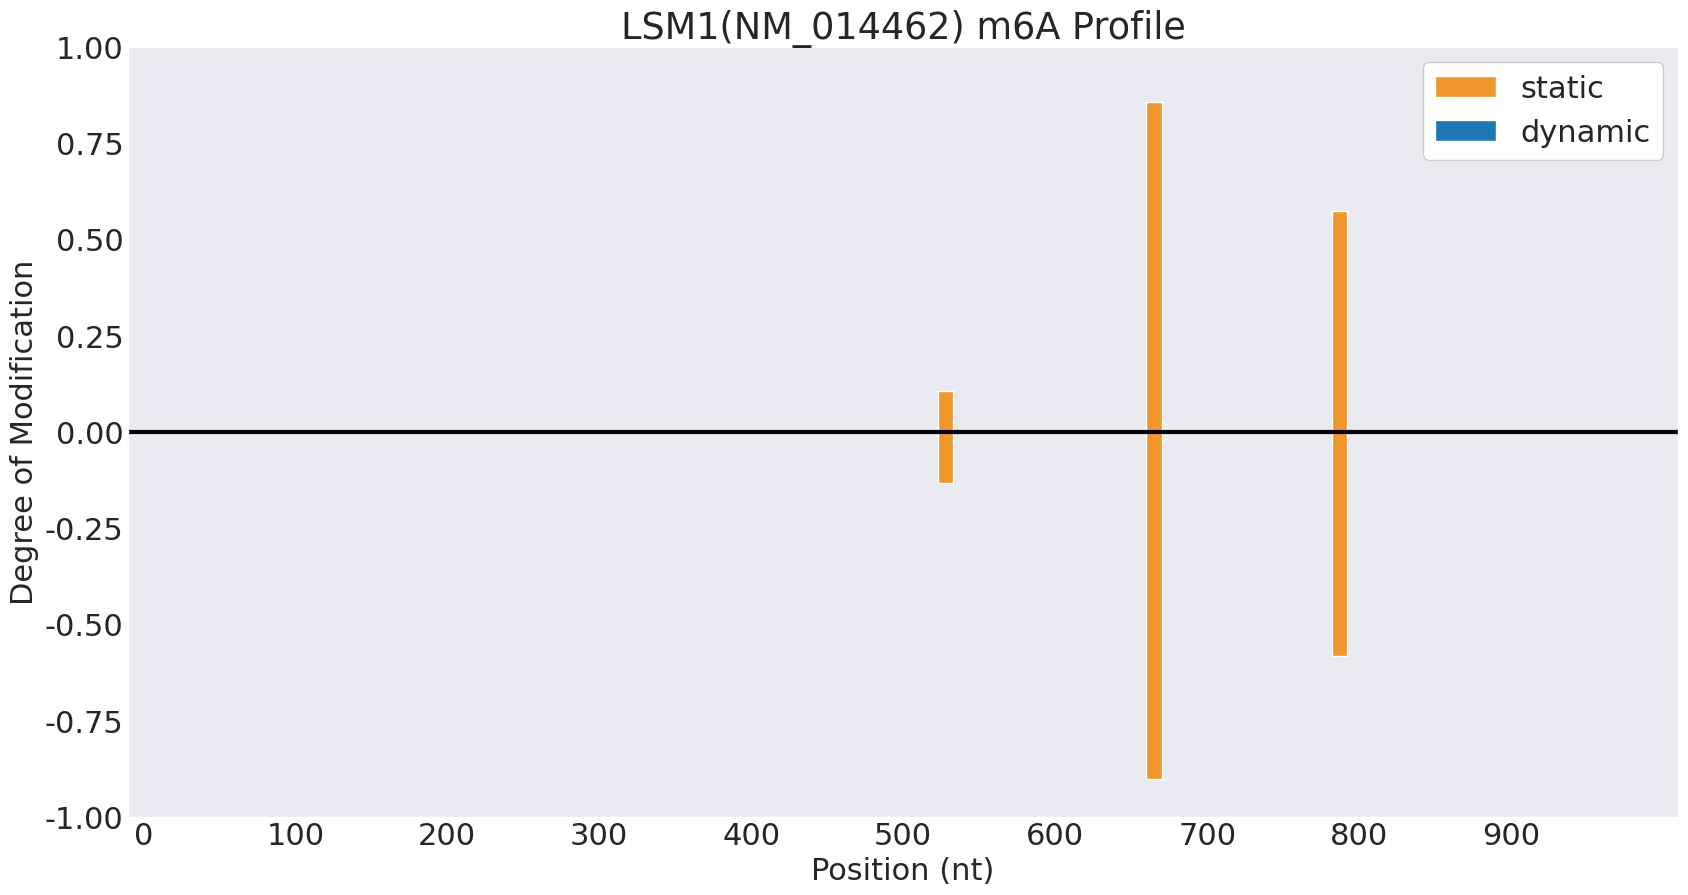

In [100]:
for refseq in selected_df["refseq"]:
    plot(refseq, colour="dynamic")